## Imports

In [3]:
from keras.regularizers import l1_l2
from keras.layers import BatchNormalization
from keras.layers import Bidirectional
from sklearn.utils import shuffle
from keras.layers import Dropout
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau
from keras.constraints import max_norm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense

from keras.optimizers import Adam
import tensorflow as tf
from joblib import dump, load
from tensorflow.keras import losses
from astropy.coordinates import SkyCoord
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
import os
import datetime
import ast

## Input Data

In [4]:
# ============================================================
# 1. Load the data
# ============================================================
lightCurve = pd.read_csv("/Users/np699/Library/CloudStorage/OneDrive-DrexelUniversity/Untitled Folder/Forecaster/lightcurveDataCom7988.csv")
features = pd.read_csv("/Users/np699/Library/CloudStorage/OneDrive-DrexelUniversity/Untitled Folder/Forecaster/featureDataCom7988_pAstro_with_distmean_std.csv")
print("LightCurve shape:", lightCurve.shape)
print("Features shape before cleaning:", features.shape)
# Drop unnecessary columns from the features dataframe
features = features.drop(["simulation_id", 'far', 'snr', 'longitude','latitude', 'distance', 'chirp_mass'], axis=1)

# ============================================================
# 2. Drop bad simulation IDs
# ============================================================
ids_to_drop = [1624, 43162, 97688]
lightCurve = lightCurve[~lightCurve['simulation_id'].isin(ids_to_drop)]

# ============================================================
# 3. Separate chirp_mass_bin_edges and keep it as list/array
# ============================================================
if 'chirp_mass_bin_edges' in features.columns:
    features['chirp_mass_bin_edges'] = features['chirp_mass_bin_edges'].apply(
        lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x)
    )

# ============================================================
# 4. Drop unnecessary columns for scaling (keep sim_id & chirp_mass_bin_edges)
# ============================================================
drop_cols = ['simulation_id', 'chirp_mass_bin_edges']
columns_to_scale = [c for c in features.columns if c not in drop_cols]

# Split features into scalar part and list part
scalar_features = features[columns_to_scale].copy()
chirp_edges = np.stack(features['chirp_mass_bin_edges'].values)
print(f"Chirp-mass bin edges shape: {chirp_edges.shape} (each row = one array)")
print(scalar_features)
# ============================================================
# 5. Convert all scalar columns to numeric and fill NaN
# ============================================================
scalar_features = scalar_features.apply(pd.to_numeric, errors='coerce')
if scalar_features.isnull().any().any():
    print("⚠️ NaN values found — filling with column means.")
    scalar_features = scalar_features.fillna(scalar_features.mean())

# ============================================================
# 6. Scale only the scalar features
# ============================================================
feature_scaler = RobustScaler()
X_scaled = feature_scaler.fit_transform(scalar_features)


# Combine scaled features + chirp_mass_bin_edges into one structure
# Option 1: keep as tuple (X_scaled, chirp_edges)
# Option 2: concatenate if you plan to treat them jointly later
X_combined = {
    'scalar': X_scaled,
    'chirp_mass_bin_edges': chirp_edges
}

print("✅ Scaled scalar features and preserved chirp_mass_bin_edges array.")
print("X_scaled shape:", X_scaled.shape)
print("chirp_edges shape:", chirp_edges.shape)

# ============================================================
# 7. Prepare light curves (same as before)
# ============================================================
filtered_df = lightCurve[lightCurve['filter'].isin(['ztfg', 'ztfr', 'ztfi'])].copy()
filtered_df = filtered_df[['filter', 'mag']]

num_light_curves = scalar_features.shape[0]
filter_order = ['ztfg', 'ztfr', 'ztfi']
filtered_df['filter'] = pd.Categorical(filtered_df['filter'], categories=filter_order, ordered=True)
filtered_df = filtered_df.sort_index()

total_points = len(filtered_df)
num_time_points = total_points // (num_light_curves * len(filter_order))
print("Number of light curves:", num_light_curves)
print("Number of time points:", num_time_points)

y = np.empty((num_light_curves, num_time_points * len(filter_order)), dtype=filtered_df['mag'].dtype)
ztfg_mags = filtered_df[filtered_df['filter'] == 'ztfg']['mag'].values.reshape(num_light_curves, num_time_points)
ztfr_mags = filtered_df[filtered_df['filter'] == 'ztfr']['mag'].values.reshape(num_light_curves, num_time_points)
ztfi_mags = filtered_df[filtered_df['filter'] == 'ztfi']['mag'].values.reshape(num_light_curves, num_time_points)

for i in range(num_time_points):
    y[:, i * 3 + 0] = ztfg_mags[:, i]
    y[:, i * 3 + 1] = ztfr_mags[:, i]
    y[:, i * 3 + 2] = ztfi_mags[:, i]

# ============================================================
# 8. Trim to 30 time points if needed
# ============================================================
num_time_points = 30
y = y[:, :num_time_points * len(filter_order)]

# ============================================================
# 9. Scale targets
# ============================================================
target_scaler = RobustScaler()
y_scaled = target_scaler.fit_transform(y)


# ============================================================
# 10. Split and reshape for LSTM
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)
chirp_train, chirp_test = train_test_split(chirp_edges, test_size=0.3, random_state=42)

y_train_reshaped = y_train.reshape((y_train.shape[0], num_time_points, len(filter_order)))
y_test_reshaped = y_test.reshape((y_test.shape[0], num_time_points, len(filter_order)))
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Concatenate before training
X_train_full = np.concatenate([X_train, chirp_train], axis=1)
X_test_full = np.concatenate([X_test, chirp_test], axis=1)

print("Combined feature shape:", X_train_full.shape)
X_train_reshaped = X_train_full.reshape((X_train_full.shape[0], 1, X_train_full.shape[1]))
X_test_reshaped = X_test_full.reshape((X_test_full.shape[0], 1, X_test_full.shape[1]))


LightCurve shape: (5163120, 10)
Features shape before cleaning: (8077, 15)
Chirp-mass bin edges shape: (8077, 19) (each row = one array)
          area(90)     HasNS  HasRemnant  HasMassGap    PAstro     distmean  \
0      2095.047264  1.000000    1.000000    0.000000  0.873644   552.816204   
1      1455.127847  1.000000    1.000000    0.000000  0.987647   260.907059   
2     20844.582063  1.000000    1.000000    0.000000  0.460184   641.923446   
3      1460.454101  1.000000    1.000000    0.000000  0.999185   283.270133   
4        81.061889  1.000000    1.000000    0.000000  1.000000    83.701094   
...            ...       ...         ...         ...       ...          ...   
8072  23677.562680  1.000000    0.102971    0.219654  0.671369  1088.218526   
8073     14.437906  1.000000    0.007704    0.993208  1.000000   251.294607   
8074   1718.570743  1.000000    0.020679    0.418137  0.999989   406.871040   
8075  32211.606529  0.797903    0.000000    0.377103  0.805906  1560.9270

## Model

In [5]:
# Test
X_train_full = np.concatenate([X_train, chirp_train], axis=1)
X_test_full = np.concatenate([X_test, chirp_test], axis=1)

print("Combined feature shape:", X_train_full.shape)
X_train_reshaped = X_train_full.reshape((X_train_full.shape[0], 1, X_train_full.shape[1]))
X_test_reshaped = X_test_full.reshape((X_test_full.shape[0], 1, X_test_full.shape[1]))
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True,
                             kernel_regularizer=l1_l2(1e-5, 1e-4),
                             kernel_constraint=max_norm(2.0)),
                        input_shape=(1, X_train_full.shape[1])))
model.add(Dropout(0.1))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.1))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(90))

Combined feature shape: (5653, 26)


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# Compile the model with a lower learning rate and gradient clipping
optimizer = Adam(learning_rate=0.0003, clipnorm=2.0)  # Only clipnorm is used
model.compile(optimizer=optimizer, loss='mse')

# Implement early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6)

# Create a TensorBoard callback
logdir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=logdir, histogram_freq=1)

# Train the model
history = model.fit(X_train_reshaped, y_train, 
                    epochs=300, batch_size=128, validation_split=0.3, 
                    verbose=1, callbacks=[early_stopping, lr_reduction])


model.summary()

Epoch 1/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1584 - val_loss: 0.1536 - learning_rate: 3.0000e-04
Epoch 2/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1569 - val_loss: 0.1533 - learning_rate: 3.0000e-04
Epoch 3/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1493 - val_loss: 0.1543 - learning_rate: 3.0000e-04
Epoch 4/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1598 - val_loss: 0.1557 - learning_rate: 3.0000e-04
Epoch 5/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1513 - val_loss: 0.1533 - learning_rate: 3.0000e-04
Epoch 6/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1561 - val_loss: 0.1533 - learning_rate: 3.0000e-04
Epoch 7/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1563 - val_loss: 0.1527 - learning_rate: 3.0000e-04
Epoch 8/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1514 - val_loss: 0.1515 - learning_rate: 3.0000e-04
Epoch 9/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1574 - val_loss: 0.1514 - learning

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 128)         │        46,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,592 (1.99 MB)

 Trainable params: 173,530 (677.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 347,062 (1.32 MB)

## Predictions

(218160,)
()
Test MSE with MC Dropout: 0.1258, Test R² with MC Dropout: 0.8138
0.27403765038199007
Test MSE with MC Dropout (inverted): 0.7752
Test R² with MC Dropout (inverted): 0.8852
MAE with MC Dropout (inverted): 0.6825


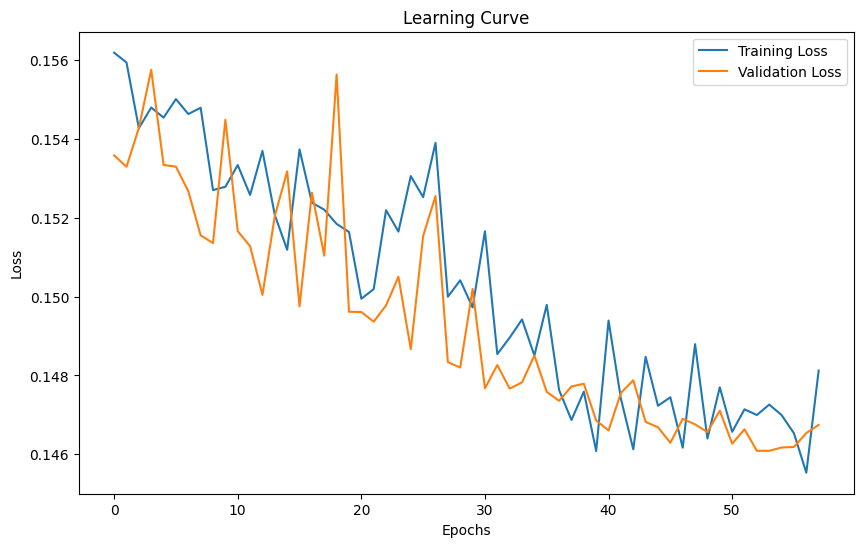

In [8]:
def predict_with_uncertainty(model, X, n_iter=1000):
    """
    Perform MC Dropout predictions with TensorFlow 2.x.
    
    Args:
    - model: The Keras model with dropout layers.
    - X: Input data to make predictions on.
    - n_iter: Number of forward passes to perform.
    
    Returns:
    - mean_preds: Mean predictions.
    - uncertainty: Standard deviation of predictions (uncertainty).
    """
    
    # Perform n_iter forward passes and collect the predictions
    preds = [model(X, training=True) for _ in range(n_iter)]  # Dropout active during inference
    preds = np.array(preds)
    
    # Calculate mean and standard deviation of the predictions
    mean_preds = preds.mean(axis=0)
    uncertainty = preds.std(axis=0)
    
    return mean_preds, uncertainty

# Perform MC Dropout to predict with uncertainty
n_mc_samples = 1000 # Number of forward passes
mean_preds, uncertainty = predict_with_uncertainty(model, X_test_reshaped, n_iter=n_mc_samples)

# Reshape the mean predictions to match the shape used during scaling (num_samples, num_time_points * num_filters)
mean_preds_flat = mean_preds.reshape(mean_preds.shape[0], num_time_points * 3)  
# Invert the standardization for the mean predictions
mean_preds_inverted = target_scaler.inverse_transform(mean_preds_flat).reshape(mean_preds.shape[0], num_time_points, 3)

# Reshape uncertainty to match mean_preds_inverted shape
uncertainty_reshaped = uncertainty.reshape(uncertainty.shape[0], num_time_points, 3)
# Evaluate the model using the mean predictions
print(mean_preds_flat.flatten().shape)
test_mse_mc = mean_squared_error(y_test.flatten(), mean_preds_flat.flatten())
test_r2_mc = r2_score(y_test.flatten(), mean_preds_flat.flatten())
print(test_mse_mc.shape)
print(f'Test MSE with MC Dropout: {test_mse_mc:.4f}, Test R² with MC Dropout: {test_r2_mc:.4f}')
mae = np.mean(np.abs(y_test.flatten() - mean_preds_flat.flatten()))
print(mae)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Reshape y_test to match the scaler's expected input (num_samples, num_time_points * 3)
y_test_flat = y_test.reshape(y_test.shape[0], num_time_points * 3)

# Inverse-transform y_test using the same scaler
y_test_inverted = target_scaler.inverse_transform(y_test_flat).reshape(y_test.shape[0], num_time_points, 3)

# Flatten both for metric computation
y_test_inverted_flat = y_test_inverted.flatten()
mean_preds_inverted_flat = mean_preds_inverted.flatten()

# Compute metrics on the inverse-transformed data
test_mse_mc = mean_squared_error(y_test_inverted_flat, mean_preds_inverted_flat)
test_r2_mc = r2_score(y_test_inverted_flat, mean_preds_inverted_flat)
mae = mean_absolute_error(y_test_inverted_flat, mean_preds_inverted_flat)

# Print results
print(f"Test MSE with MC Dropout (inverted): {test_mse_mc:.4f}")
print(f"Test R² with MC Dropout (inverted): {test_r2_mc:.4f}")
print(f"MAE with MC Dropout (inverted): {mae:.4f}")

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()

Plotting all light curves with MSE around 0.13 ± 0.01:


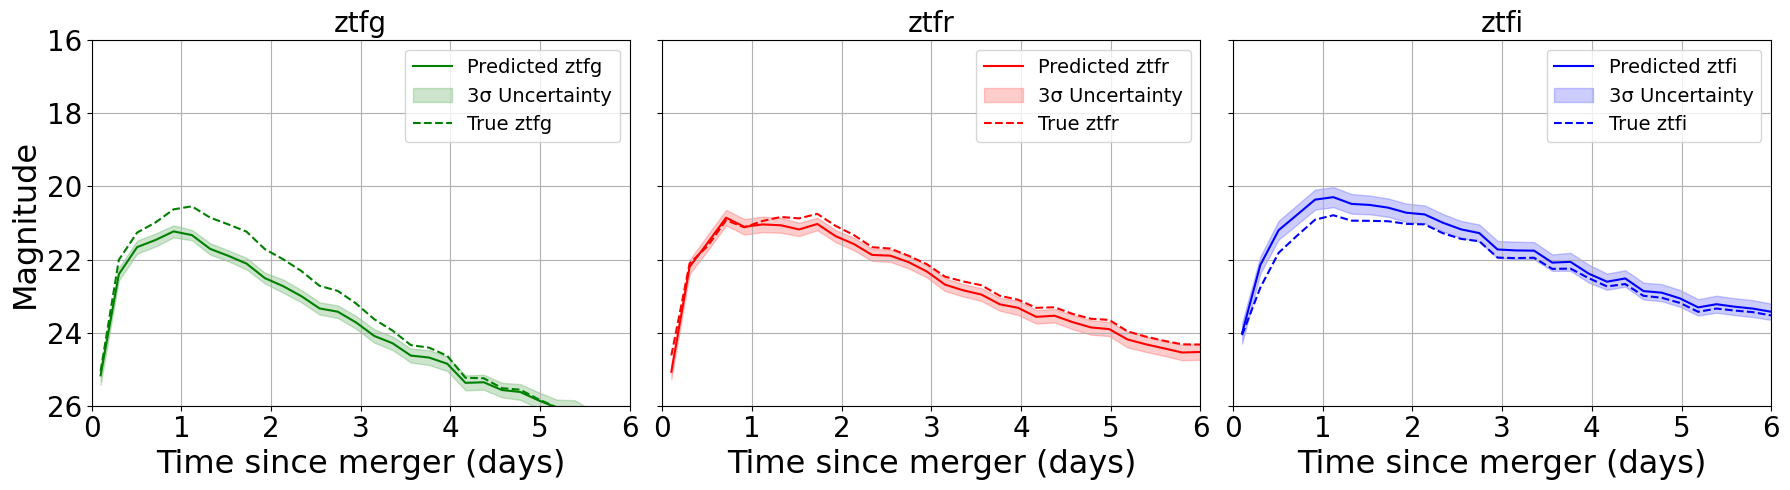

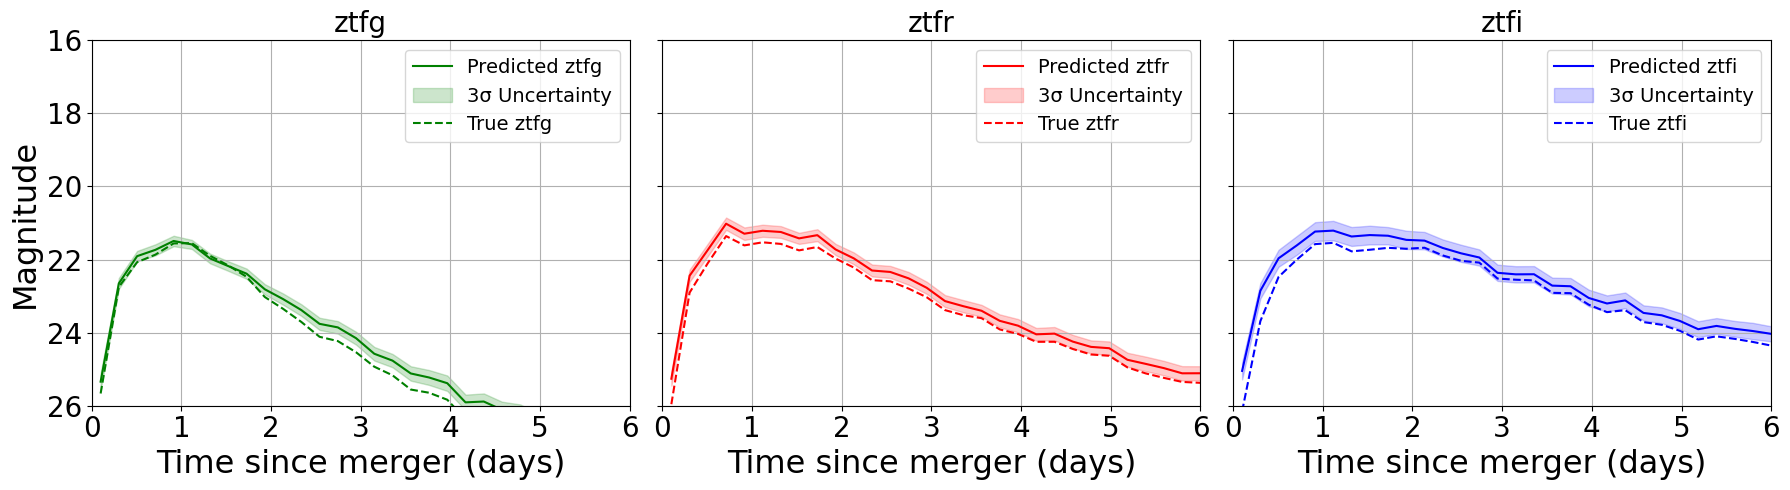

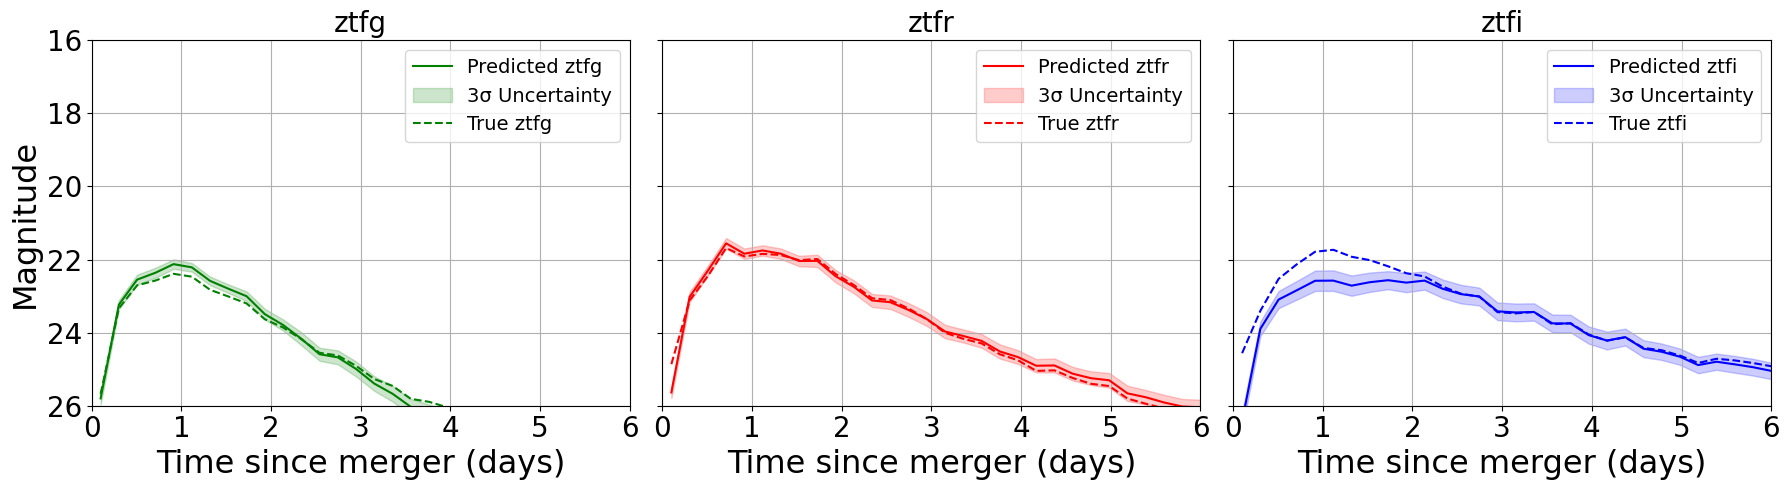

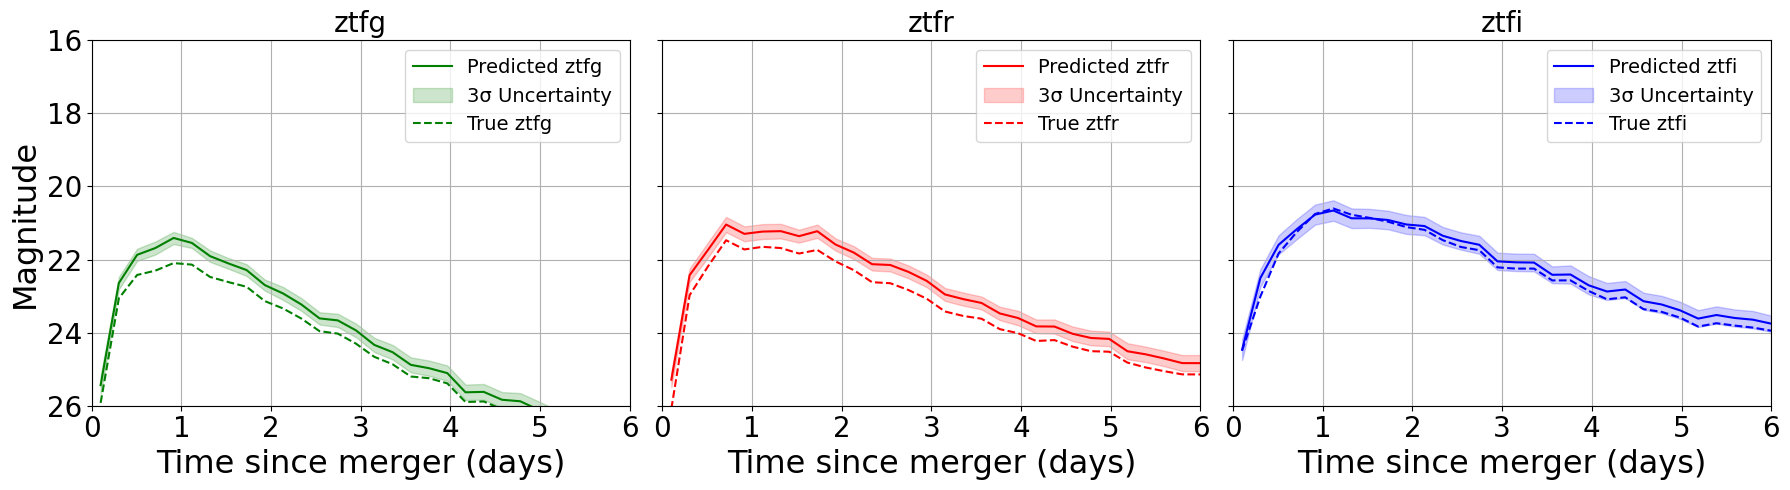

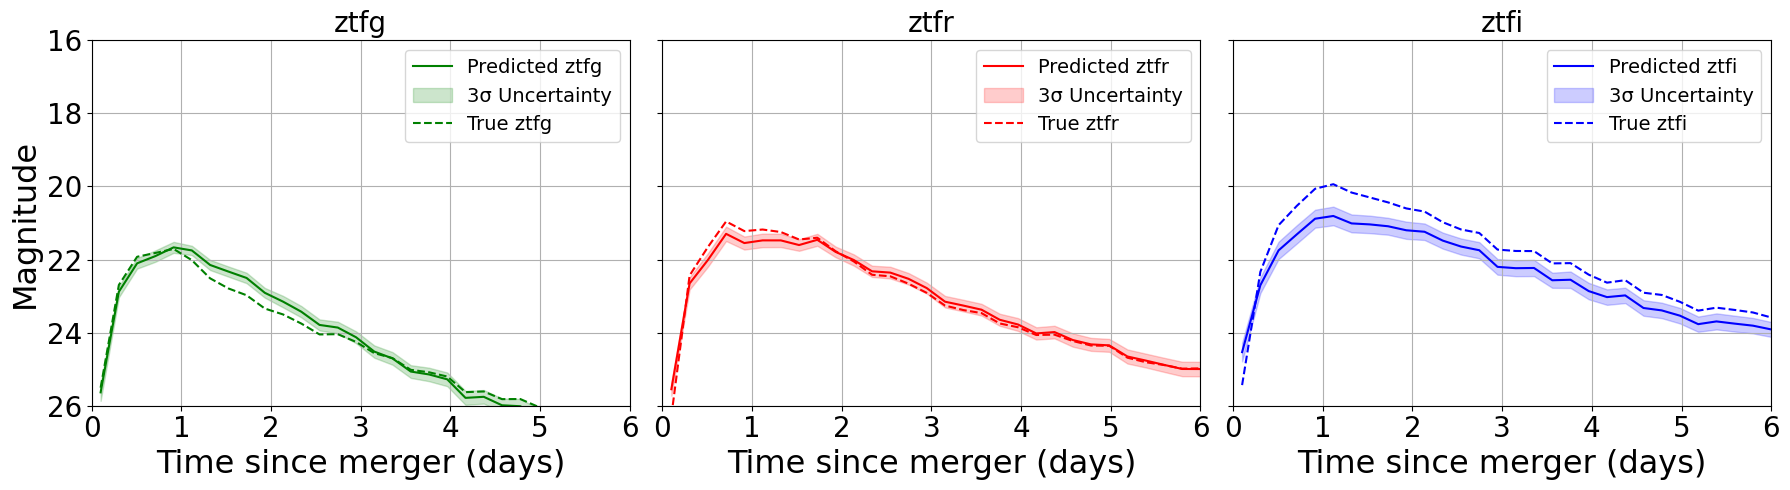

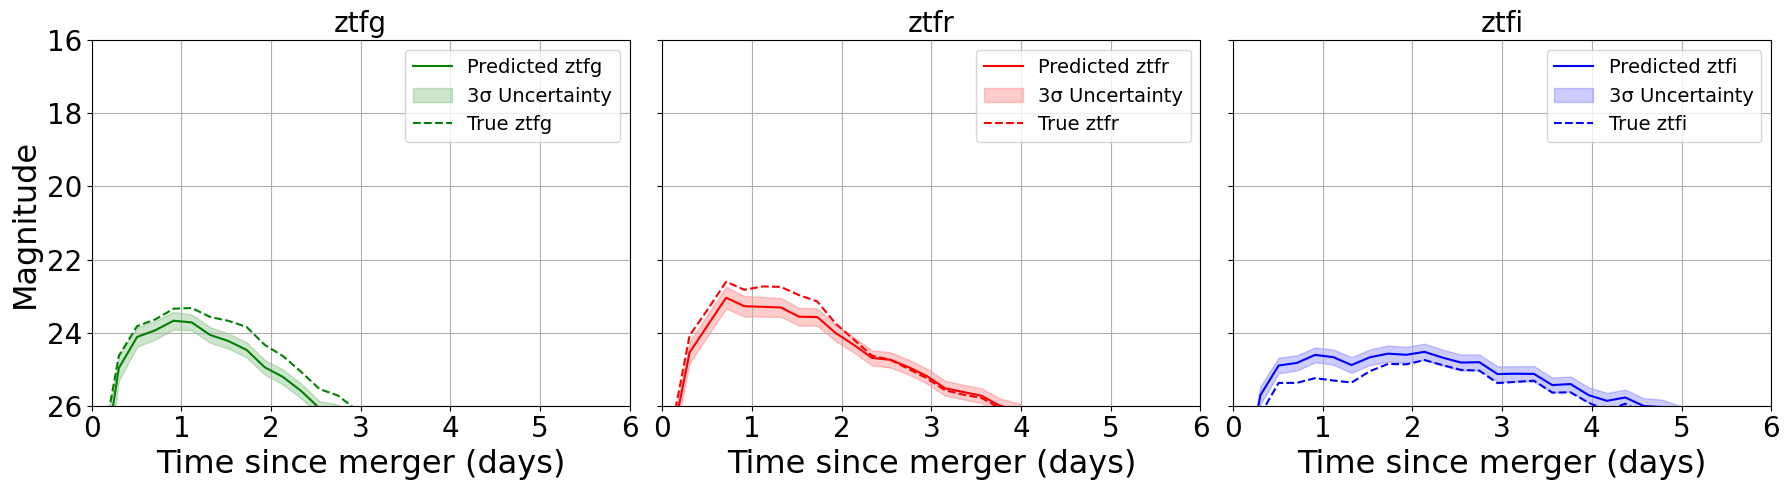

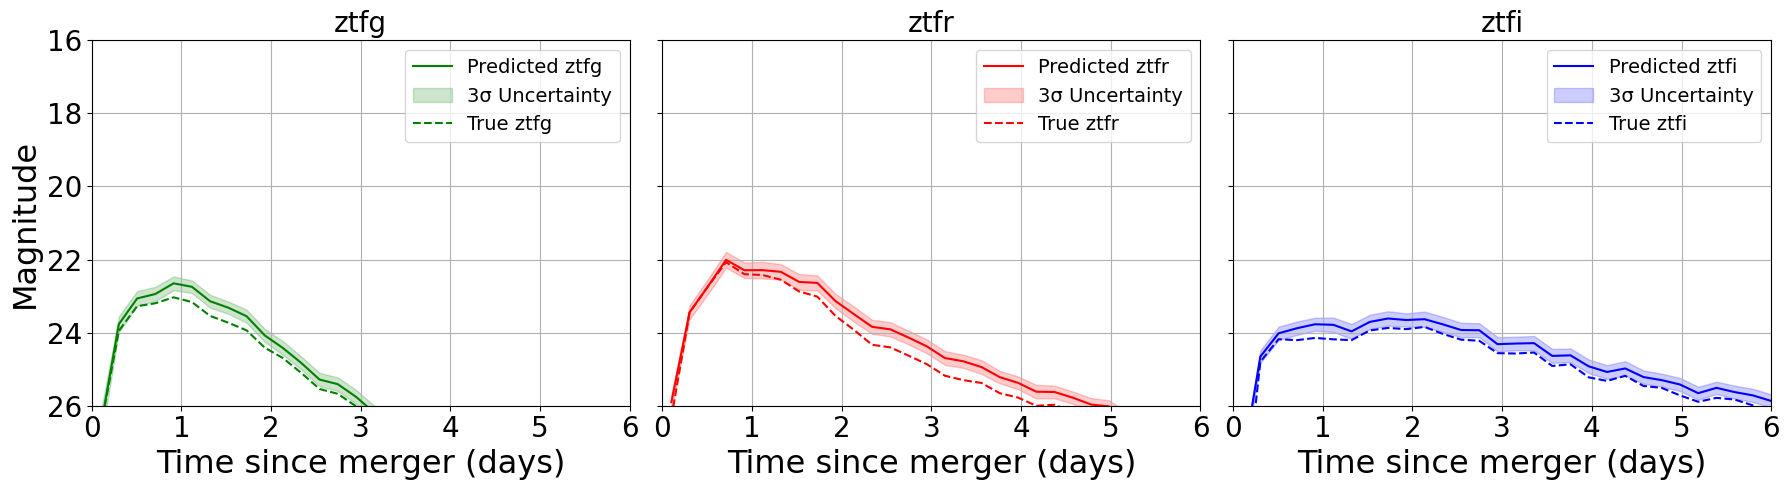

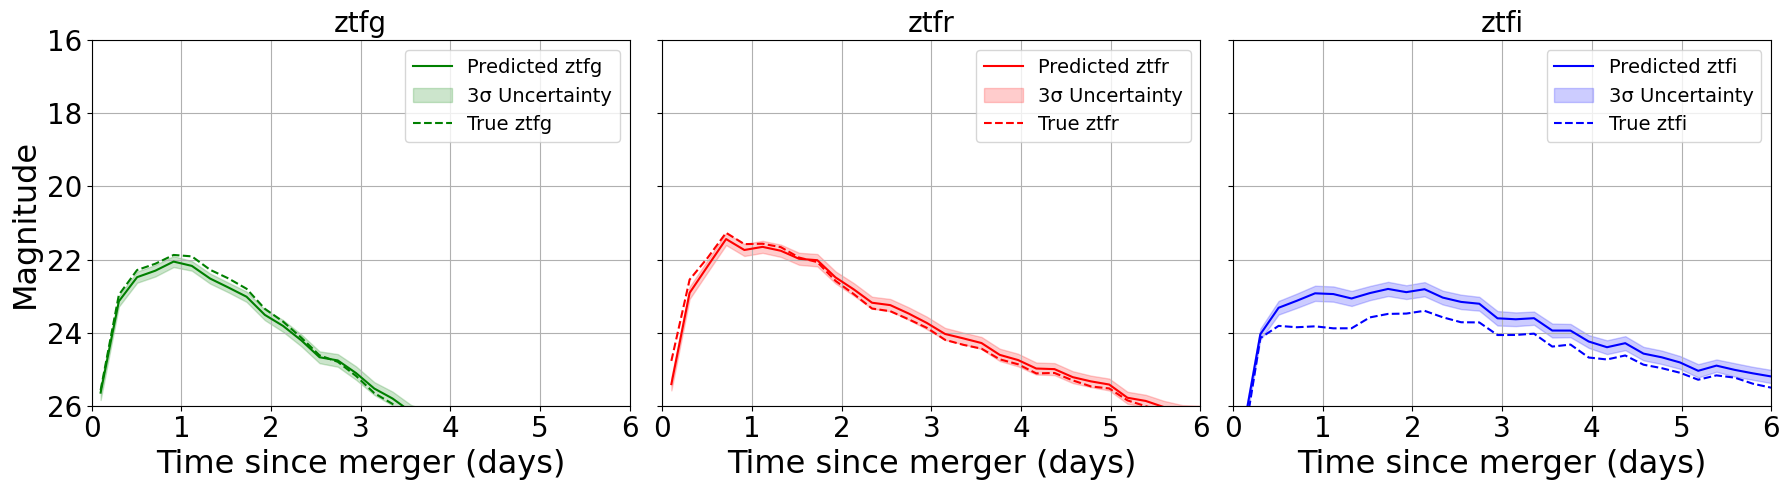

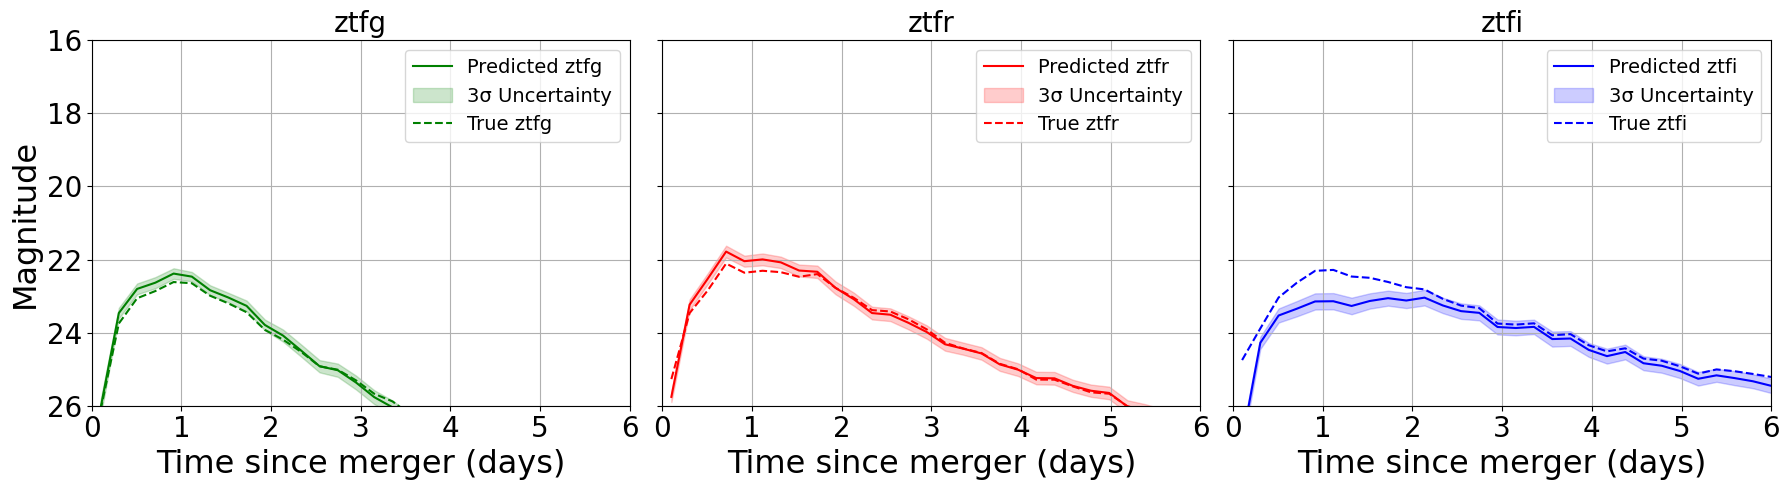

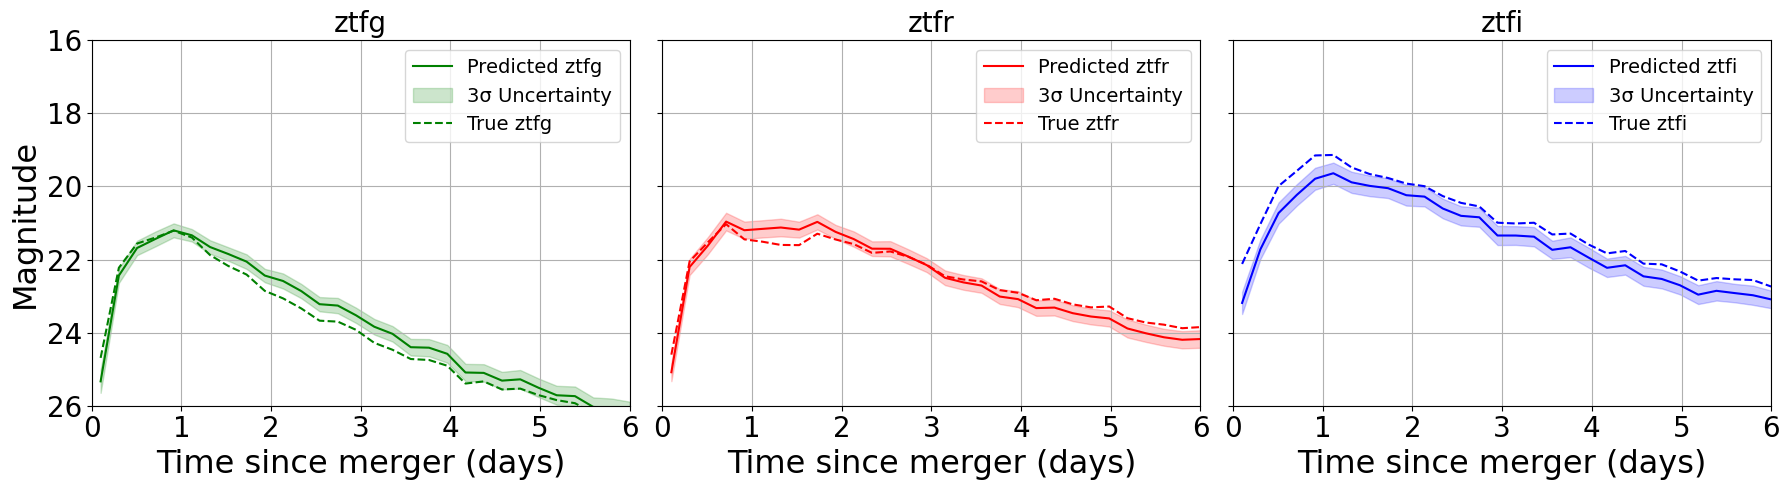

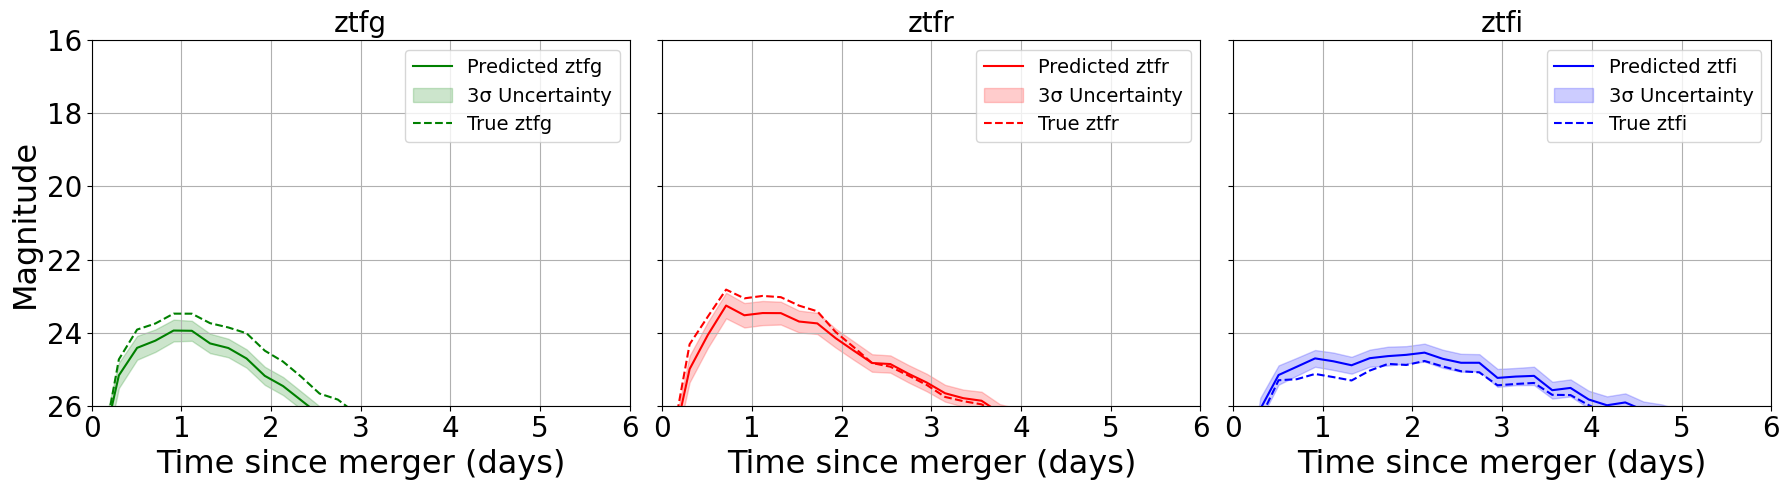

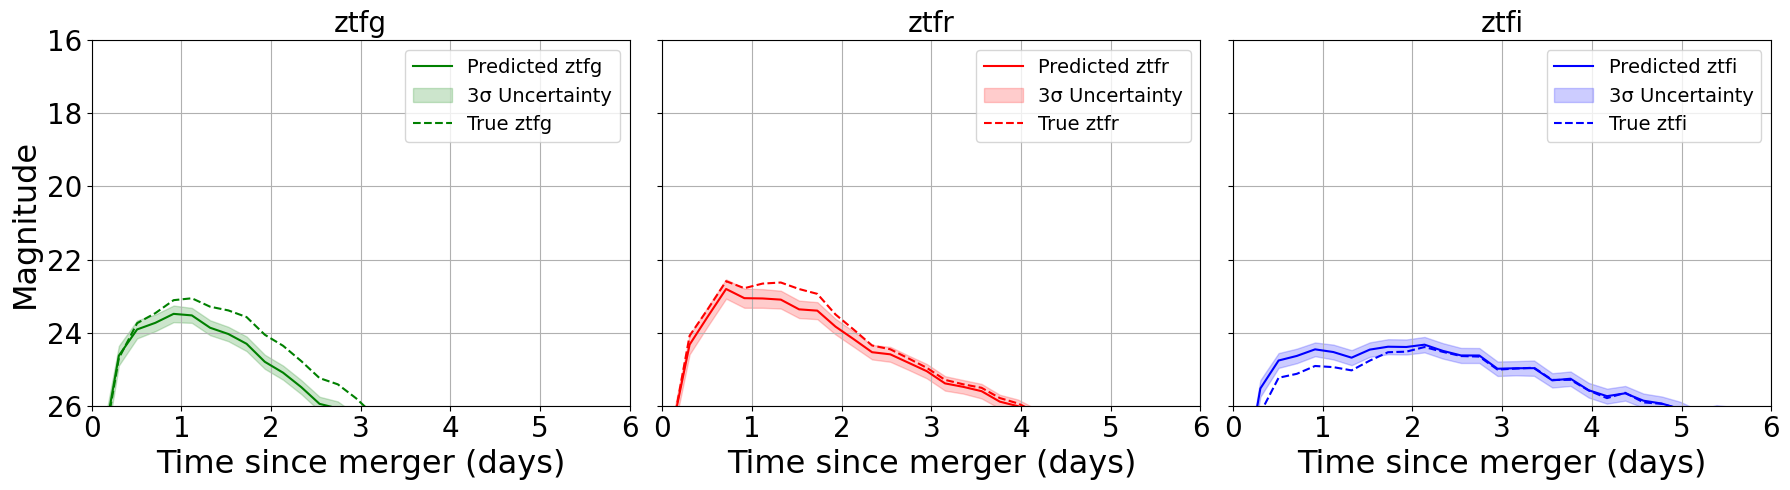

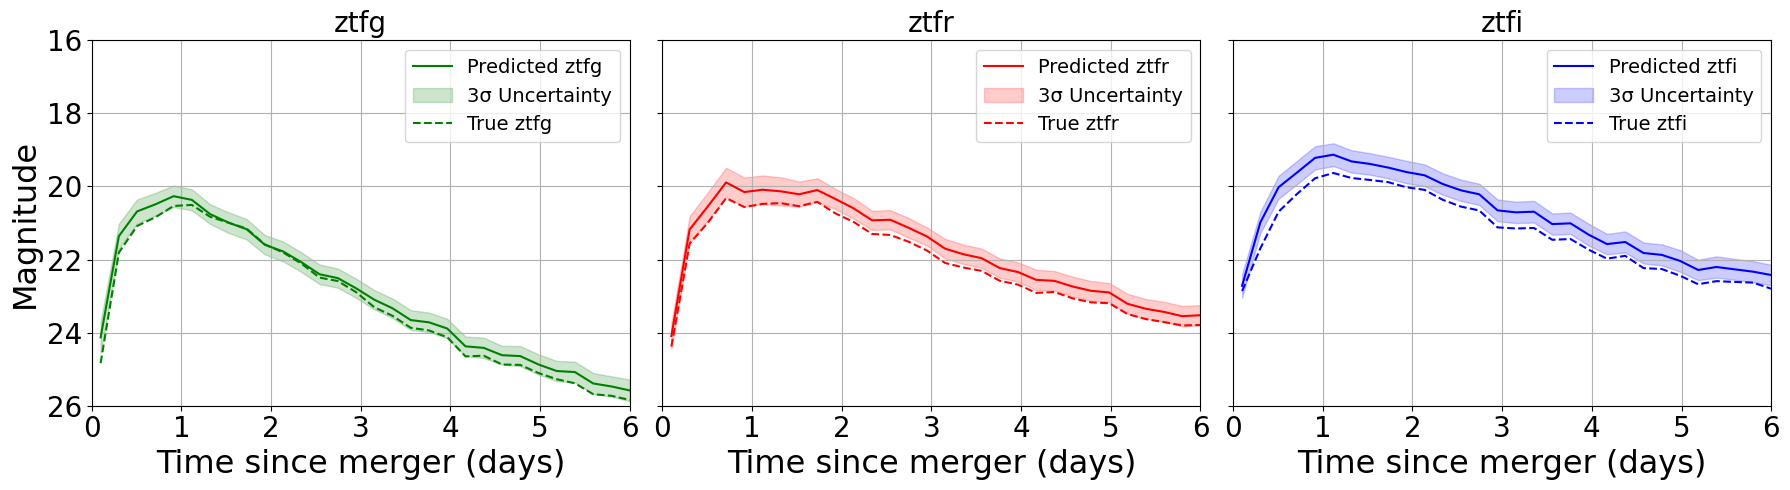

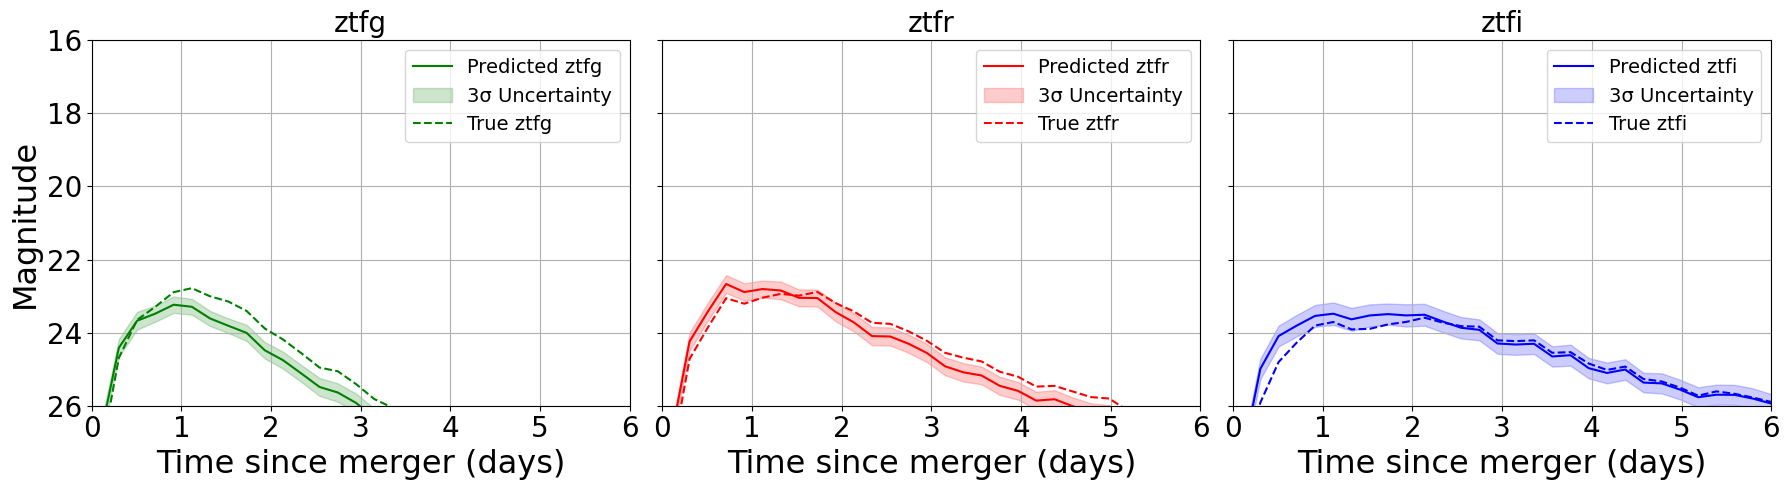

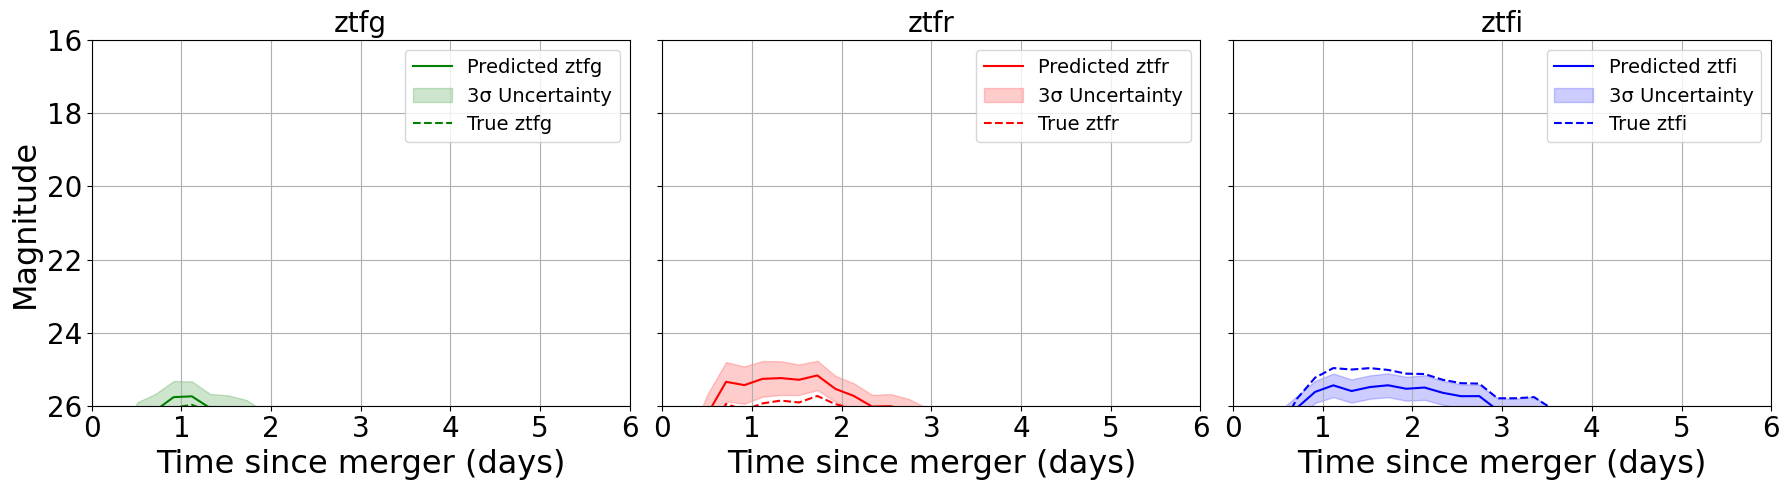

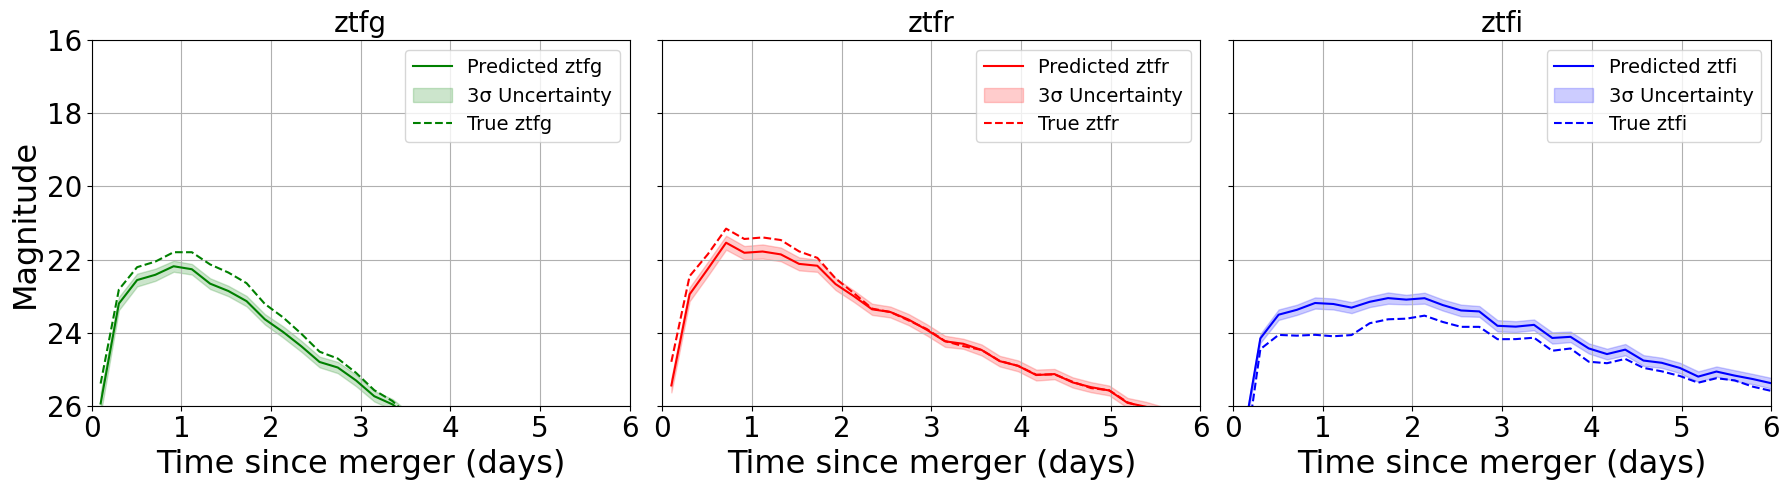

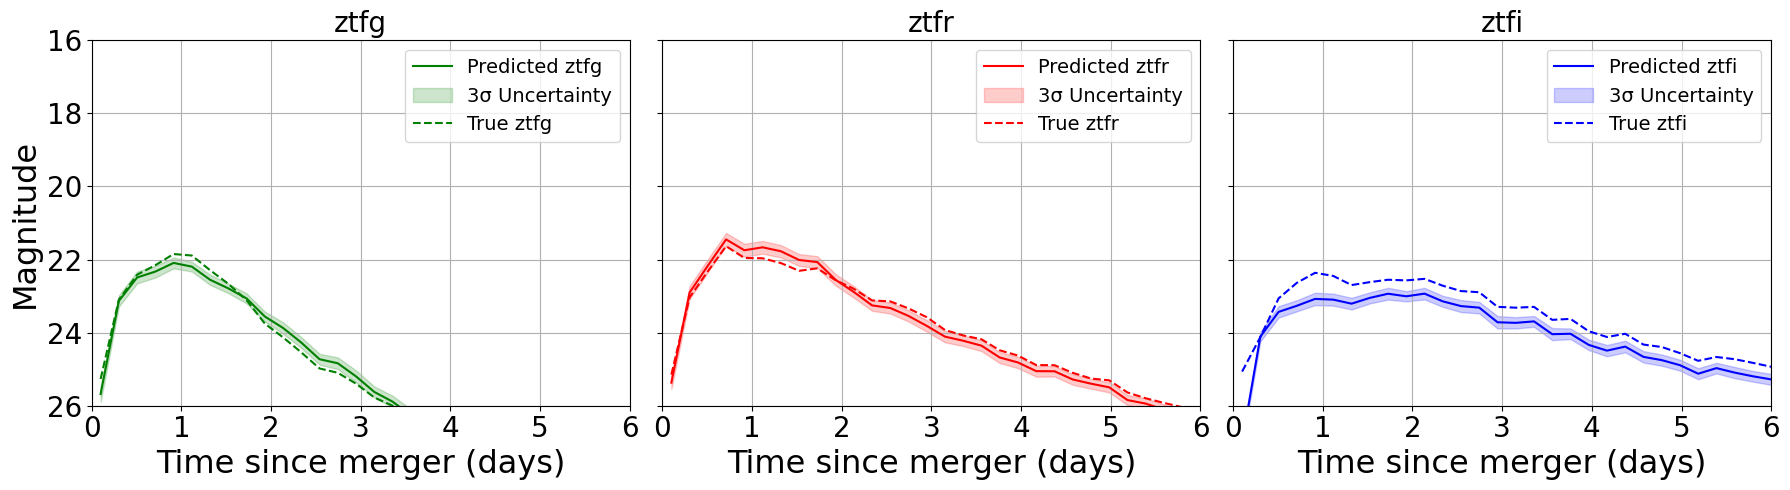

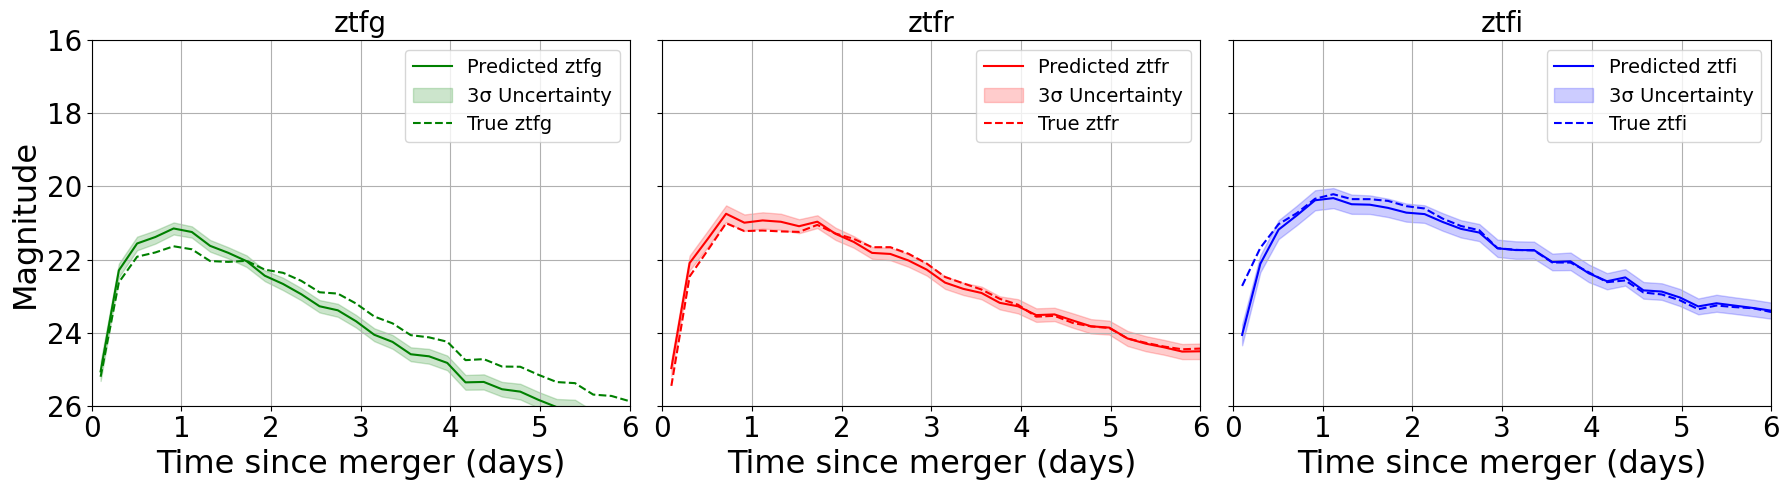

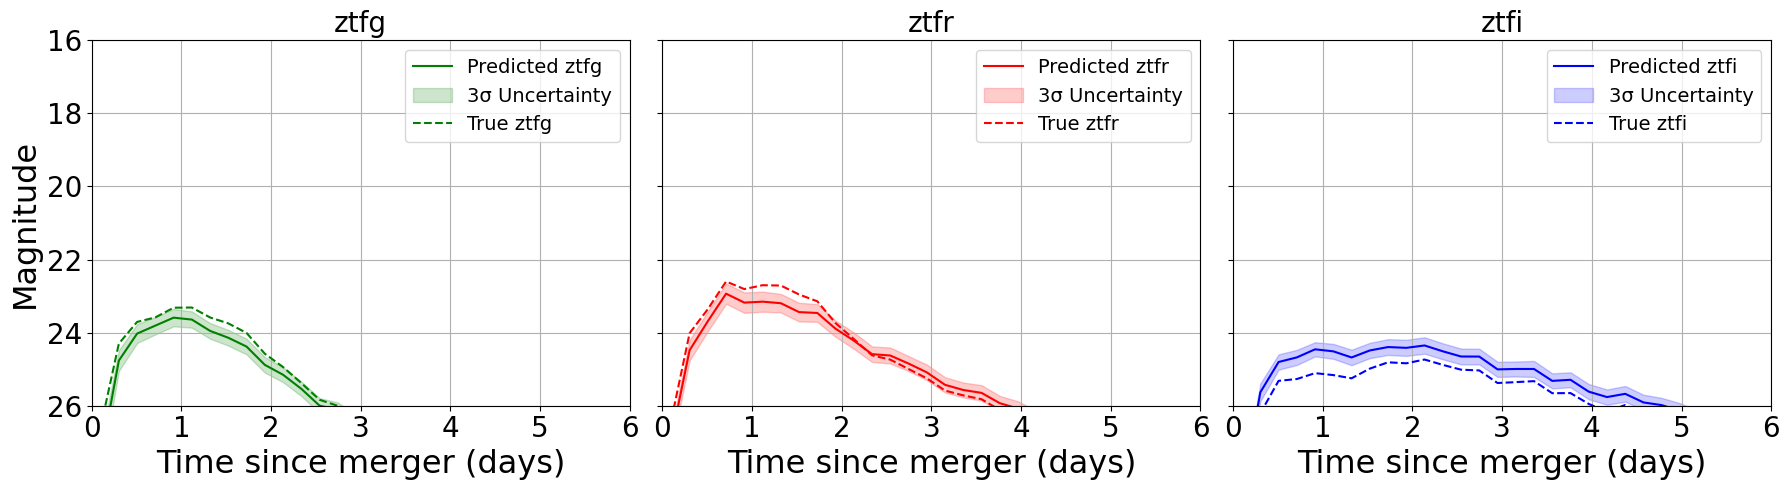

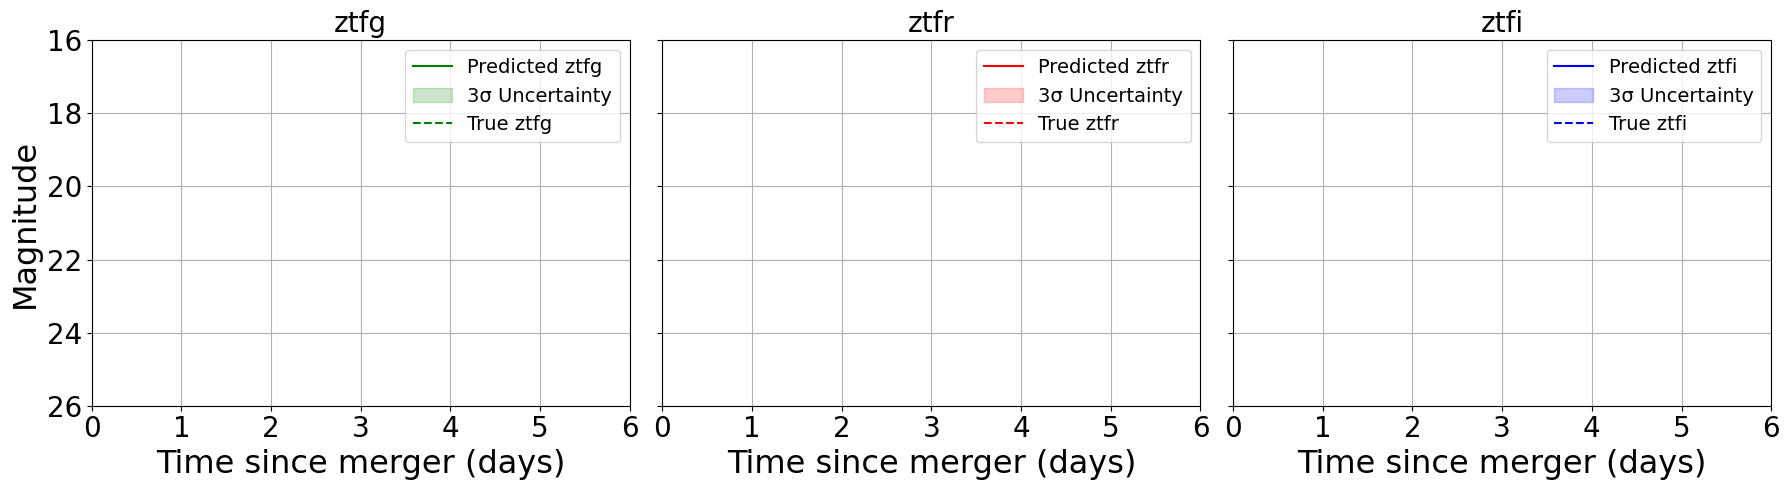

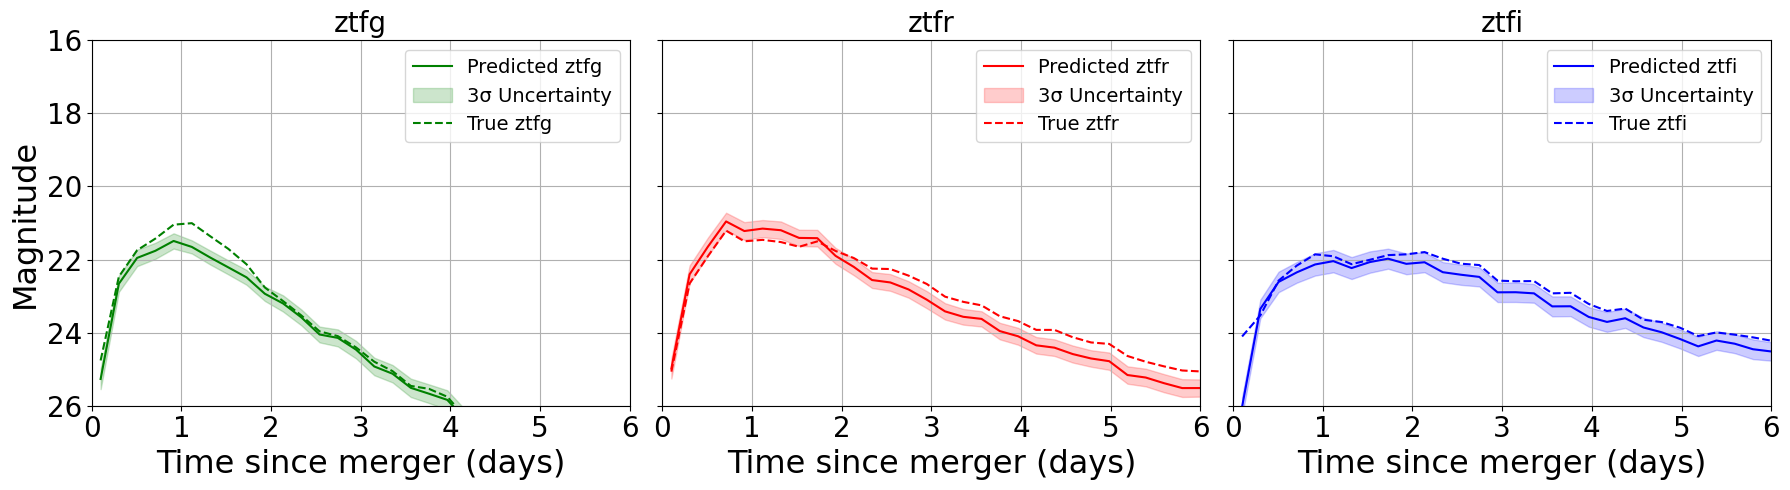

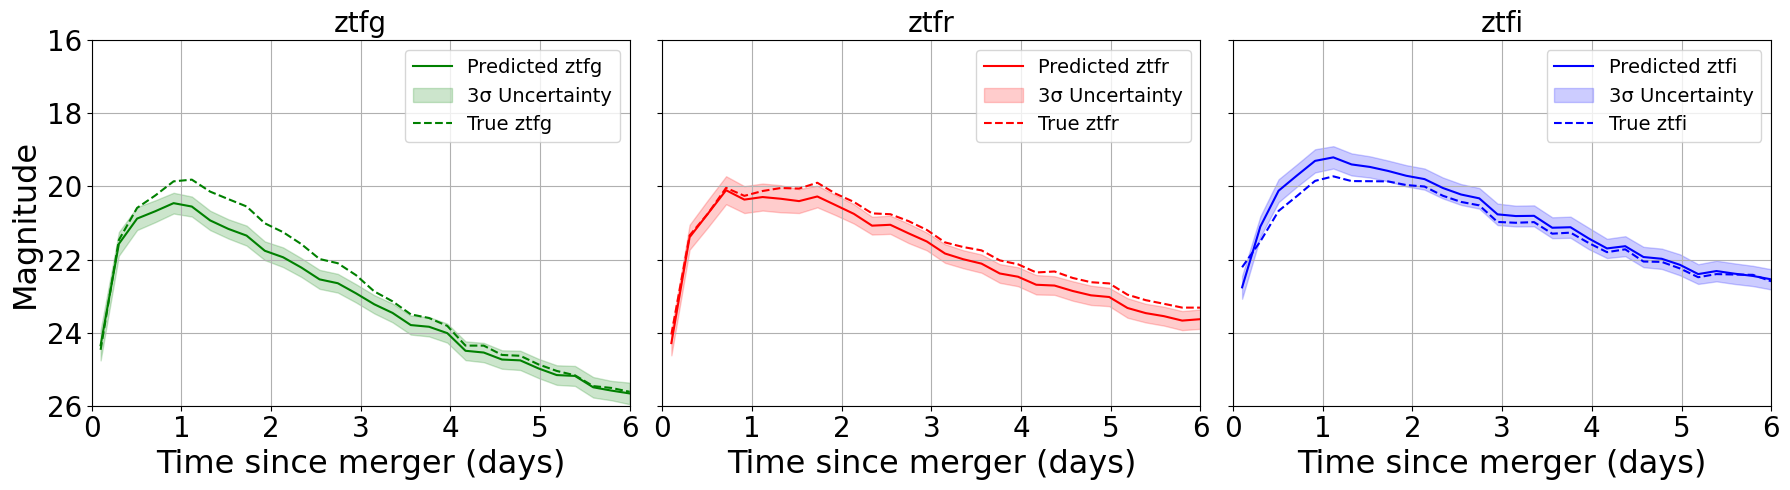

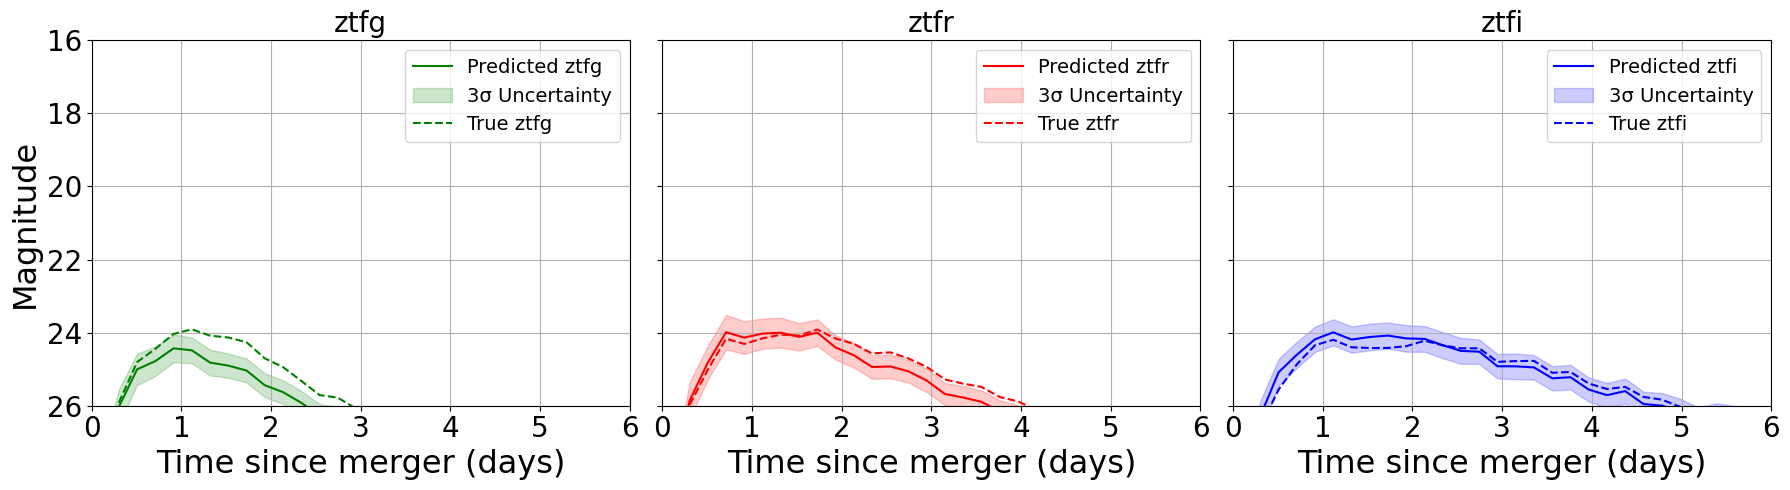

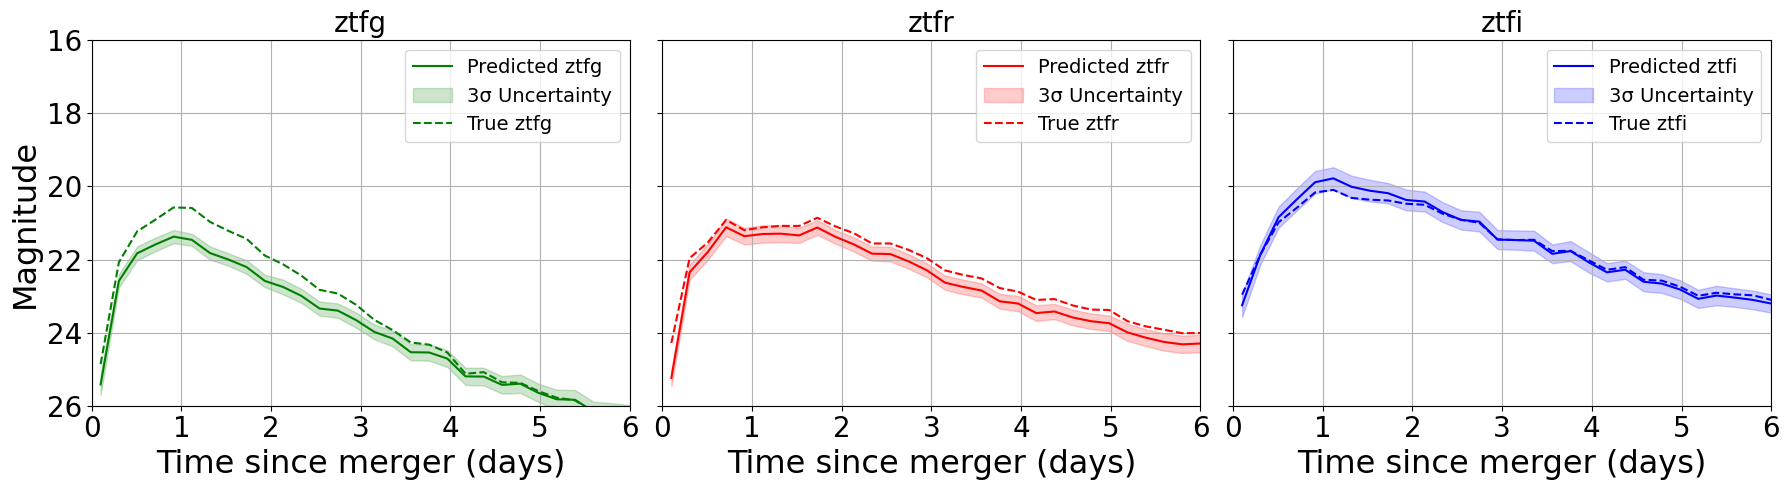

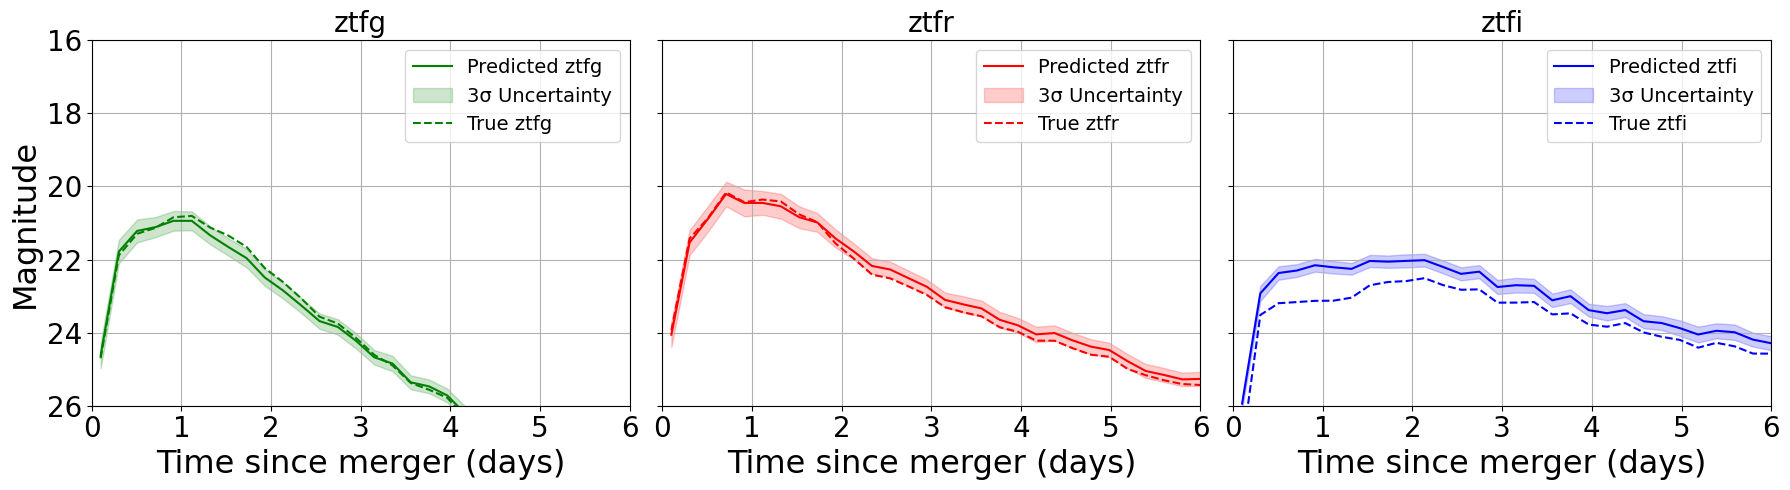

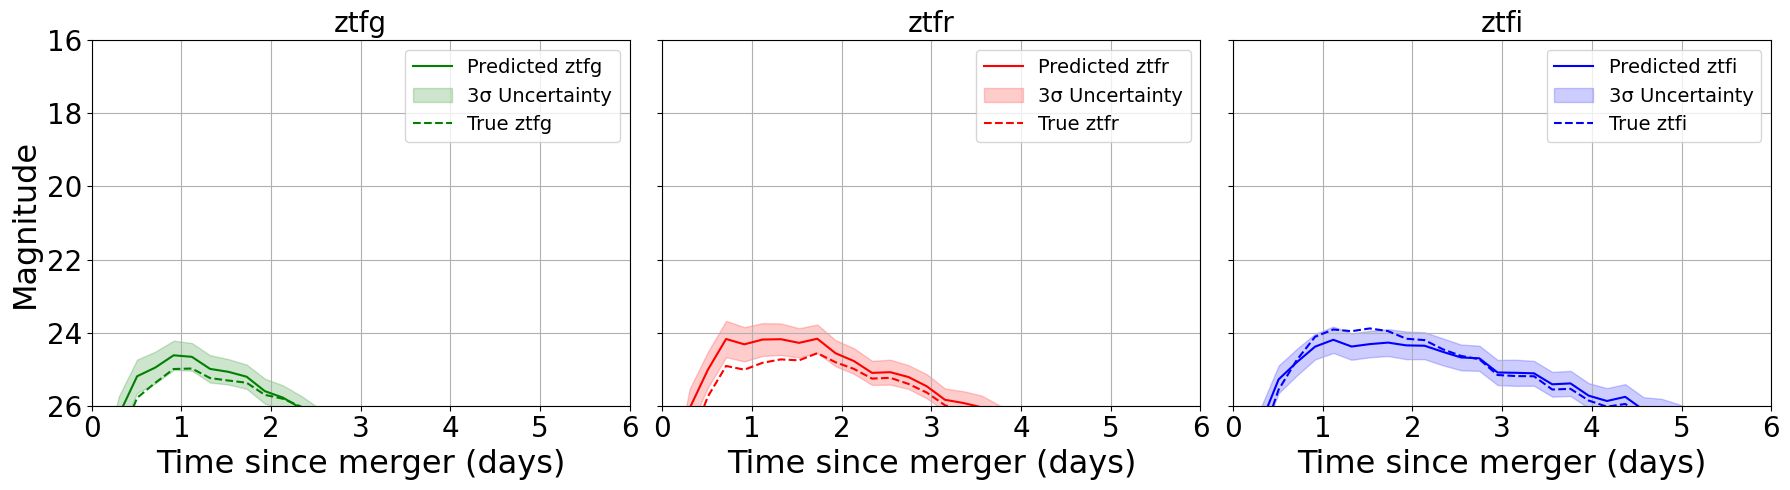

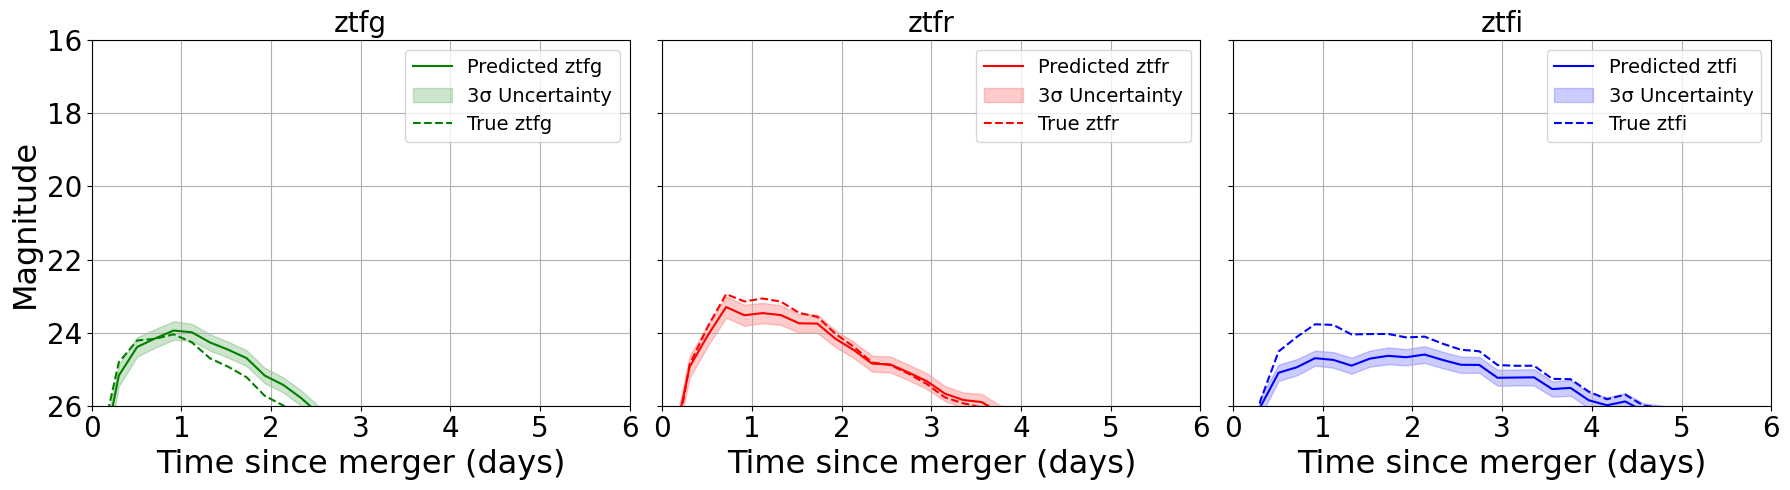

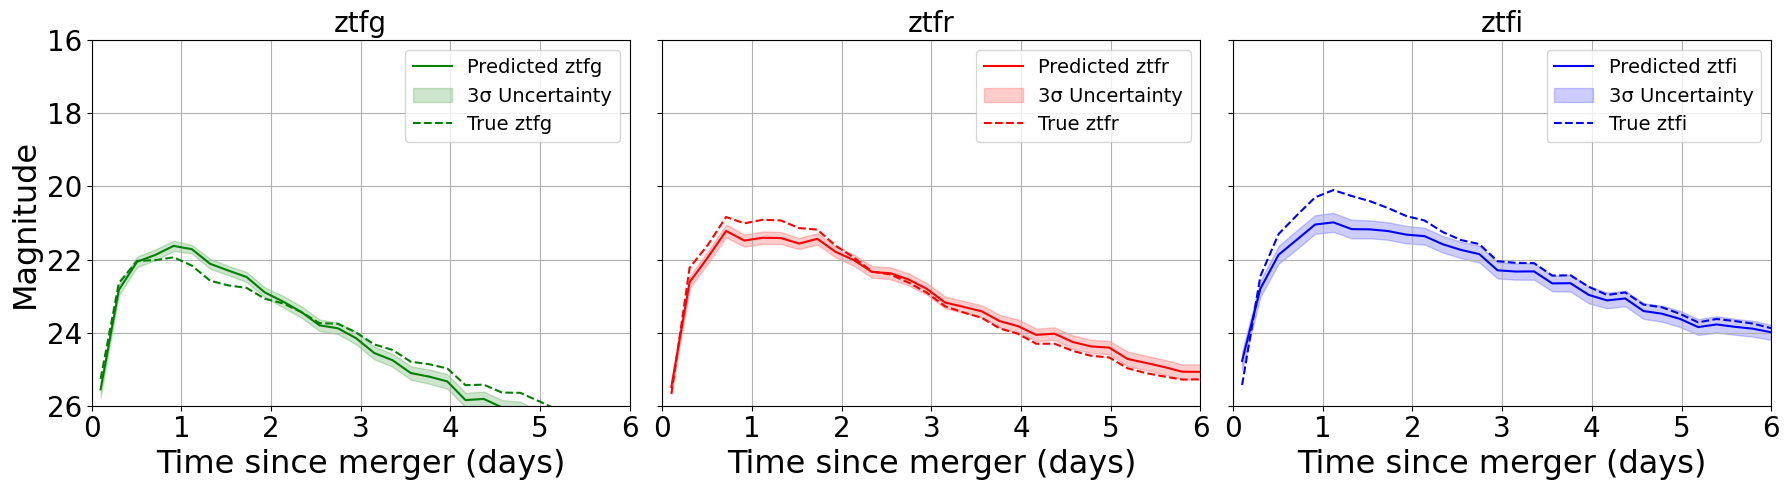

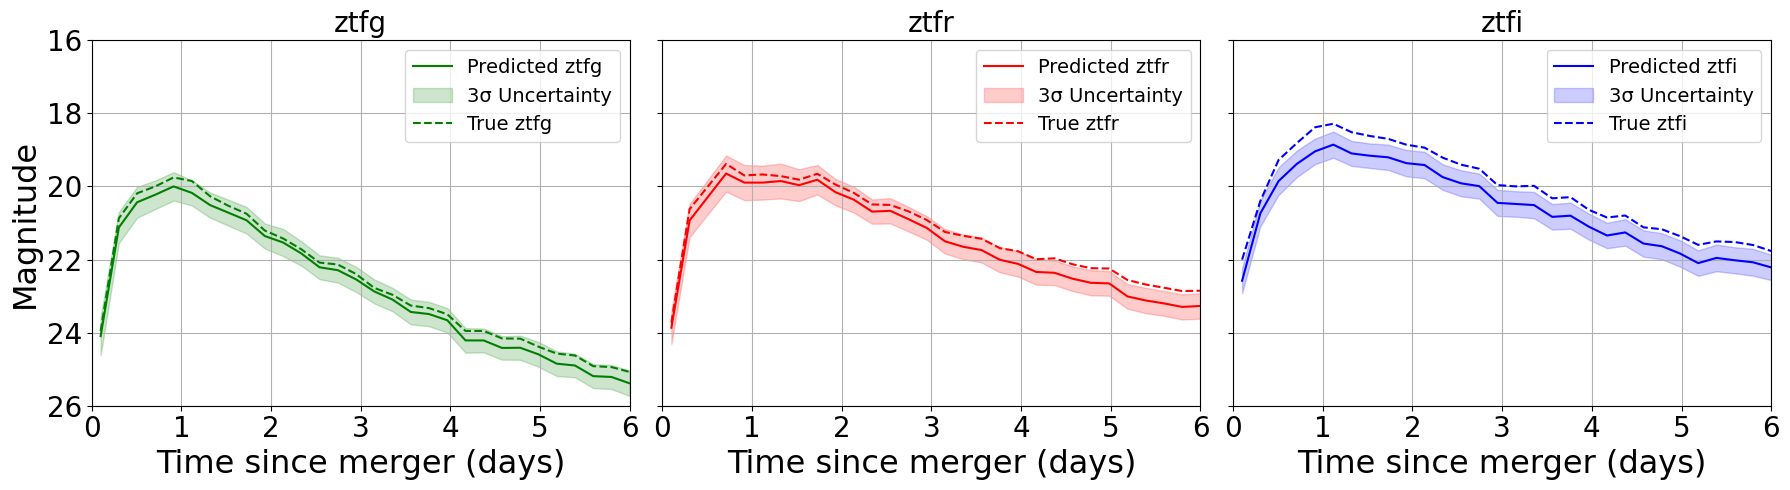

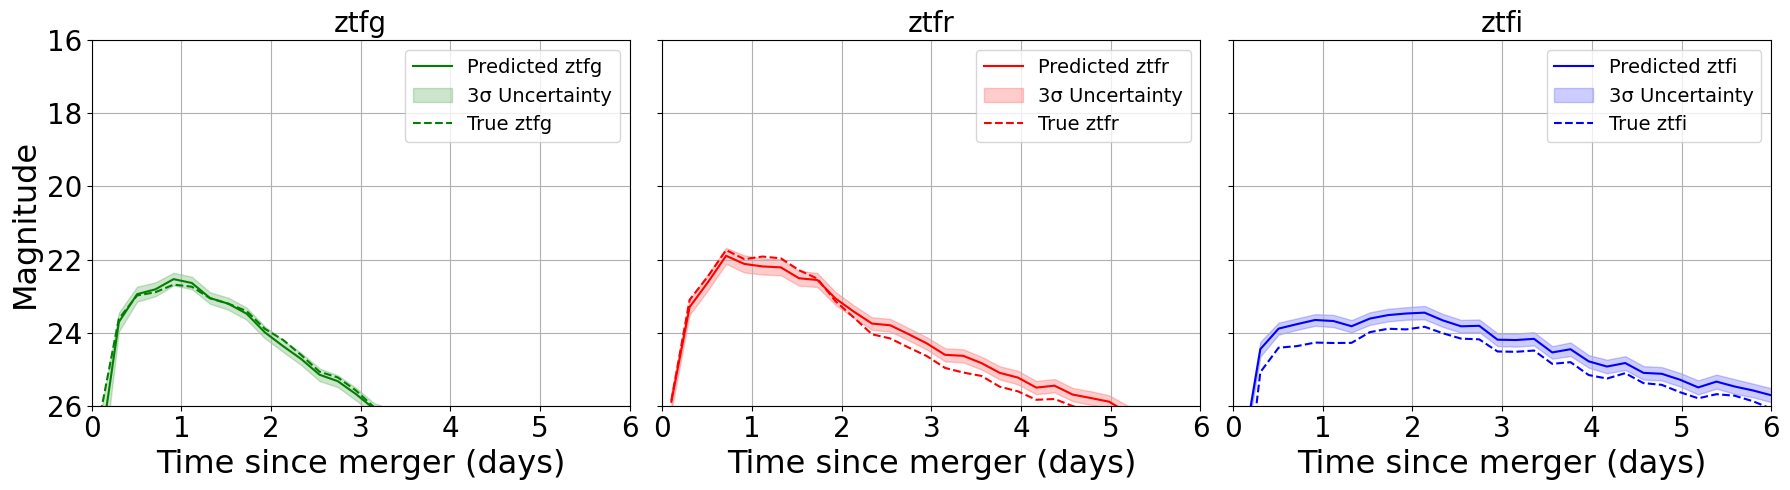

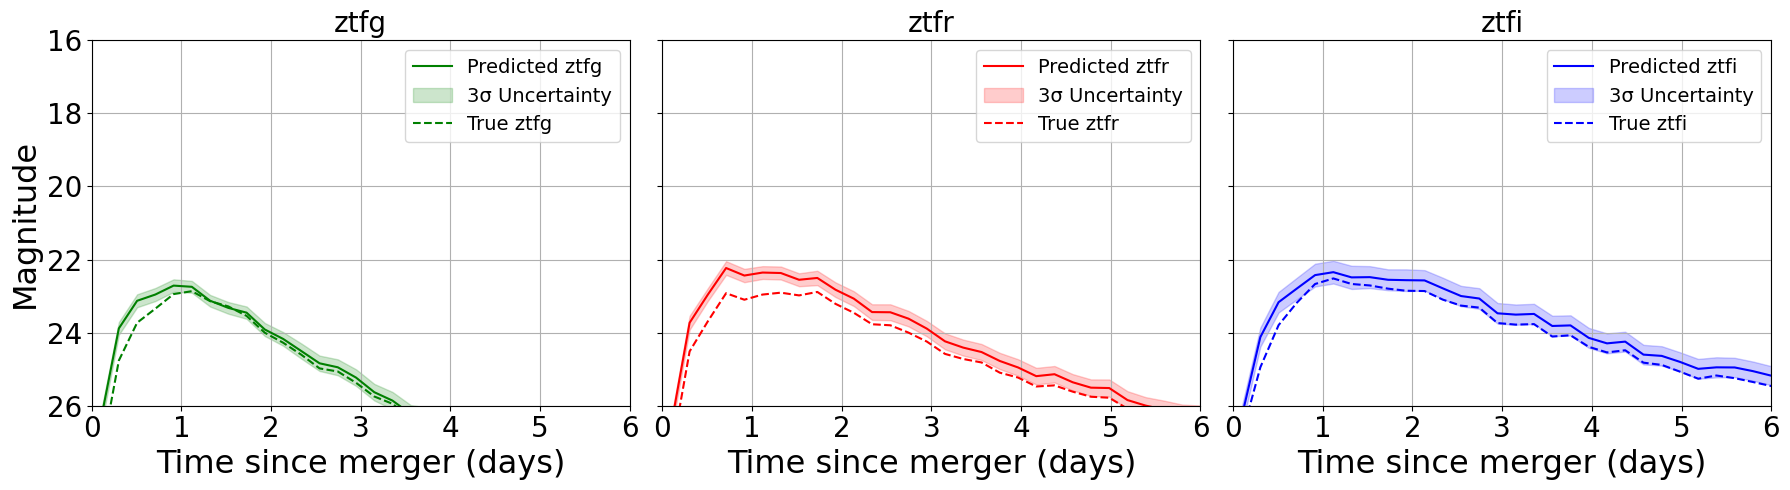

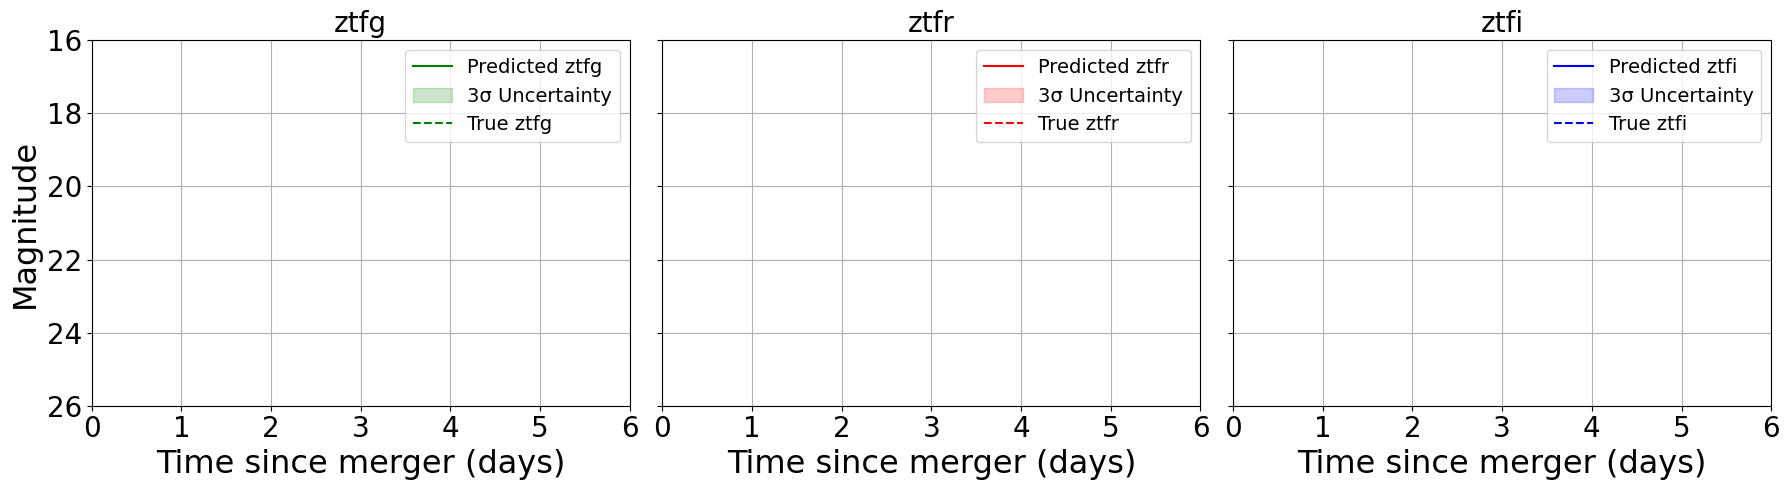

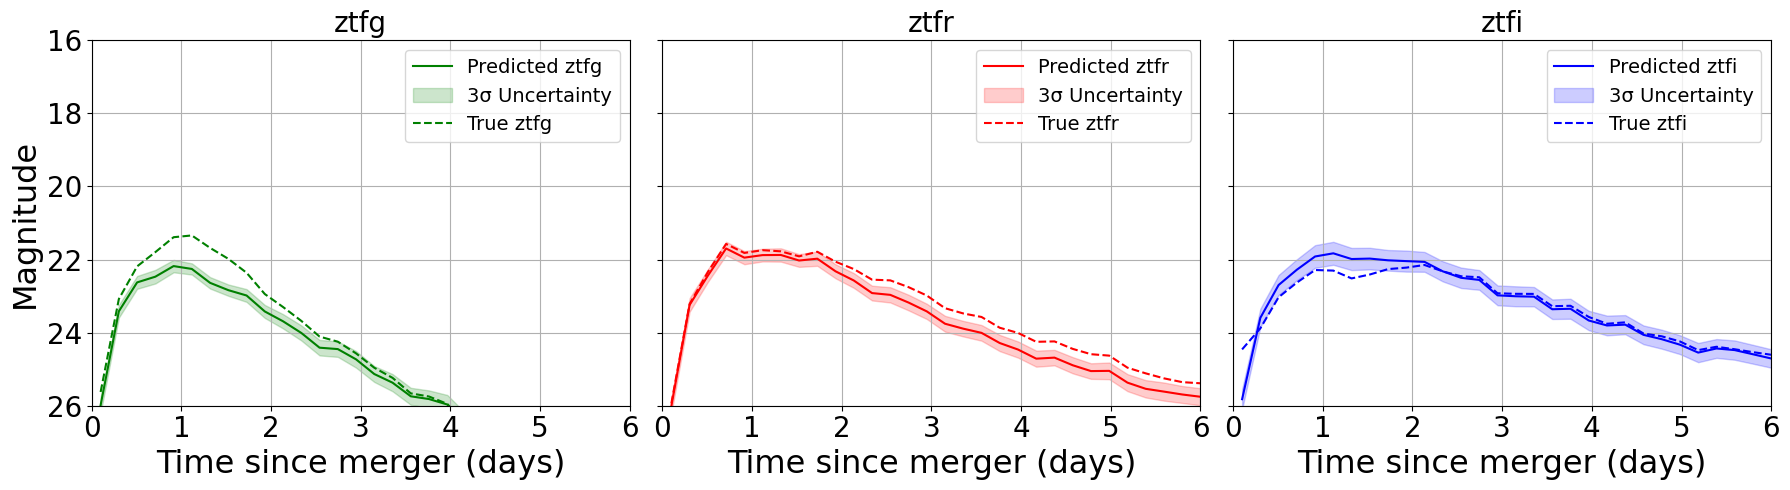

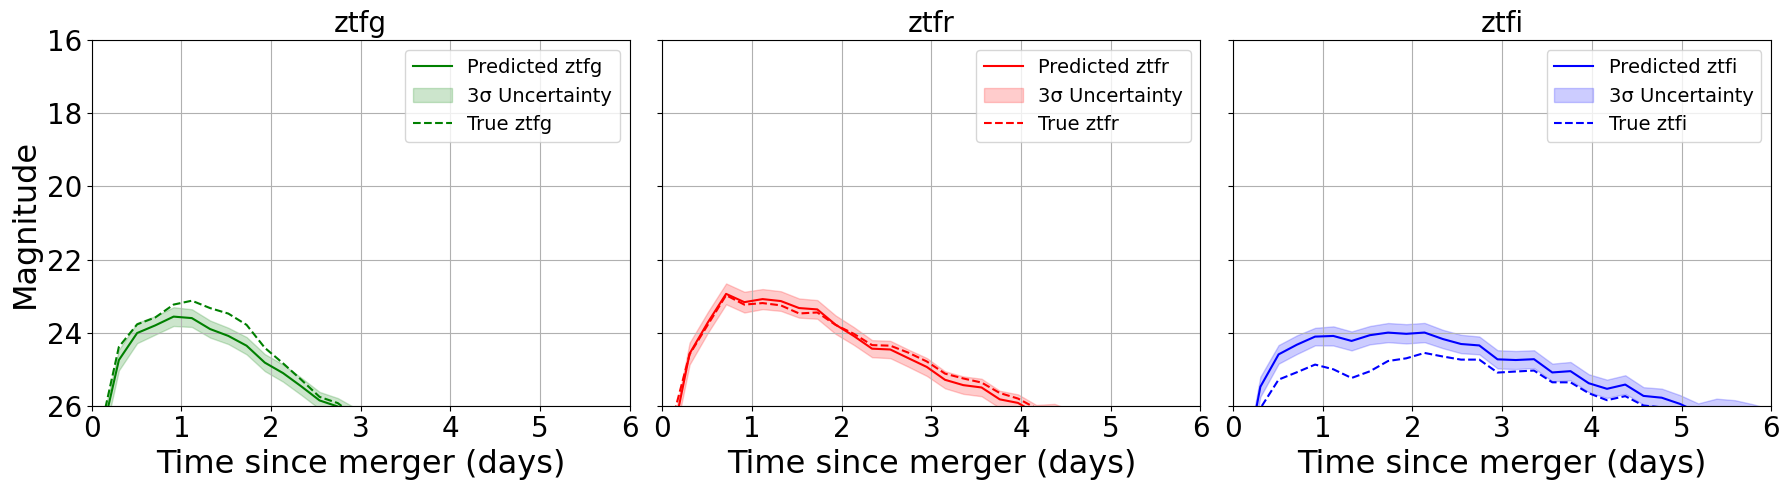

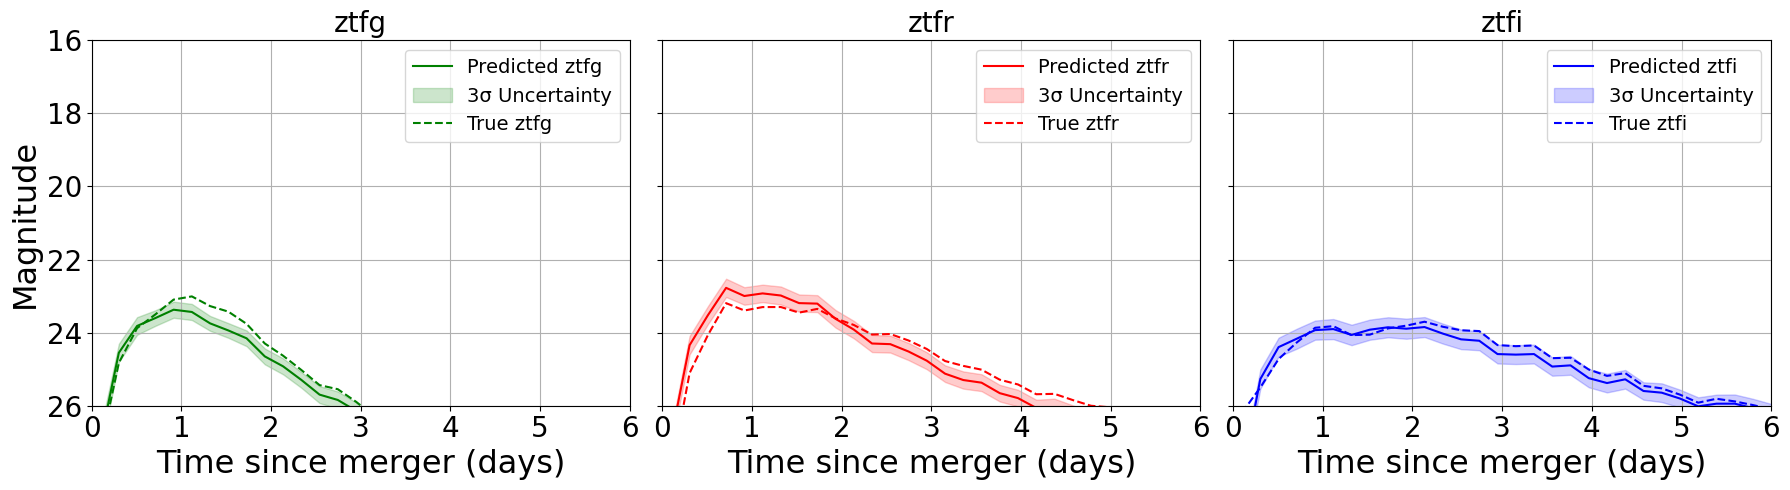

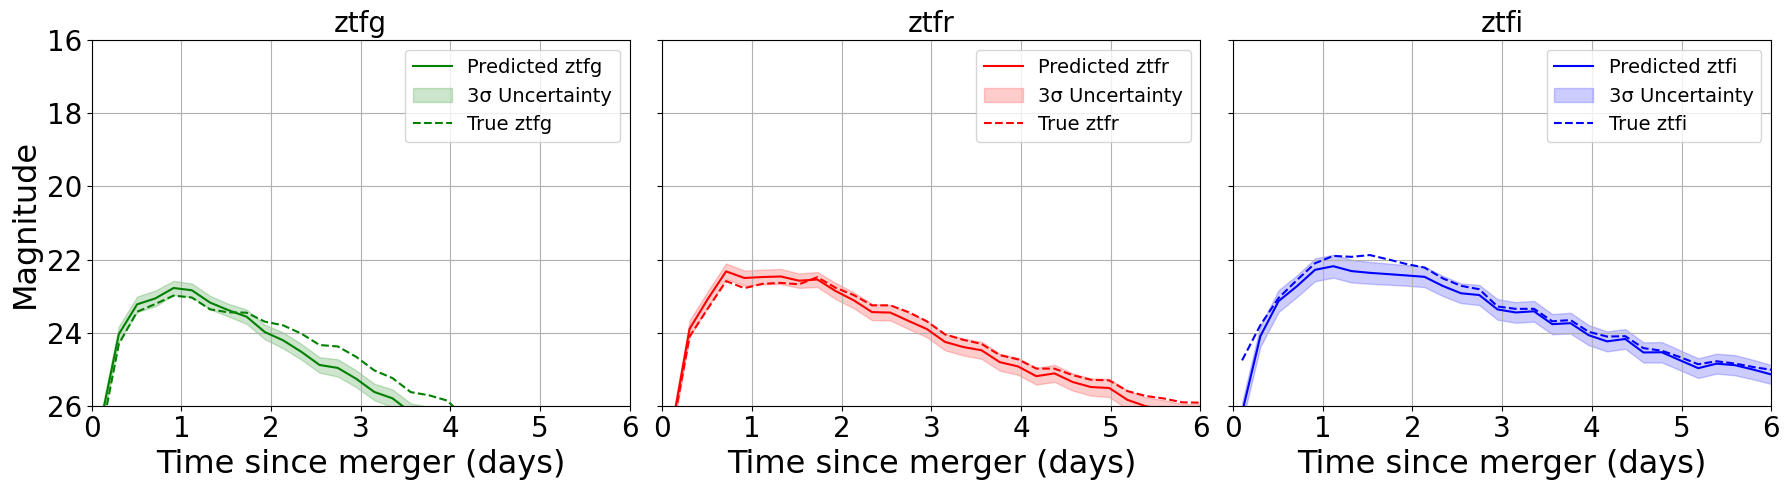

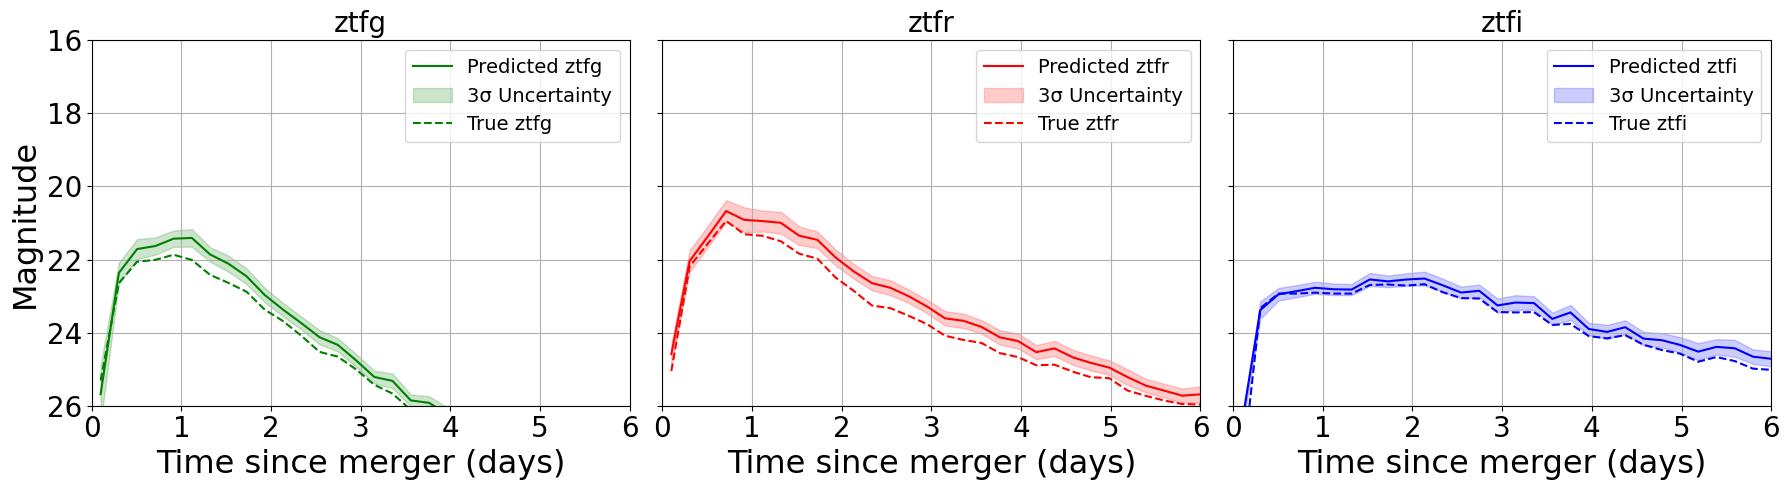

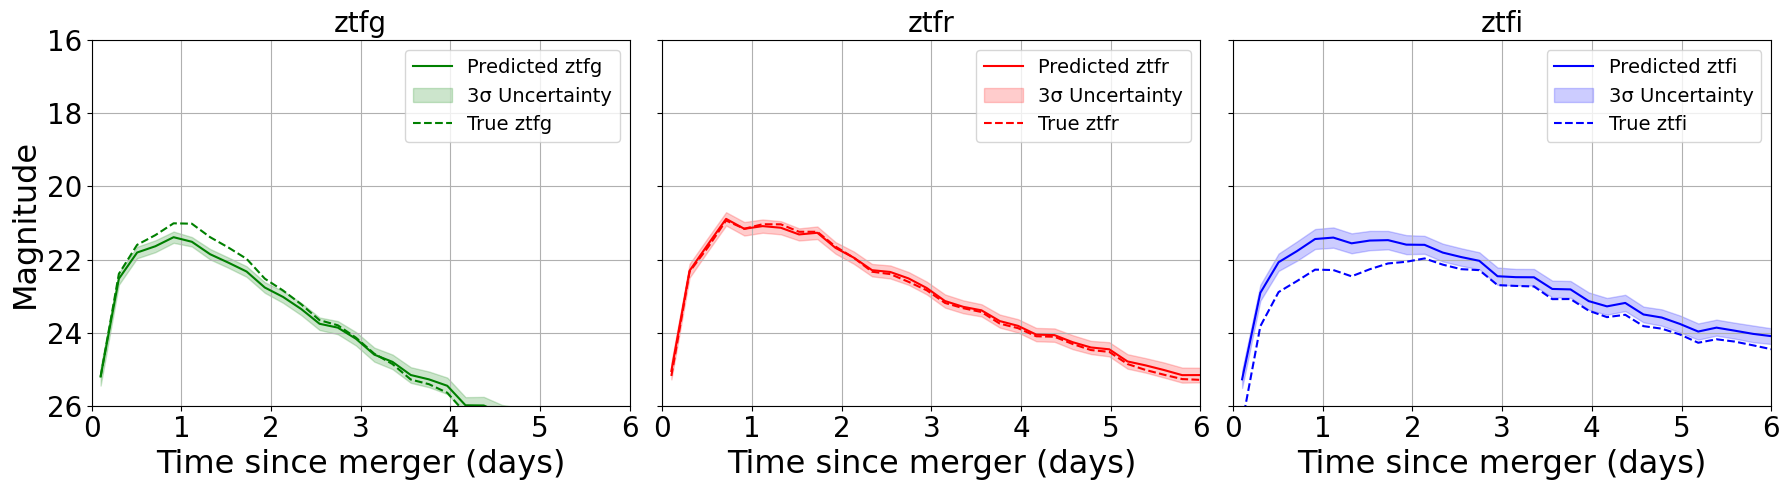

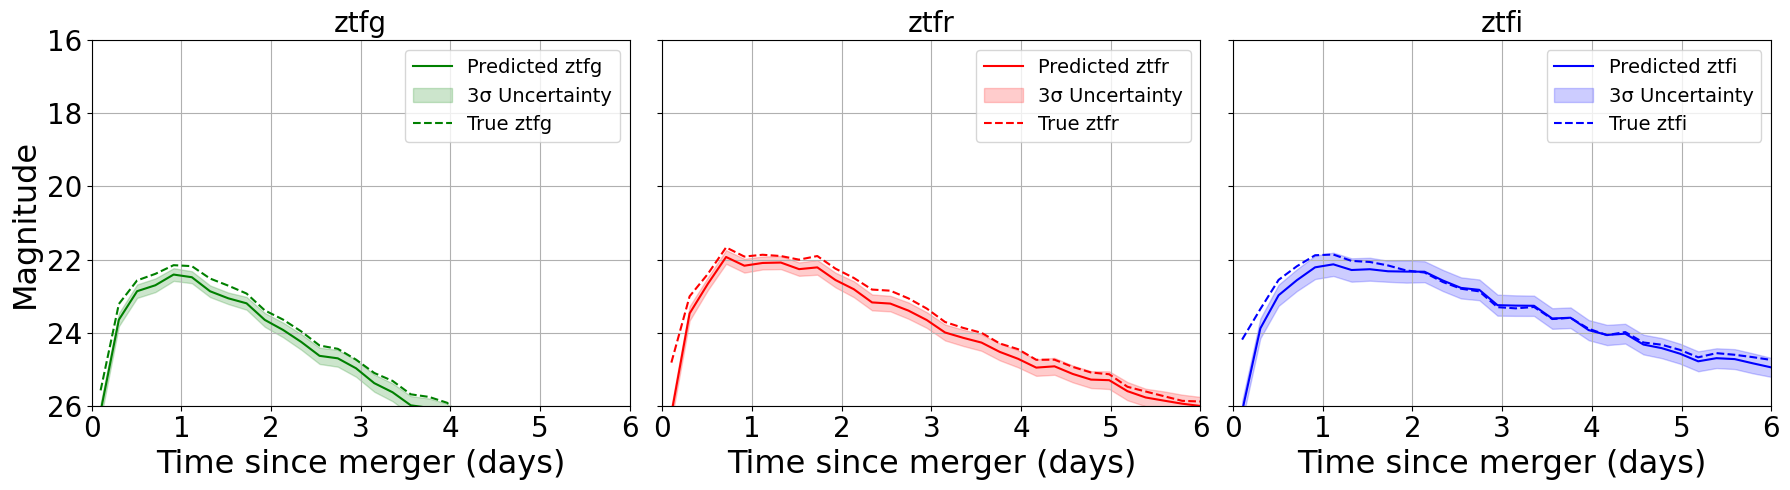

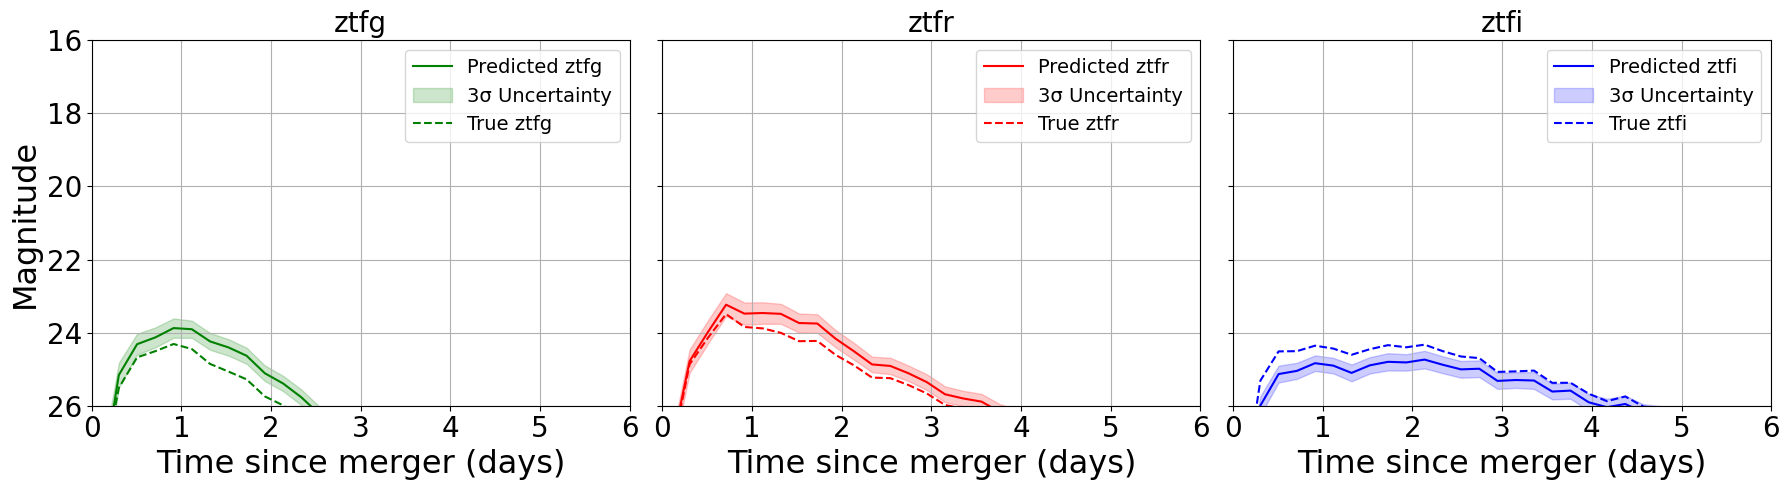

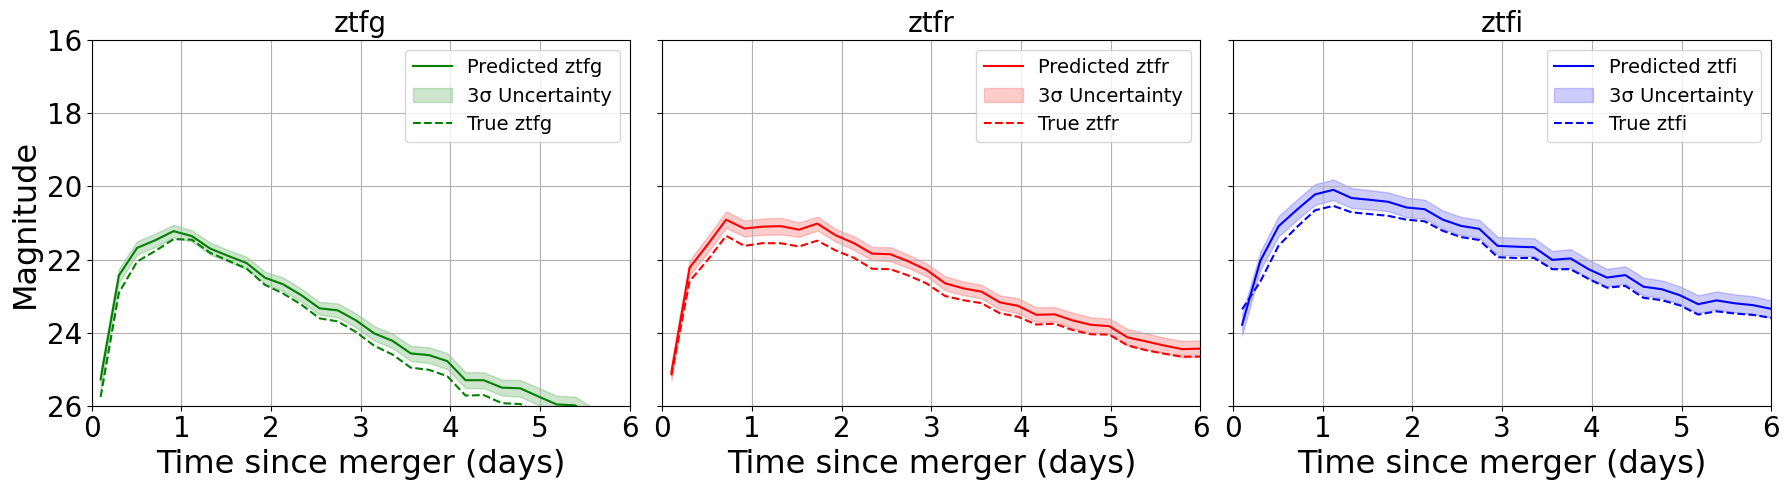

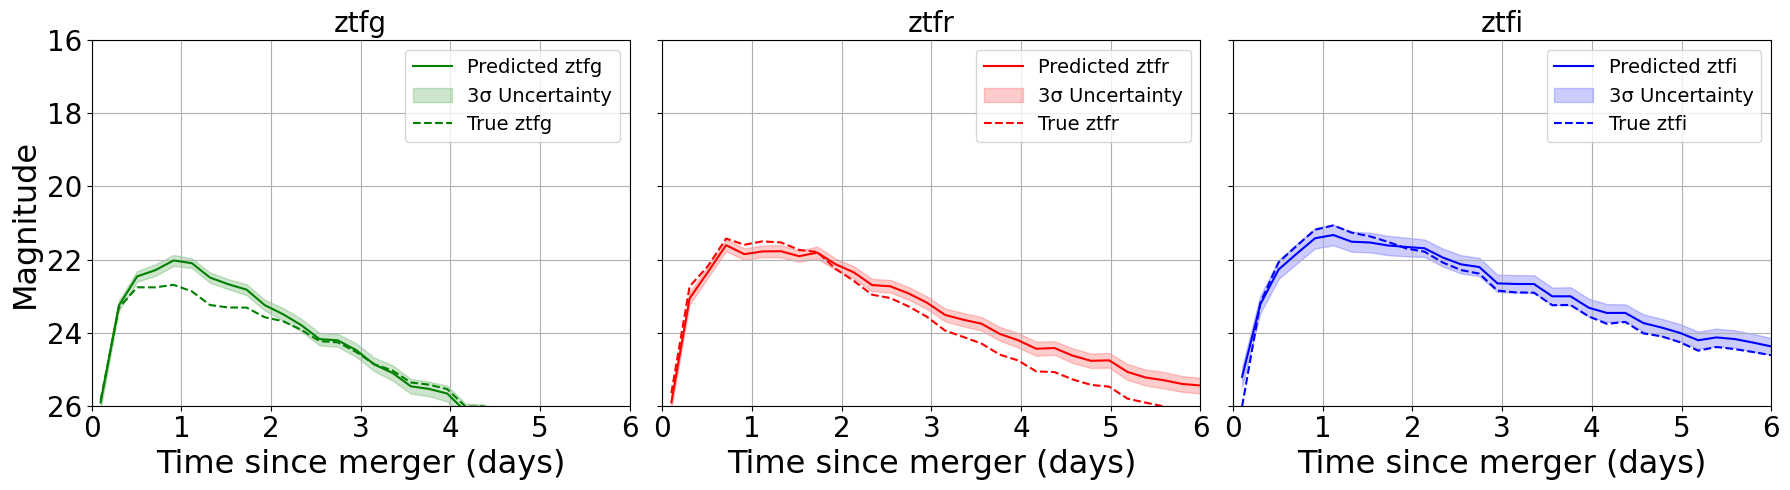

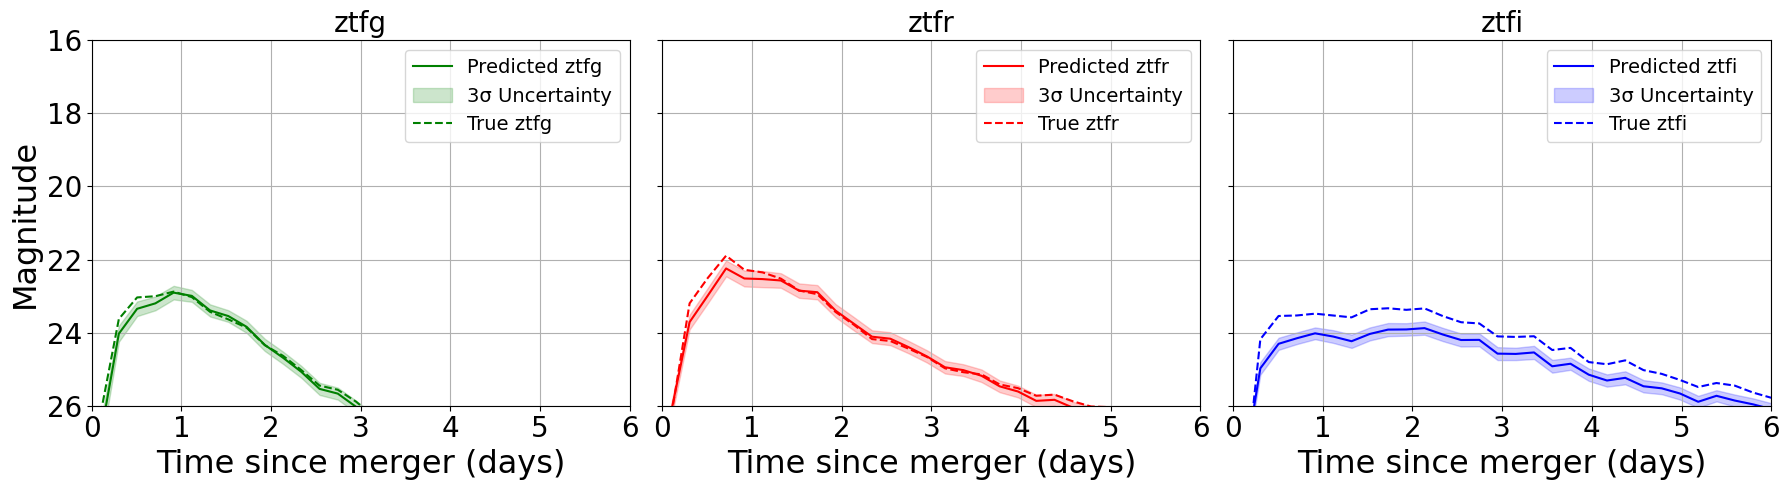

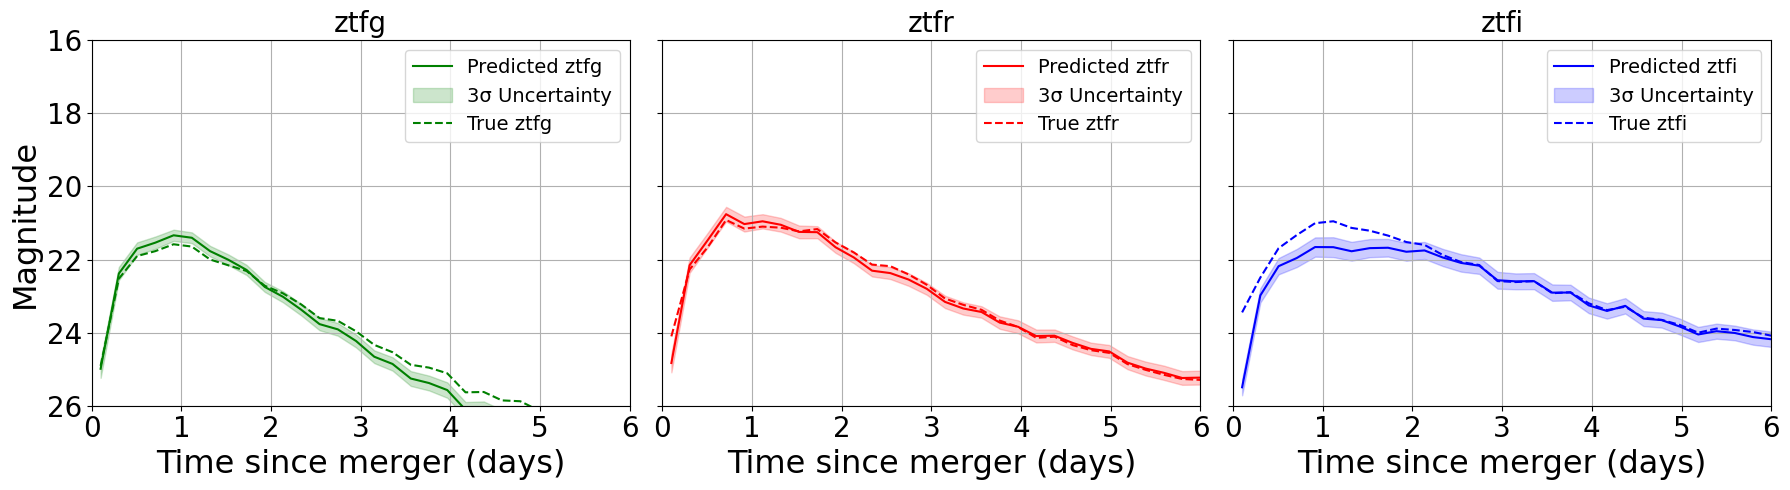

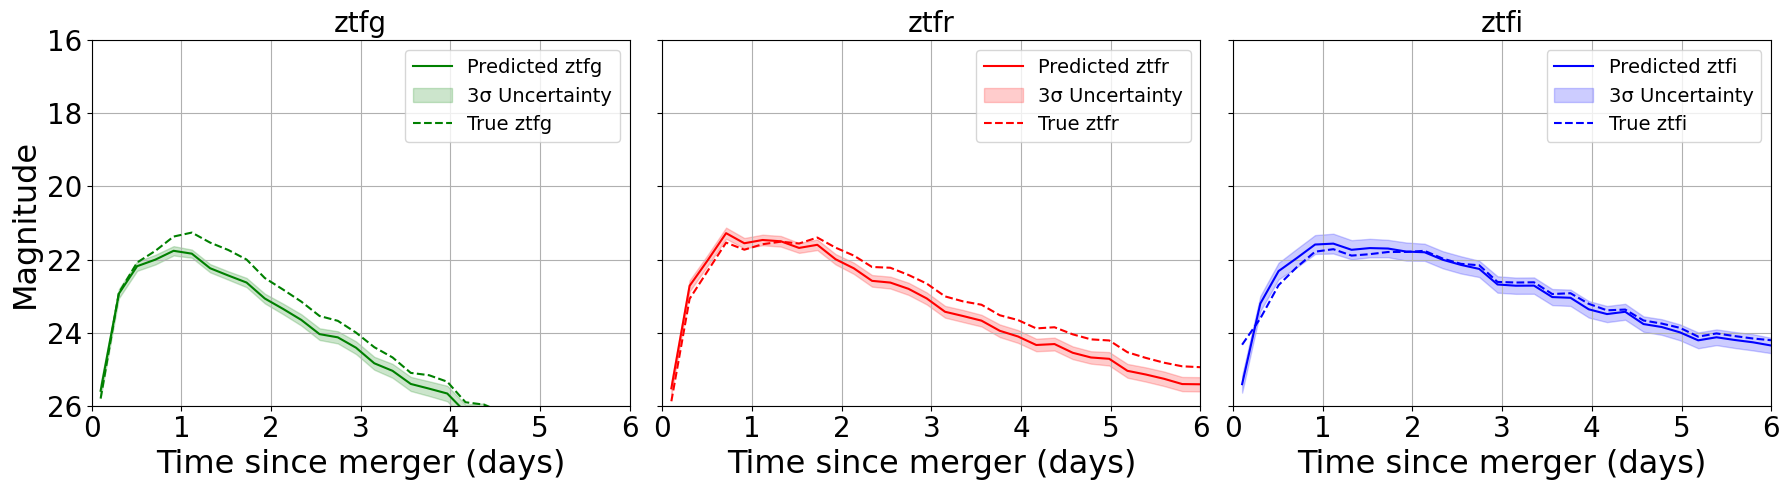

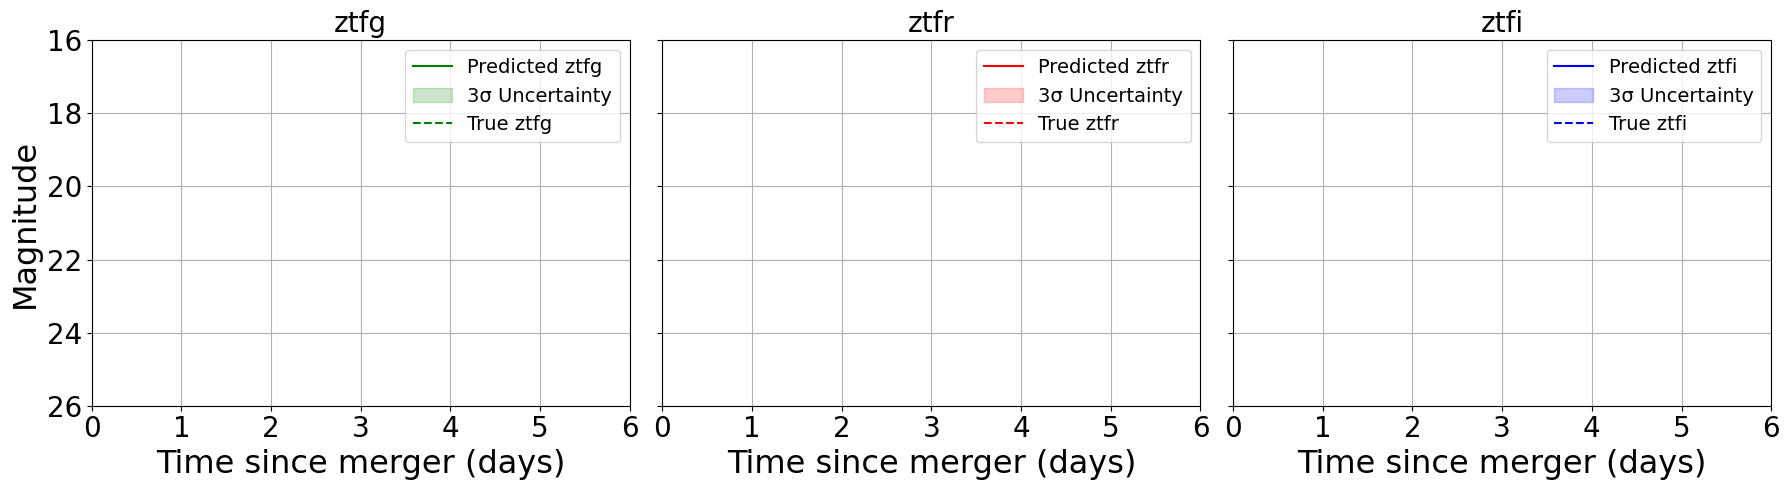

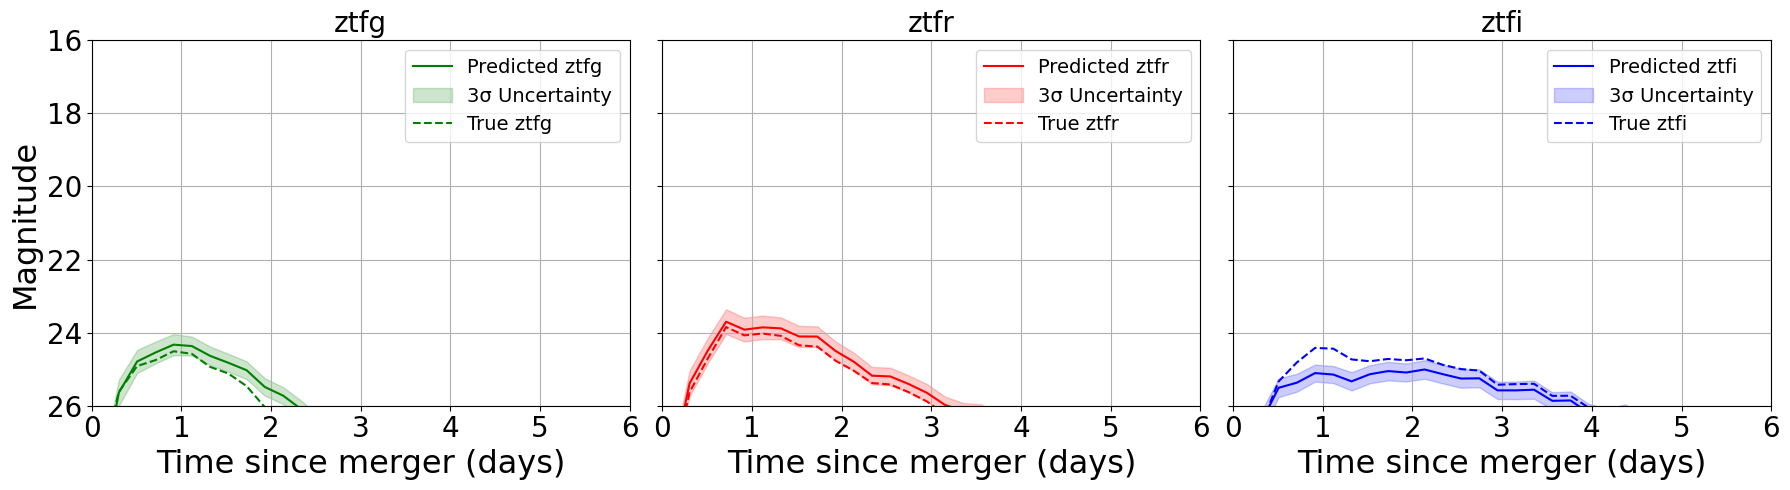

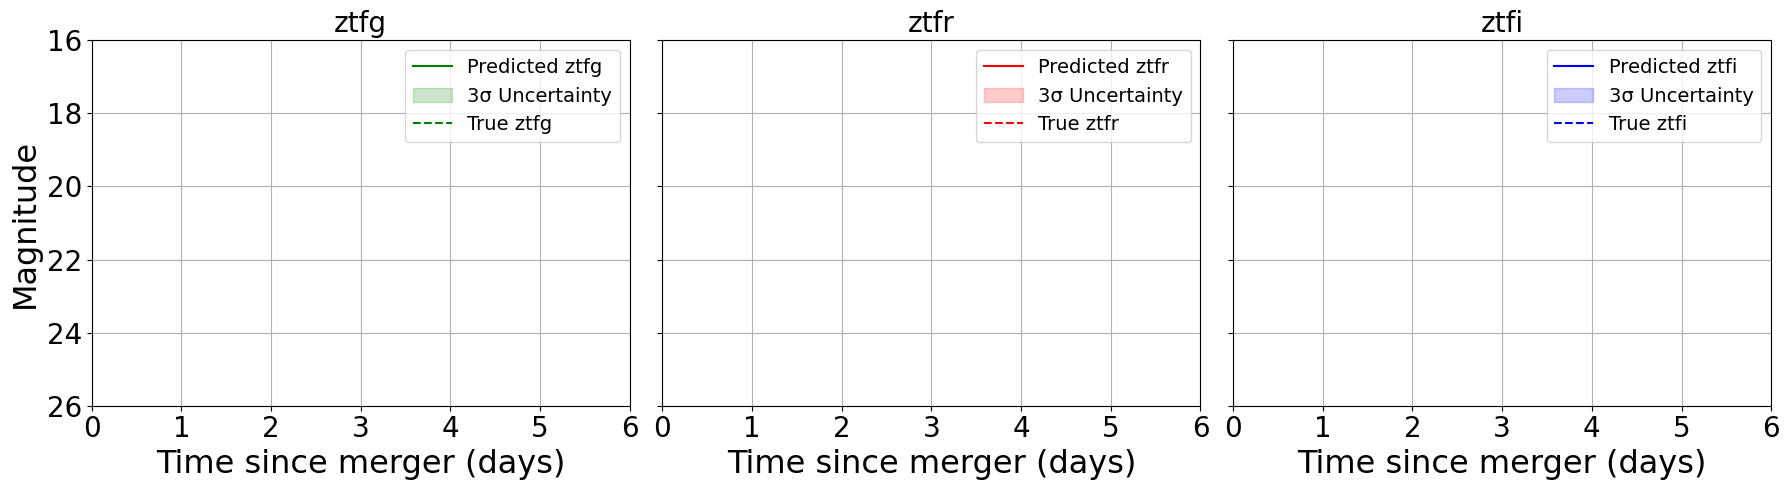

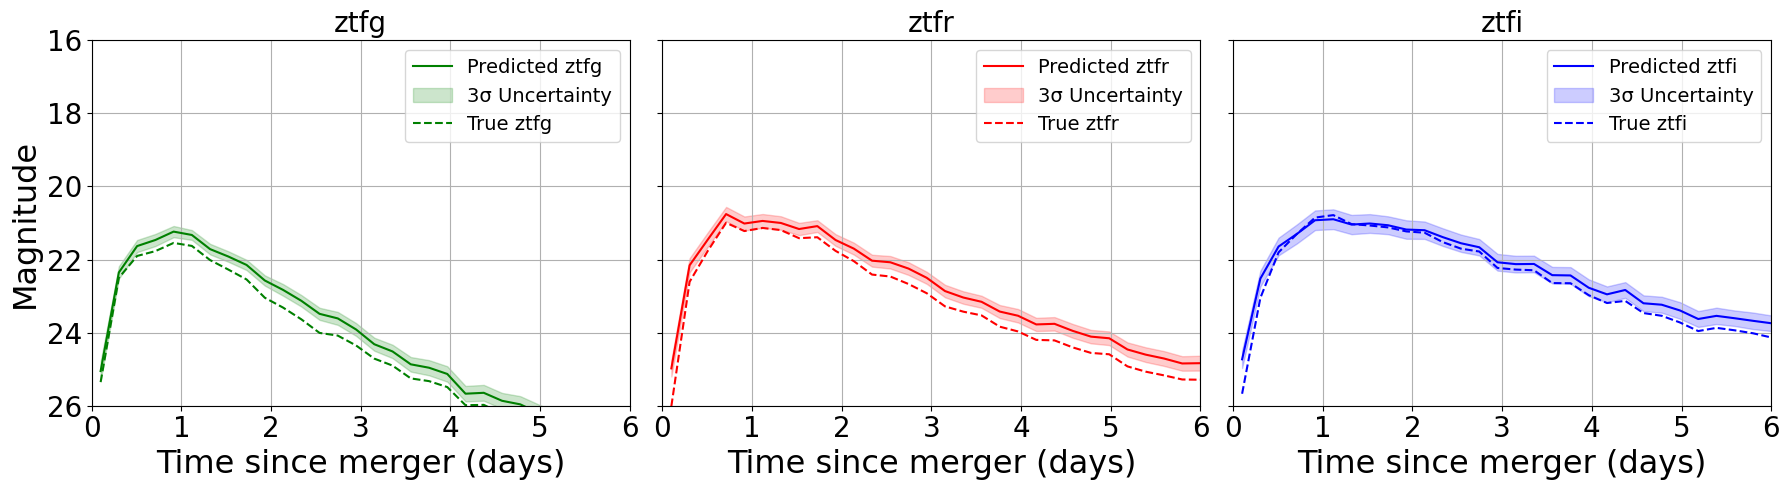

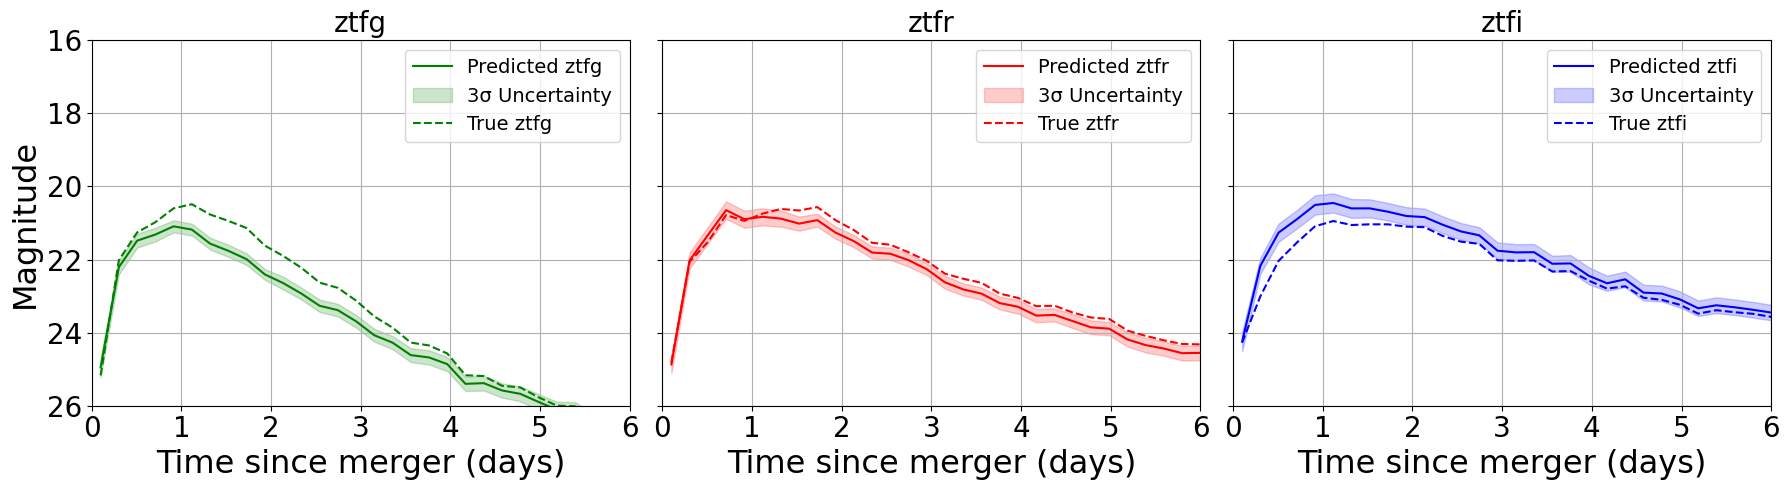

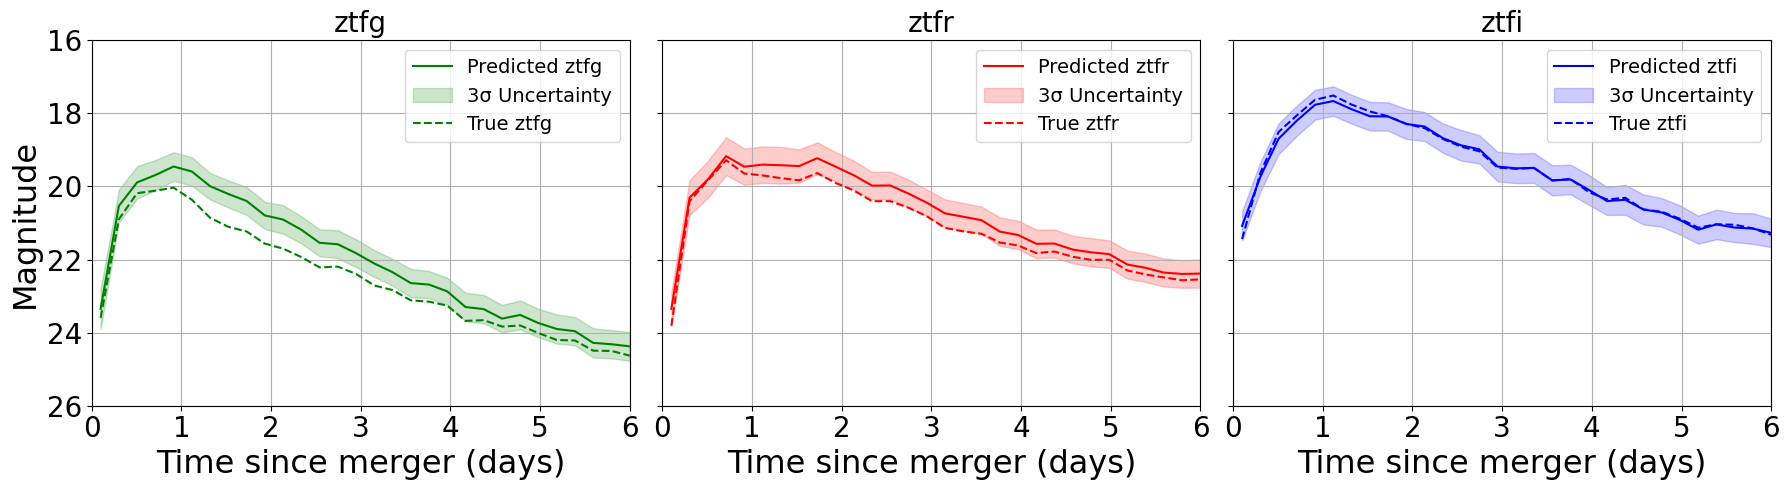

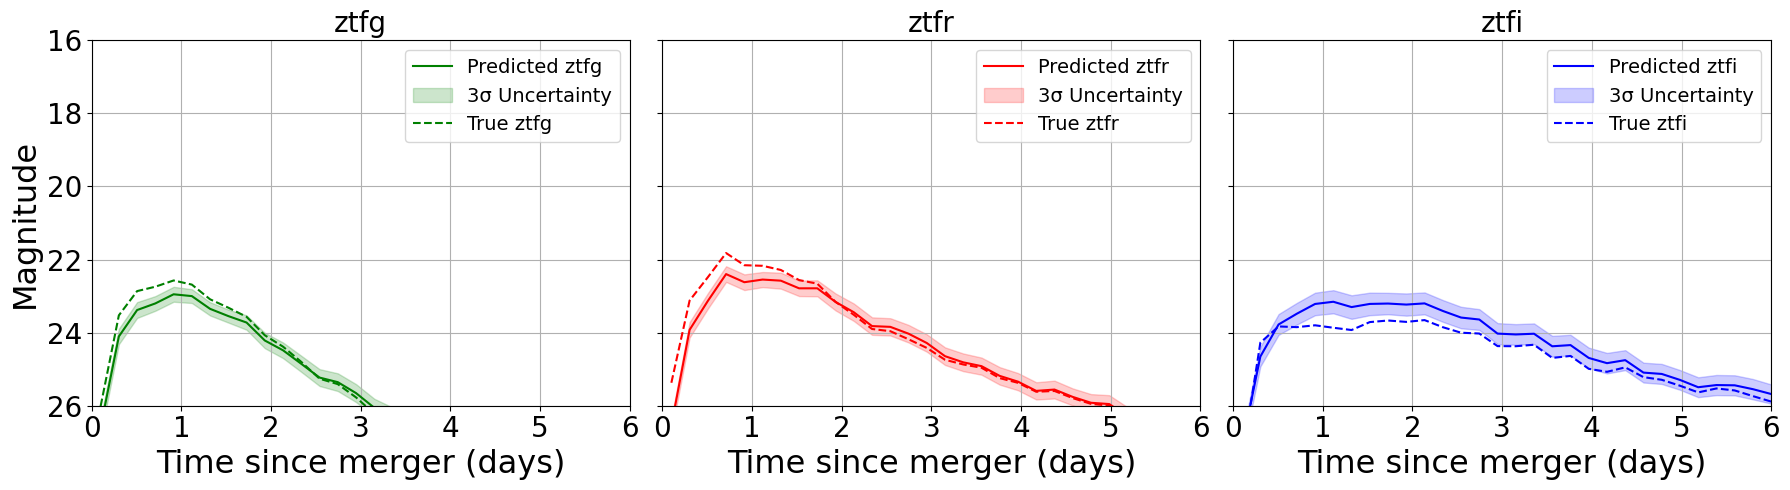

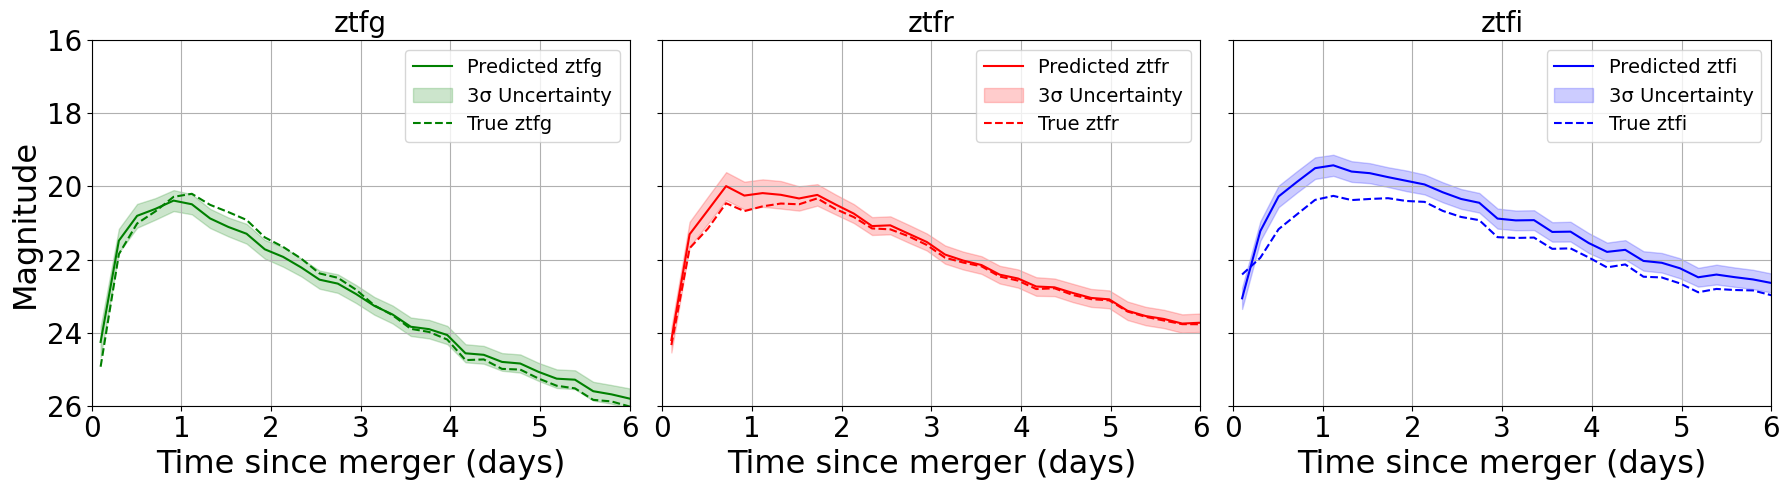

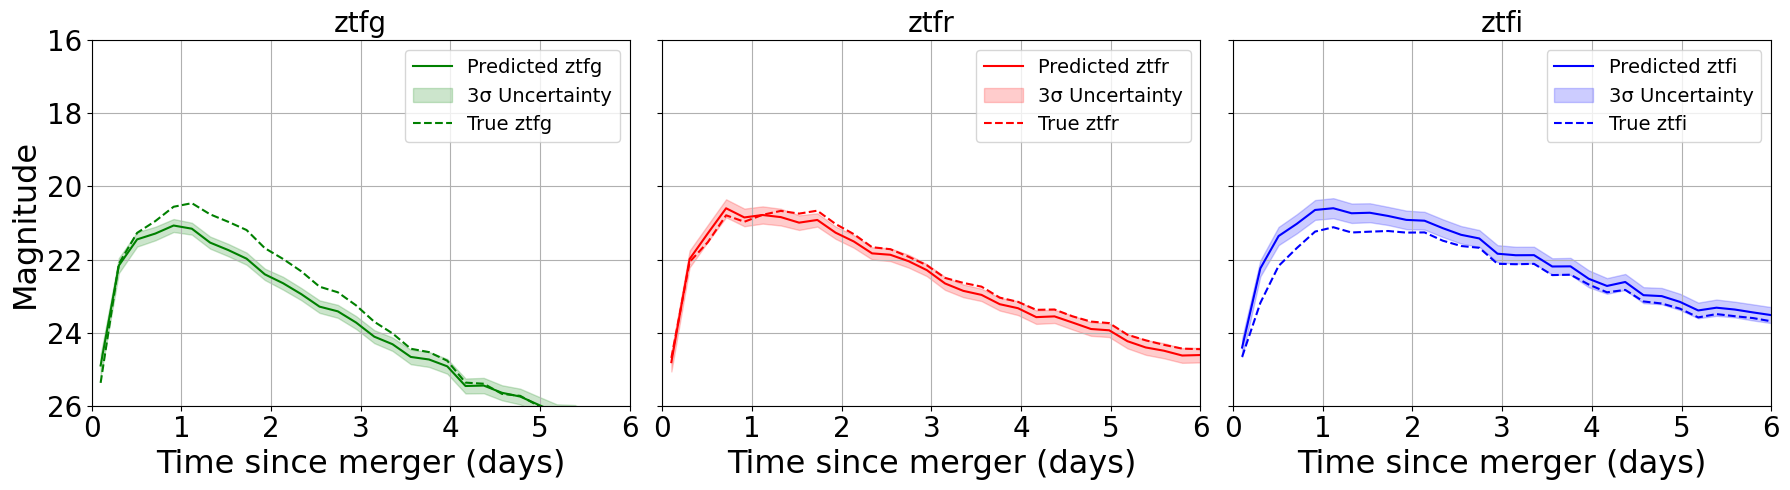

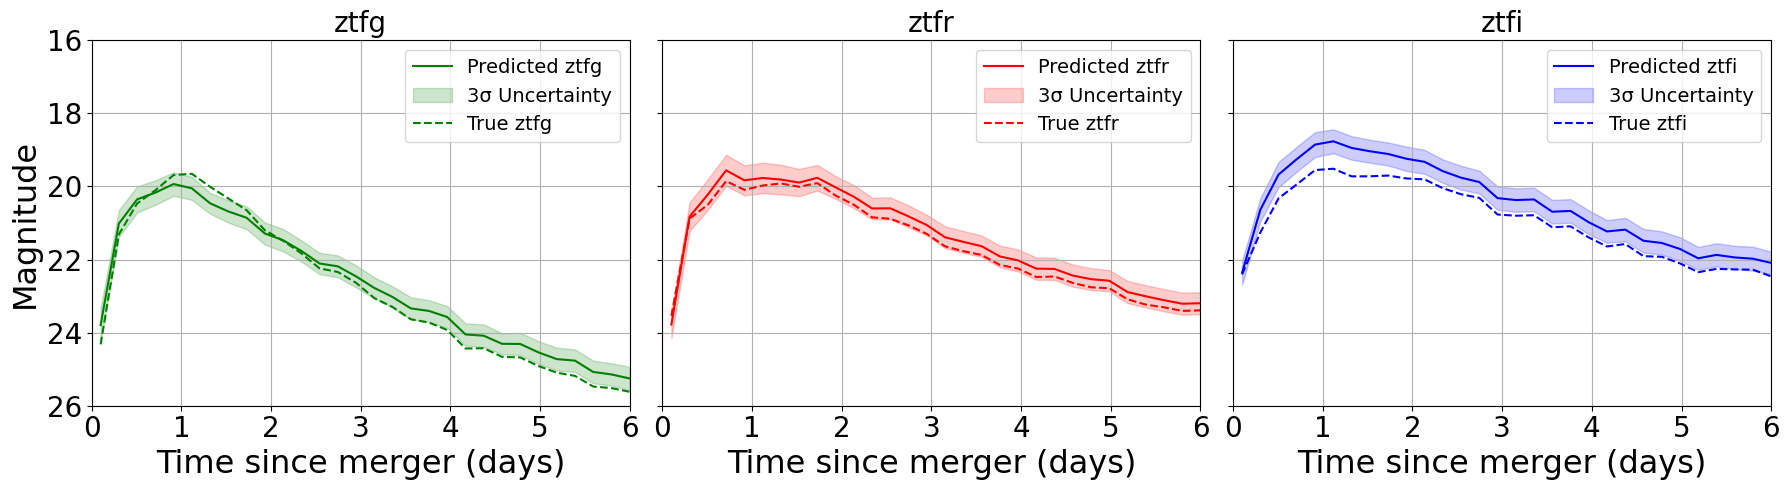

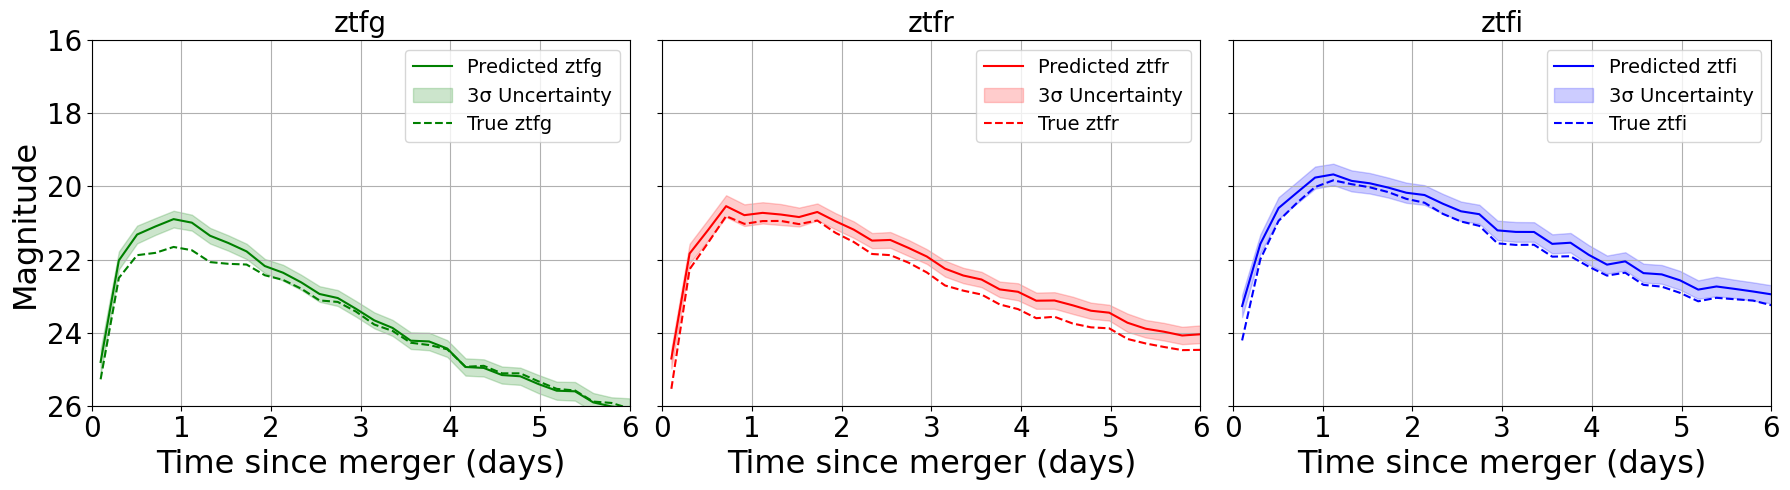

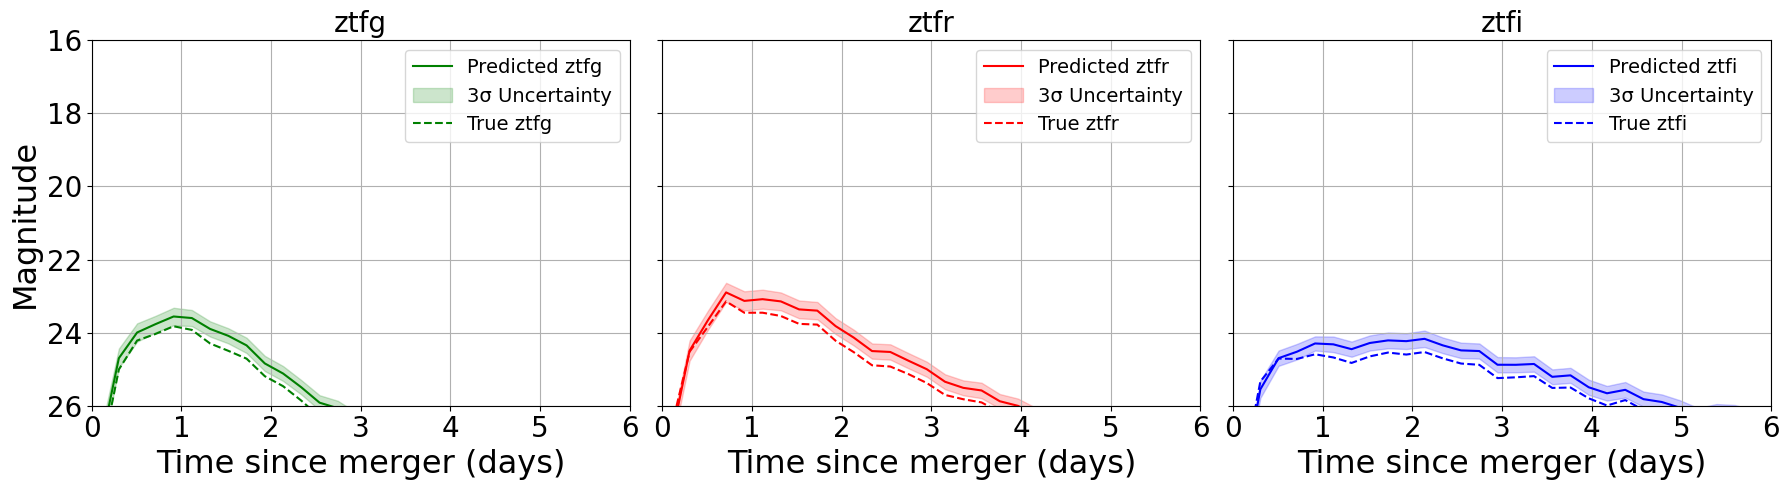

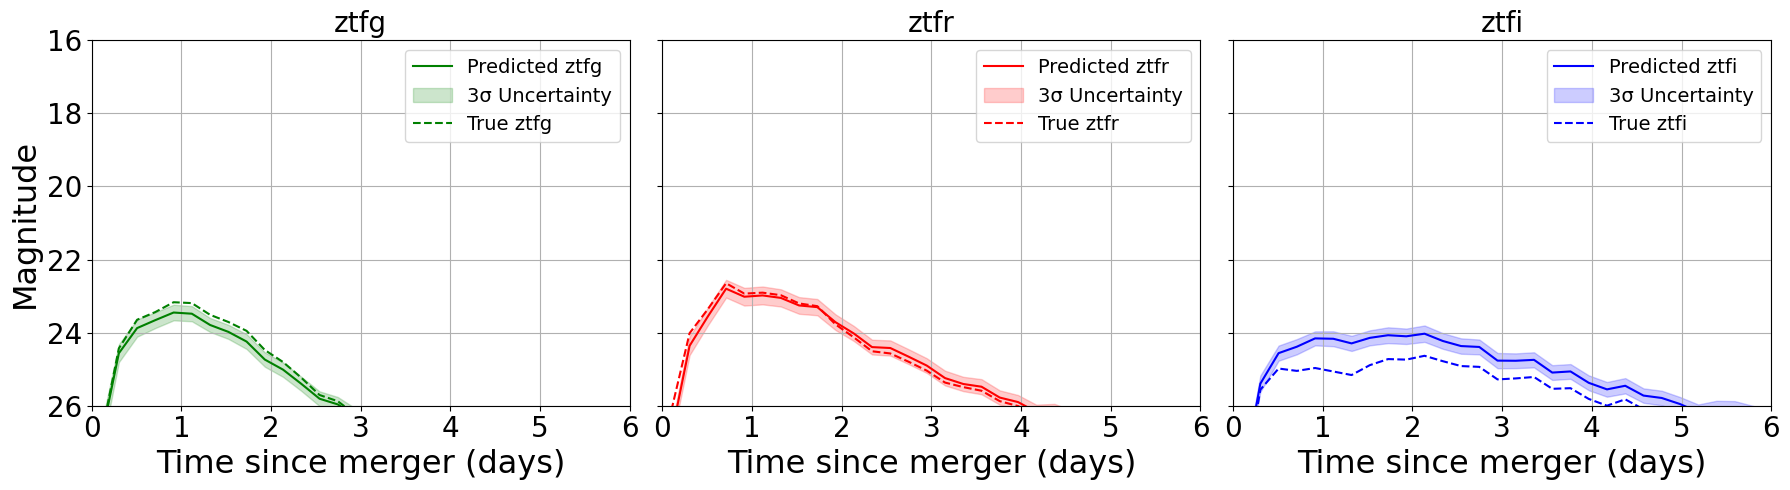

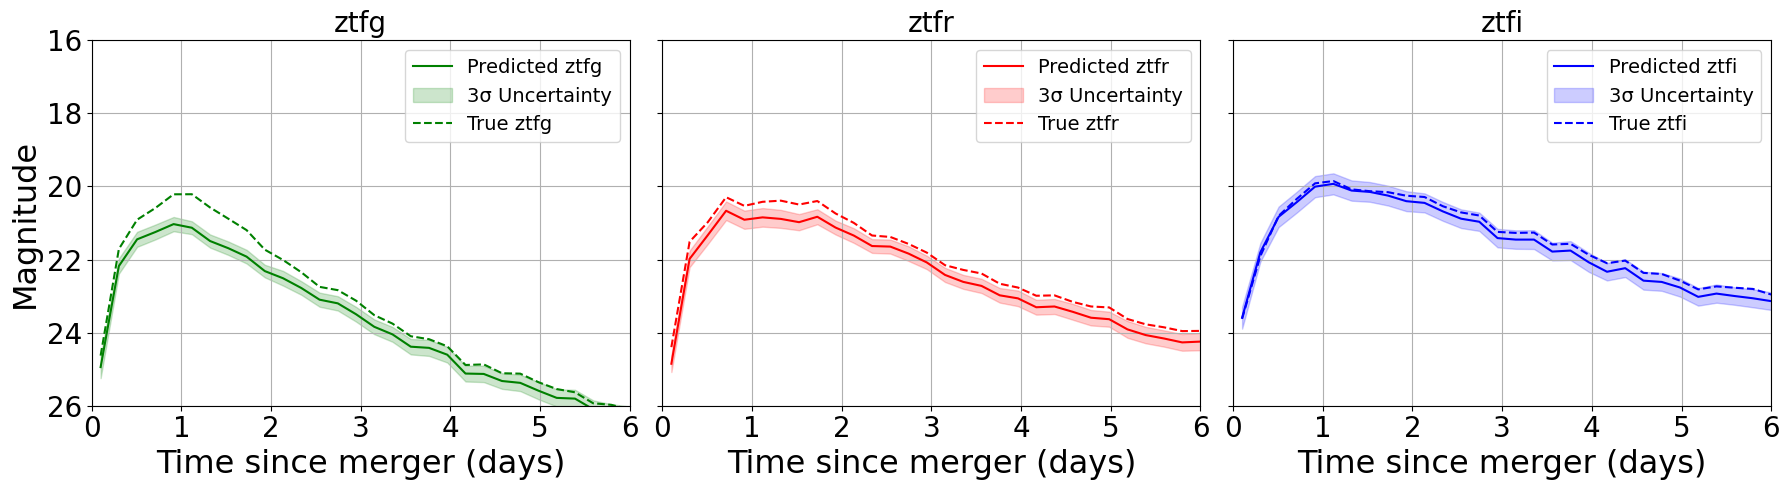

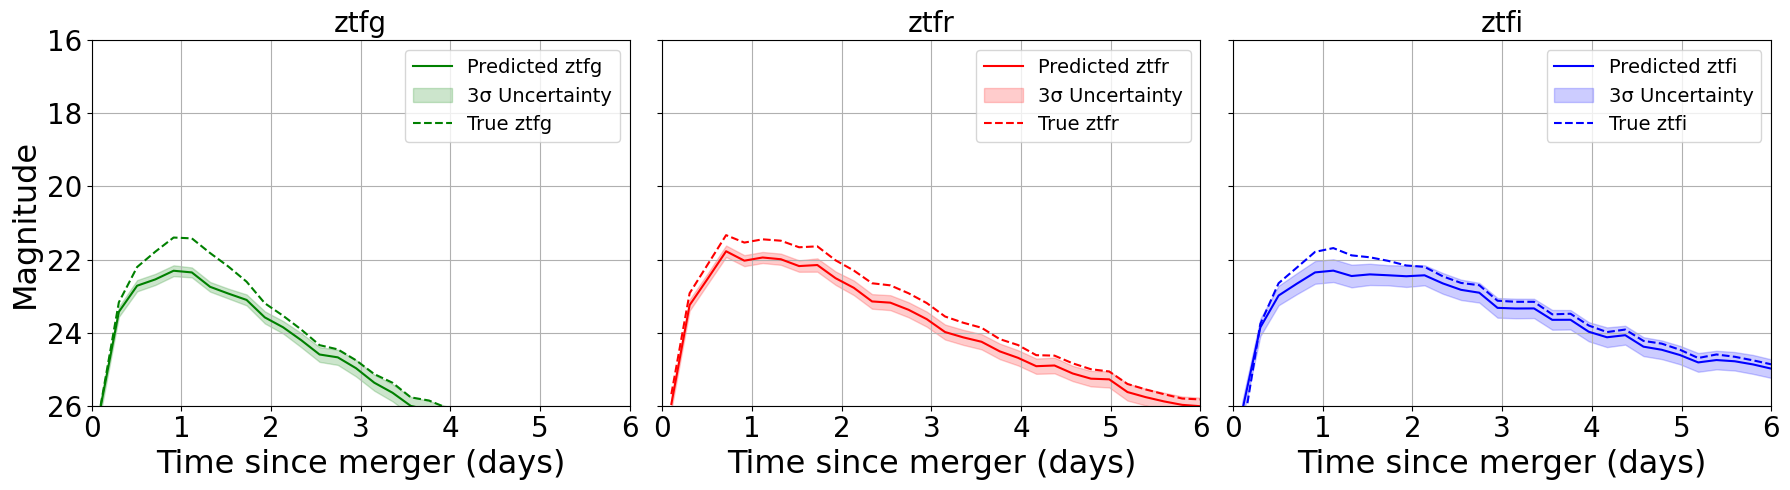

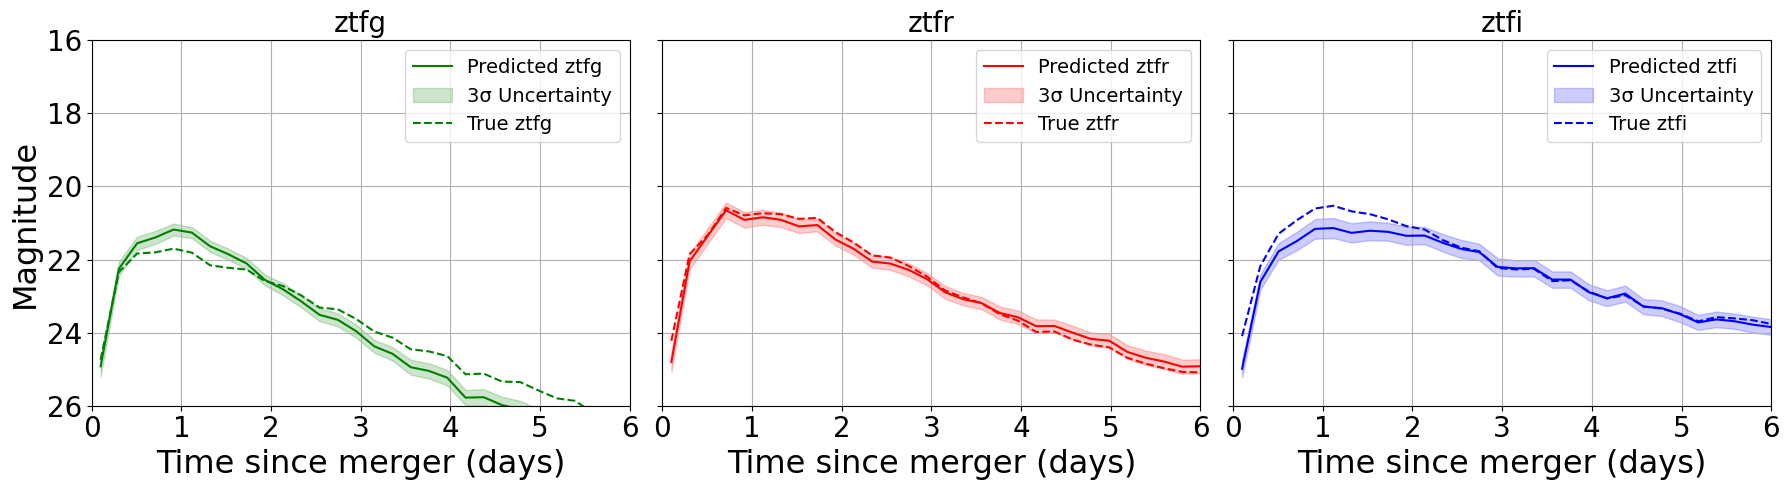

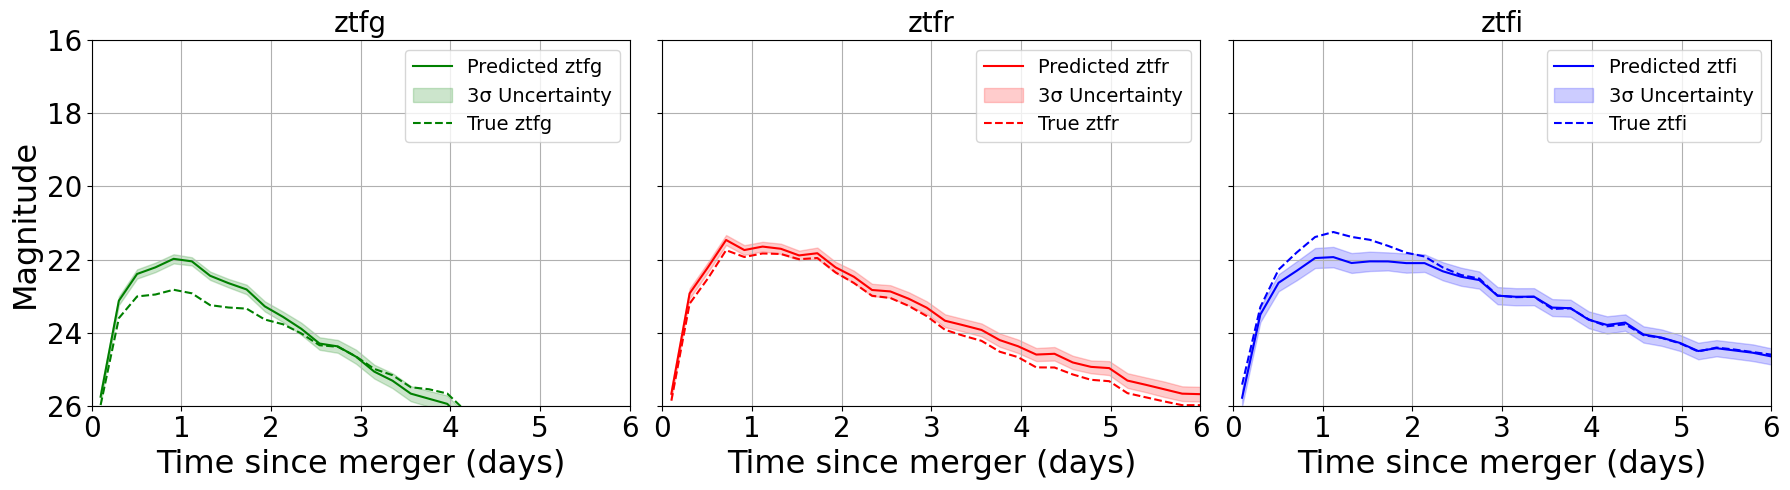

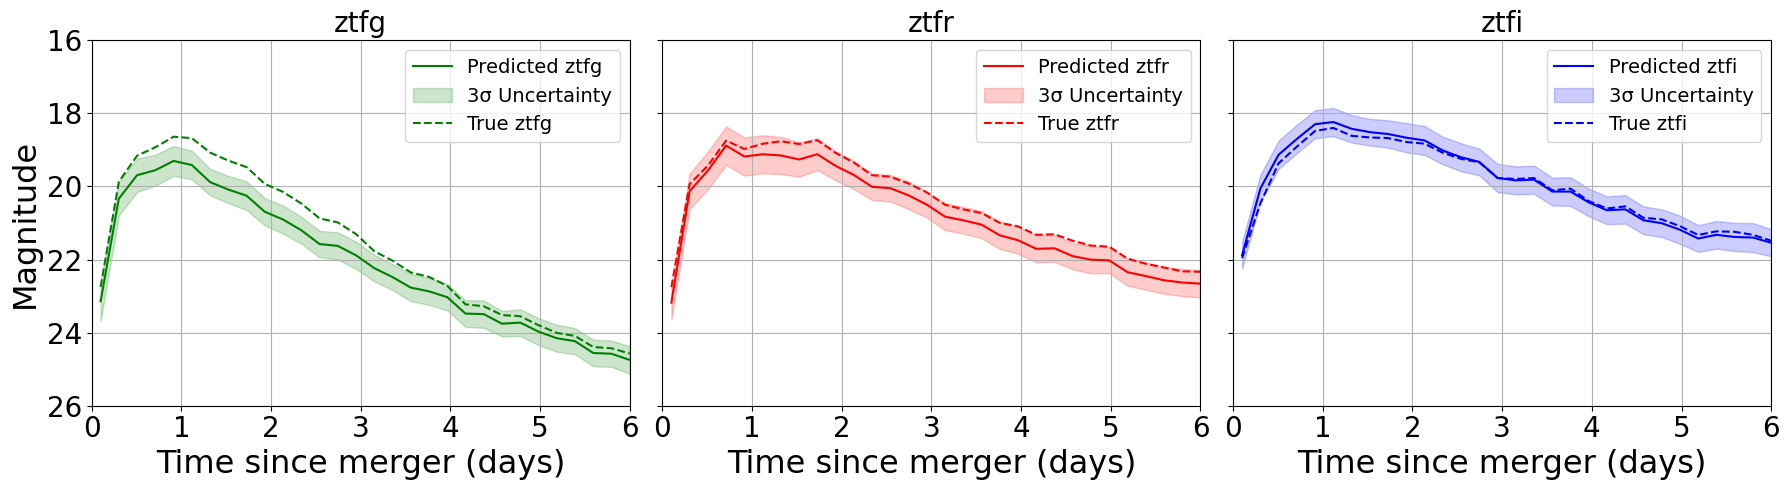

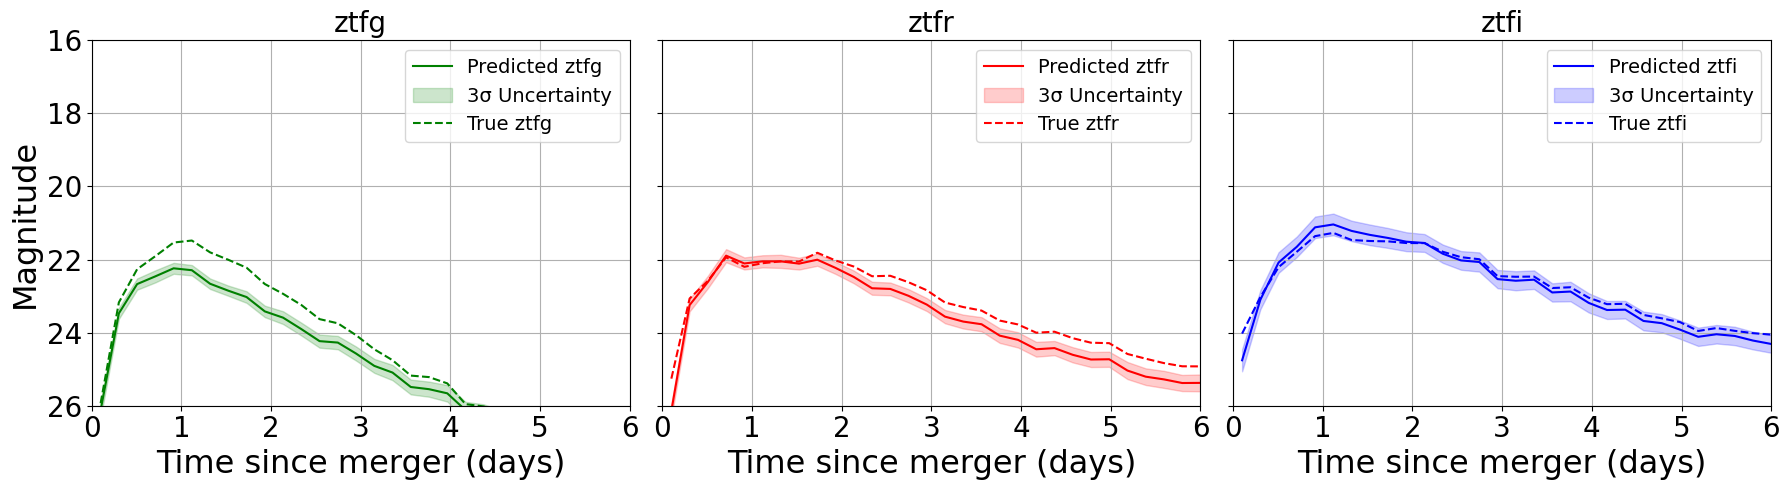

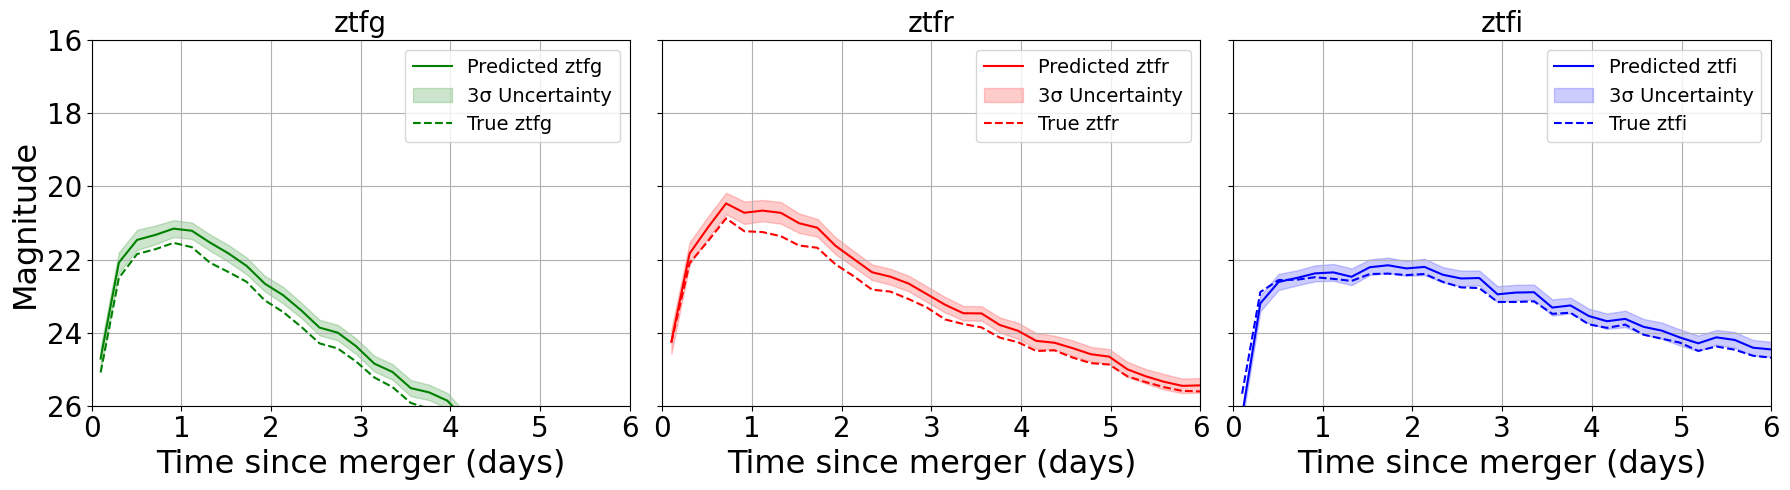

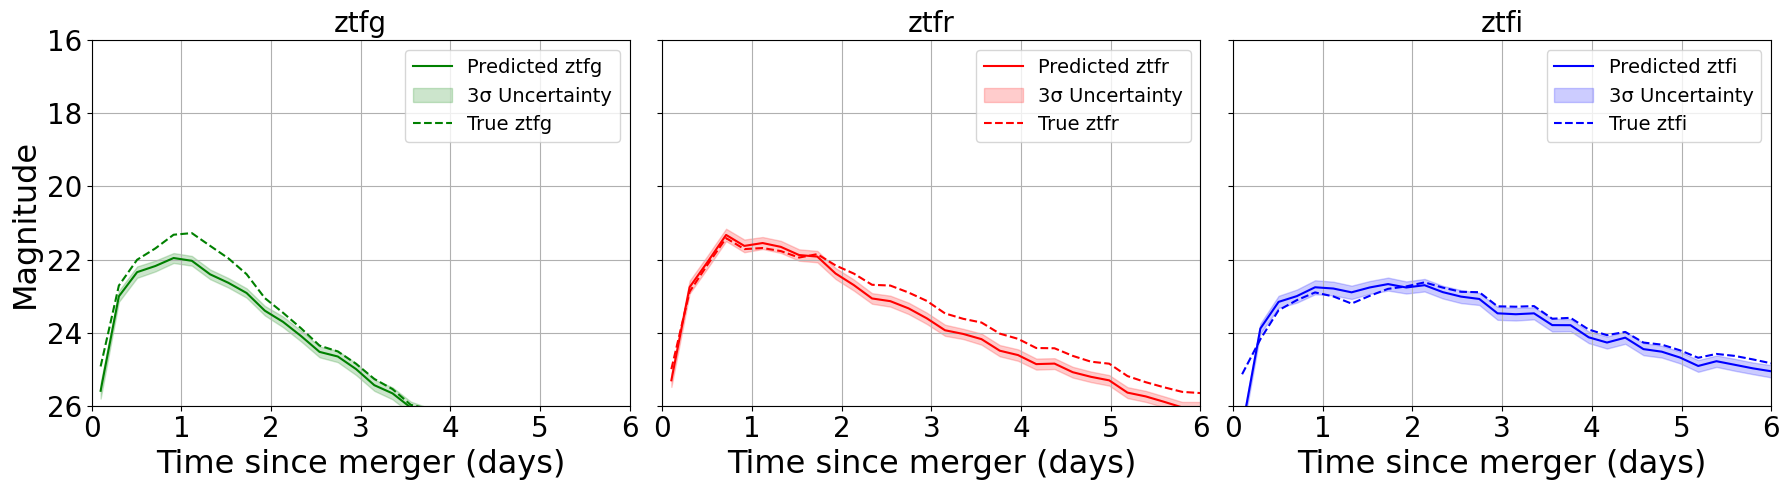

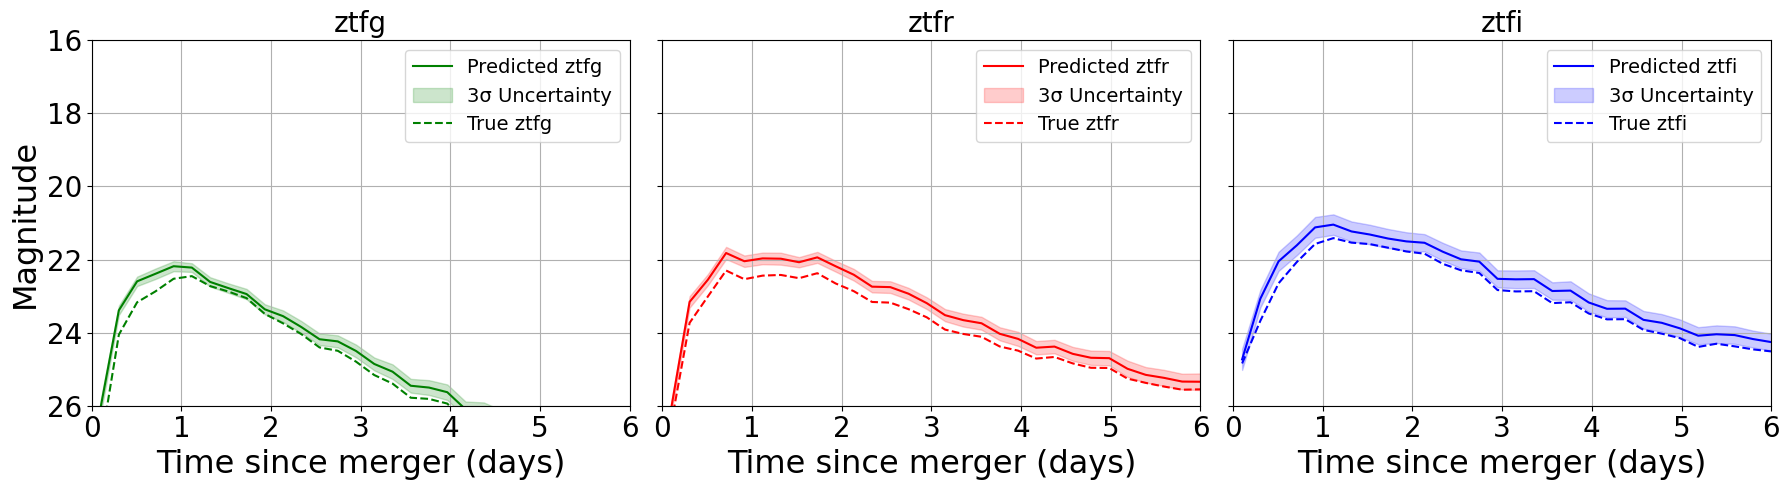

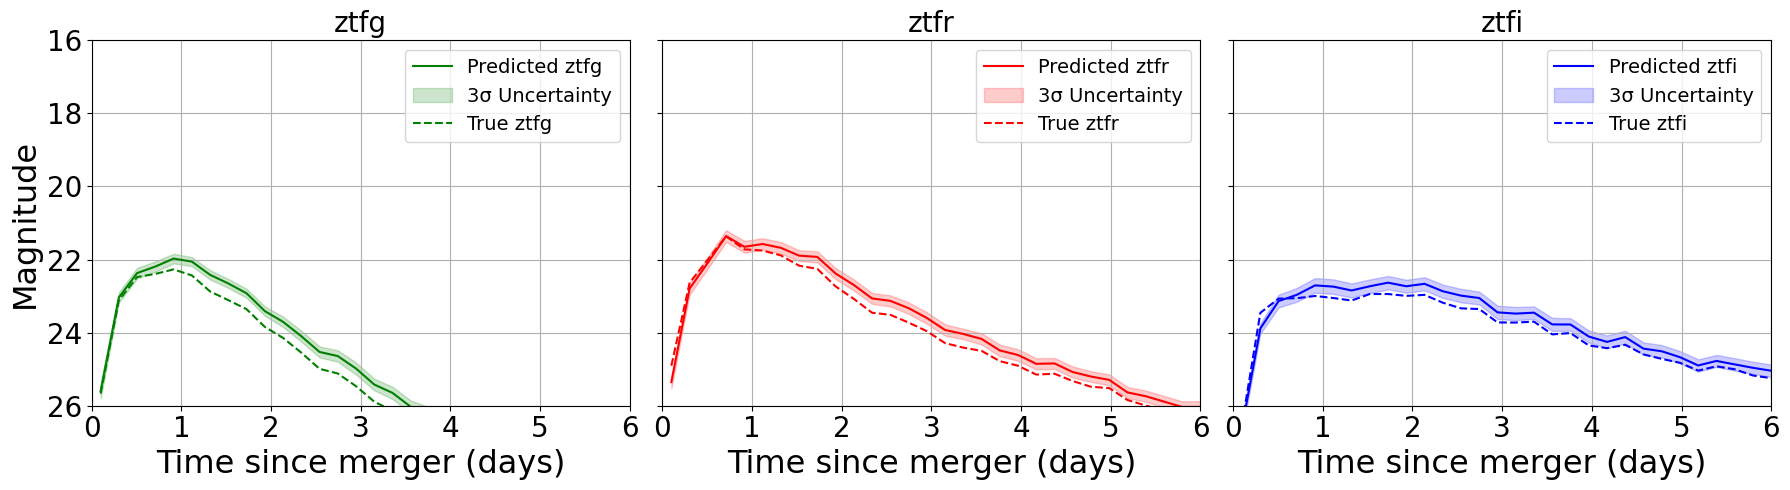

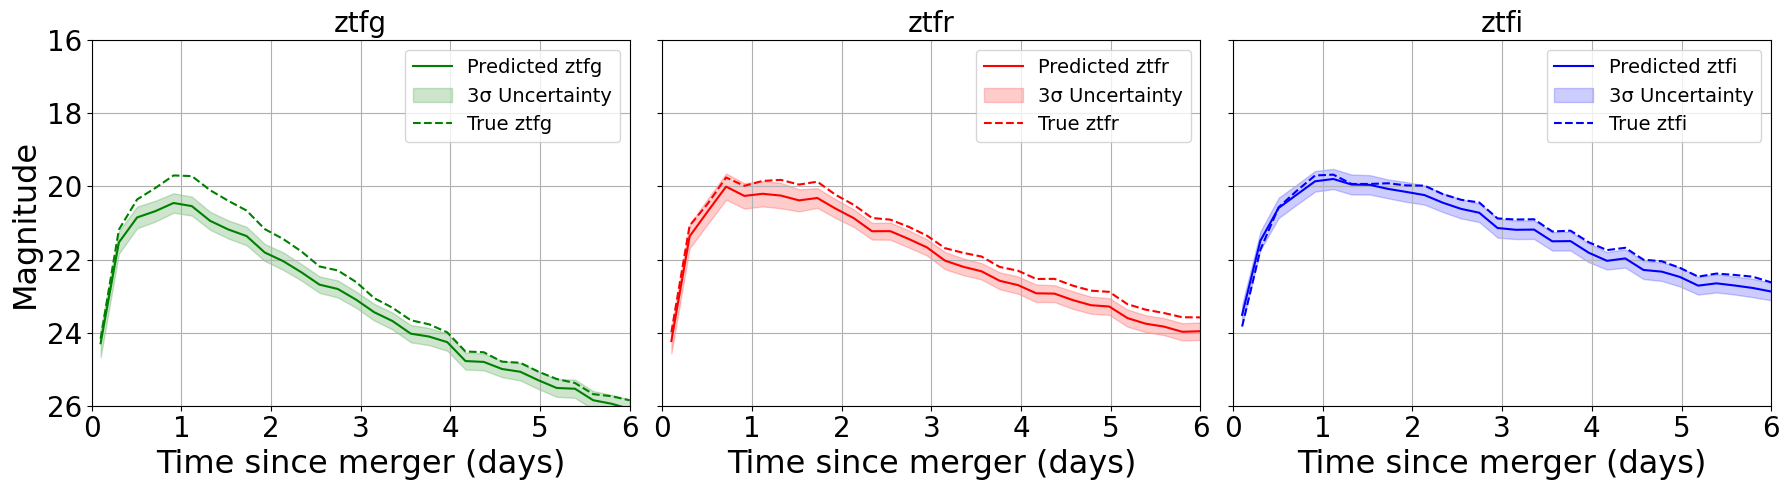

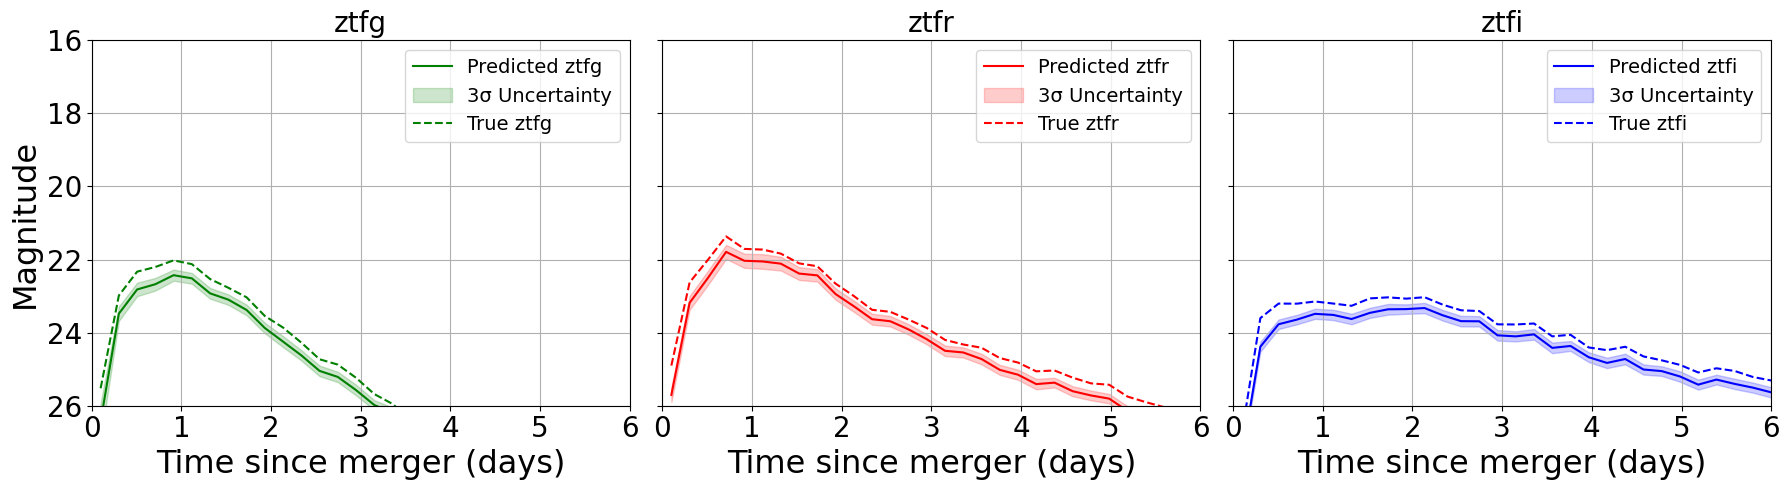

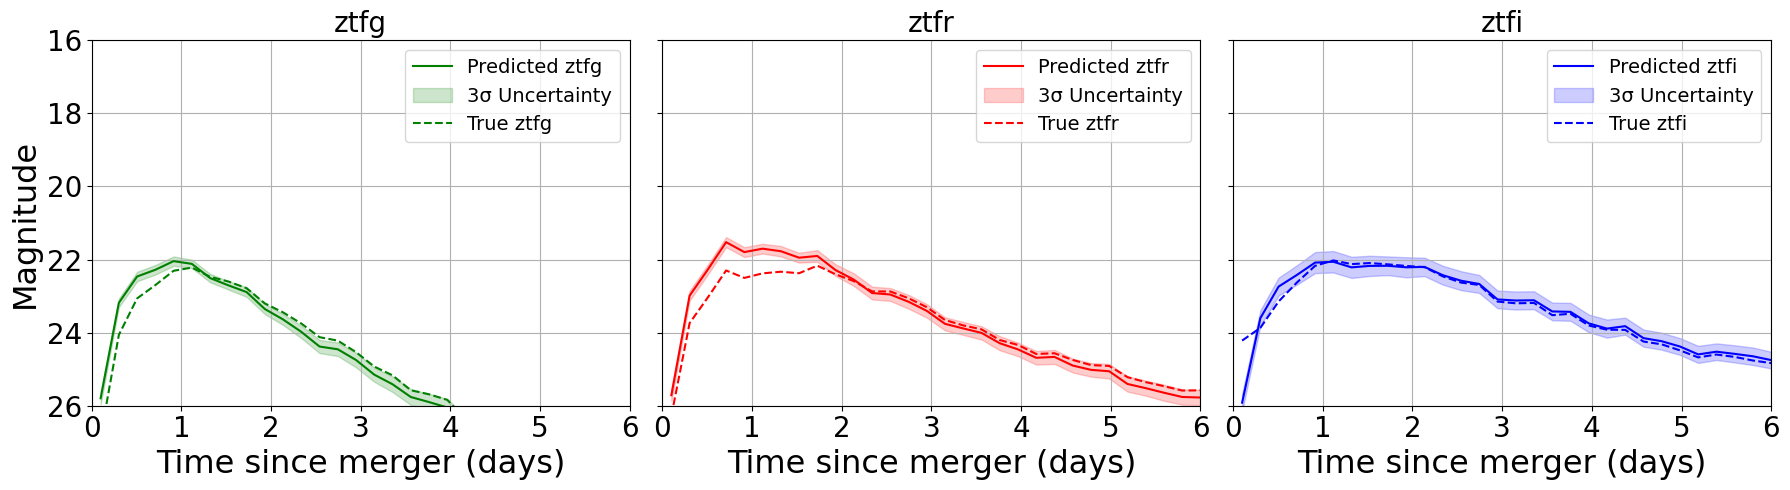

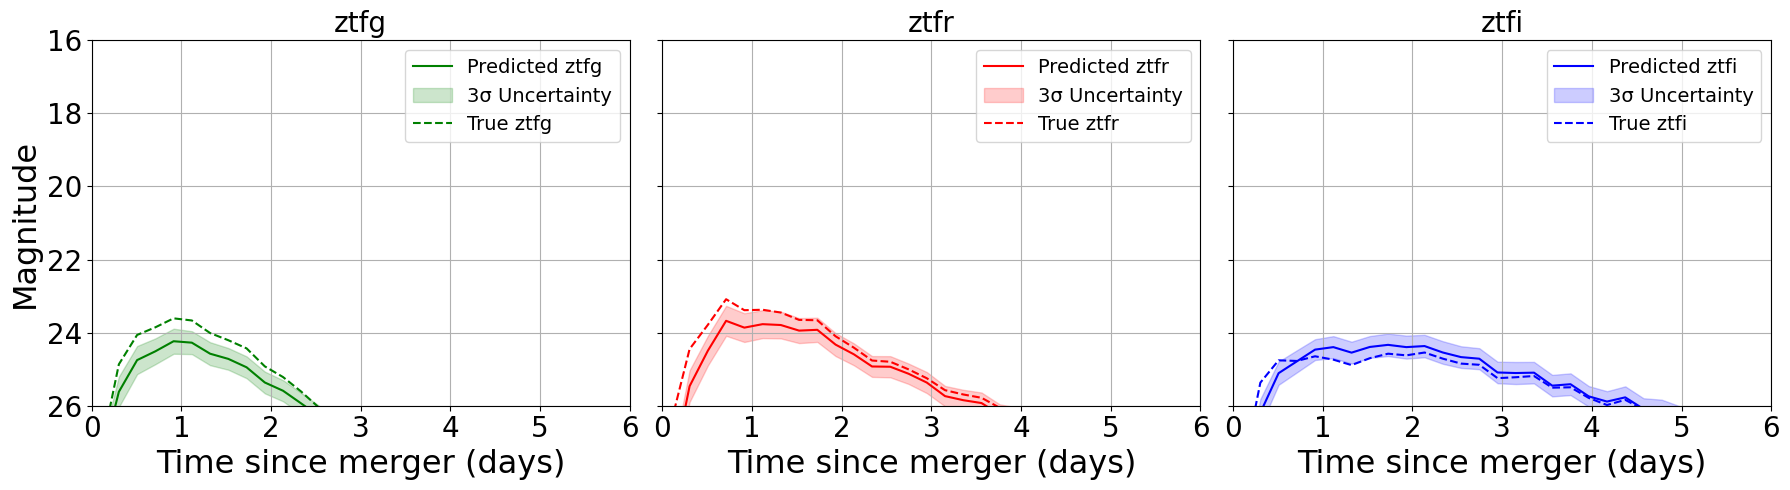

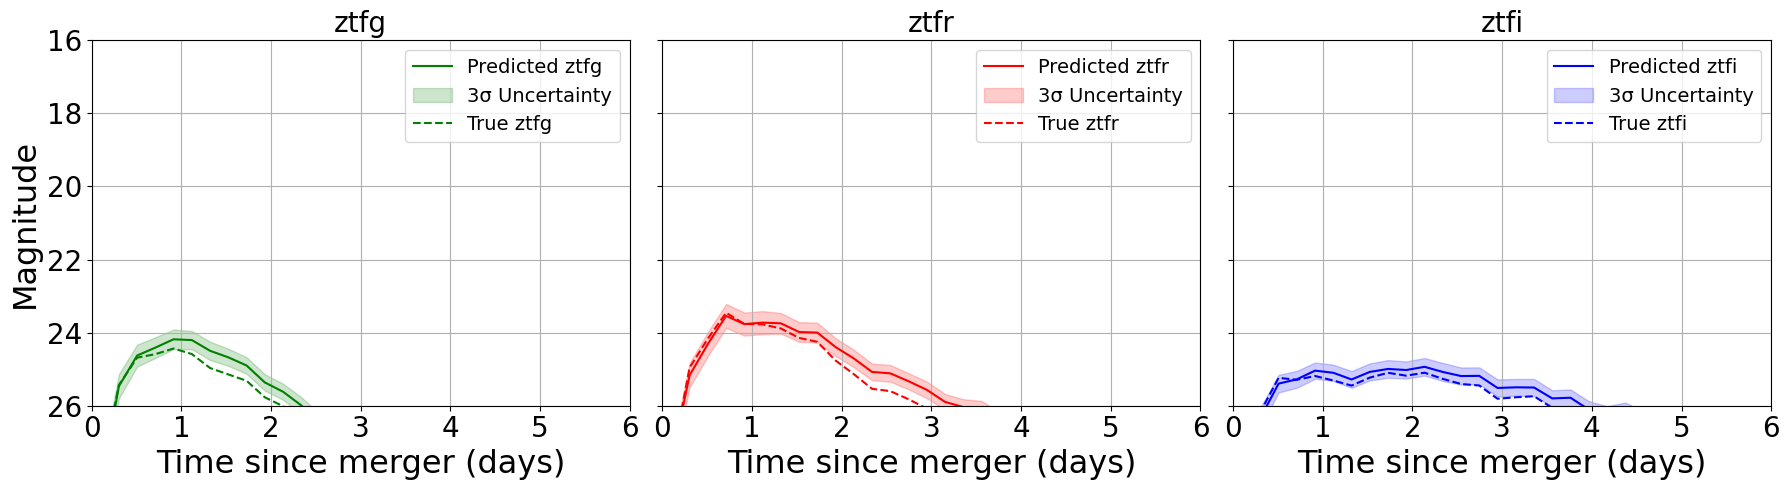

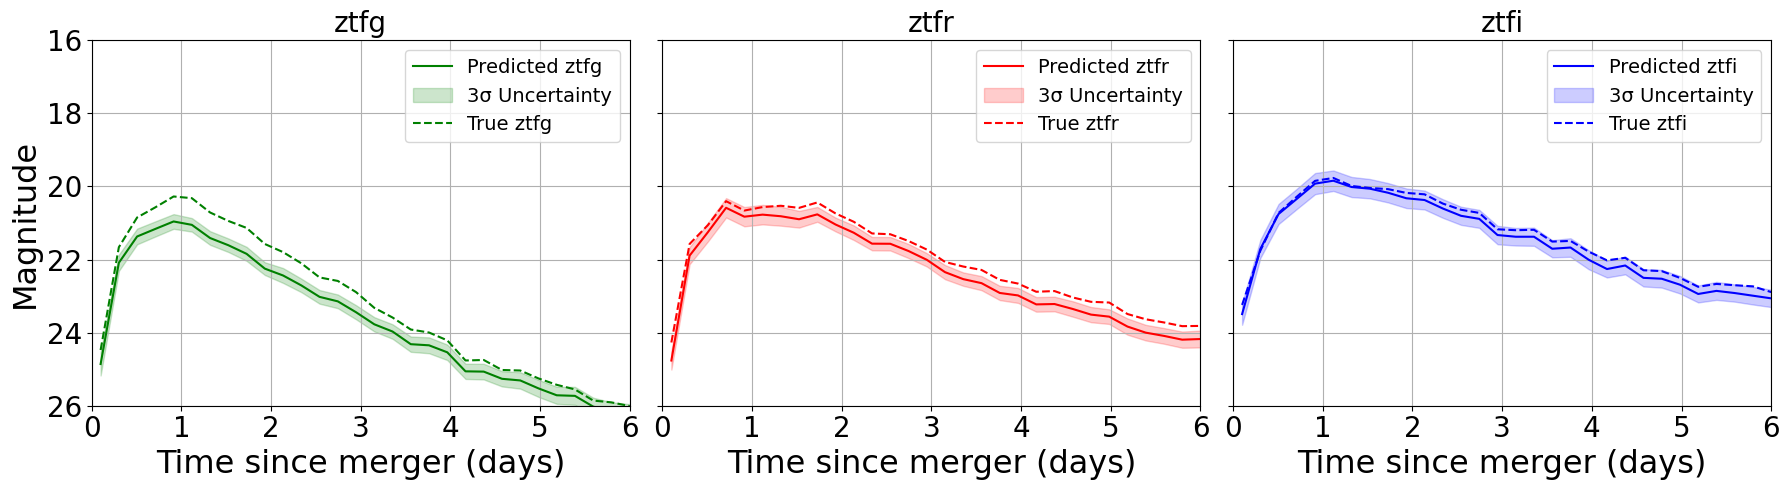

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Time points for plotting
t_min = 0.1
t_max = 6.0
dt = 0.2
time_single = np.linspace(t_min, t_max, num_time_points)
time_points = np.tile(time_single, (X_test_reshaped.shape[0], 1))

# Invert the scaling for y_test to compare with predictions
y_test_inverted = target_scaler.inverse_transform(y_test.reshape(y_test.shape[0], -1)).reshape((y_test.shape[0], num_time_points, 3))
mse_per_curve = np.mean((y_test_inverted - mean_preds_inverted) ** 2, axis=(1, 2))  # MSE for each light curve

# Set target MSE and tolerance
mse_target = 0.13
tolerance = 0.01
selected_indices = np.where(np.abs(mse_per_curve - mse_target) < tolerance)[0]

# Define filter info
filter_names = ['ztfg', 'ztfr', 'ztfi']
colors = {'ztfg': 'green', 'ztfr': 'red', 'ztfi': 'blue'}

if len(selected_indices) > 0:
    print(f"Plotting all light curves with MSE around {mse_target} ± {tolerance}:")
    
    for example_idx in selected_indices:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # 1 row, 3 columns
        
        mean_curve = mean_preds_inverted[example_idx]
        true_curve = y_test_inverted[example_idx]

        for i, filter_name in enumerate(filter_names):
            ax = axs[i]
            ax.plot(time_single, mean_curve[:, i], label=f'Predicted {filter_name}', color=colors[filter_name])
            ax.fill_between(time_single,
                            mean_curve[:, i] - 3 * uncertainty_reshaped[example_idx, :, i],
                            mean_curve[:, i] + 3 * uncertainty_reshaped[example_idx, :, i],
                            color=colors[filter_name], alpha=0.2, label='3σ Uncertainty')
            ax.plot(time_single, true_curve[:, i], '--', color=colors[filter_name], label=f'True {filter_name}')

            ax.set_title(f'{filter_name}', fontsize=20)
            ax.set_xlabel('Time since merger (days)', fontsize=23)
            ax.set_xlim(0, 6)
            ax.set_ylim(26, 16)
            ax.grid(True)
            ax.tick_params(axis='both', labelsize=20)
            ax.legend(fontsize=14)

        axs[0].set_ylabel('Magnitude', fontsize=23)
        plt.tight_layout()
        plt.show()

else:
    print(f"No light curves found with MSE close to {mse_target}.")

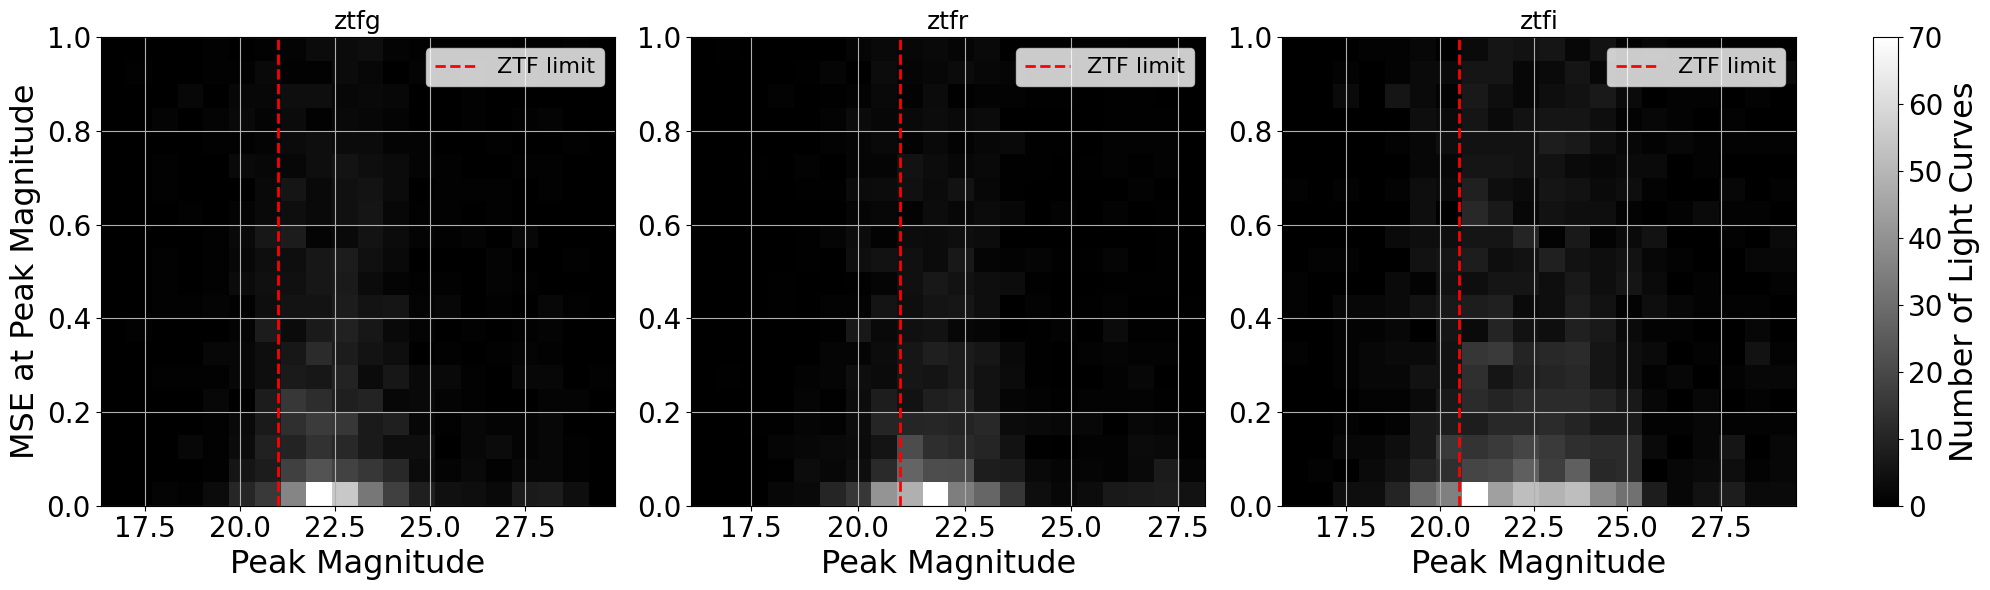

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

filter_names = ['ztfg', 'ztfr', 'ztfi']
ztf_limits = {'ztfg': 21, 'ztfr': 21, 'ztfi': 20.5}

# Setup figure with 3 subplots and a separate colorbar axis
fig = plt.figure(figsize=(20, 6))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05])
axs = [fig.add_subplot(gs[i]) for i in range(3)]
cax = fig.add_subplot(gs[3])  # colorbar axis

for i, filter_name in enumerate(filter_names):
    ax = axs[i]

    # Step 1: Find the index of peak magnitude for each light curve
    peak_indices = np.argmin(y_test_inverted[:, :, i], axis=1)

    # Step 2: Extract true and predicted values at the peak
    peak_preds_filter = mean_preds_inverted[np.arange(mean_preds_inverted.shape[0]), peak_indices, i]
    peak_true_filter = y_test_inverted[np.arange(y_test_inverted.shape[0]), peak_indices, i]

    # Step 3: Compute MSE at the peak
    mse_at_peak_filter = (peak_true_filter - peak_preds_filter) ** 2

    # Step 4: Filter out extreme outliers
    mse_threshold = 5.0
    mask = mse_at_peak_filter < mse_threshold

    # Step 5: Plot 2D histogram
    h = ax.hist2d(
        peak_true_filter[mask],
        mse_at_peak_filter[mask],
        bins=20,
        range=[[np.min(peak_true_filter[mask]), np.max(peak_true_filter[mask])], [0, 1]],
        cmap='gray'
    )

    ax.axvline(x=ztf_limits[filter_name], color='red', linestyle='--', linewidth=2, label='ZTF limit')
    ax.set_title(f'{filter_name}', fontsize=18)
    ax.set_xlabel('Peak Magnitude', fontsize=23)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=16)

axs[0].set_ylabel('MSE at Peak Magnitude', fontsize=23)

# Add shared colorbar in separate axis
cbar = fig.colorbar(h[-1], cax=cax)
cbar.ax.tick_params(labelsize=20)
cbar.set_label('Number of Light Curves', fontsize=23)

plt.tight_layout()
plt.show()

(2424, 30, 3)
(2424, 30, 3)


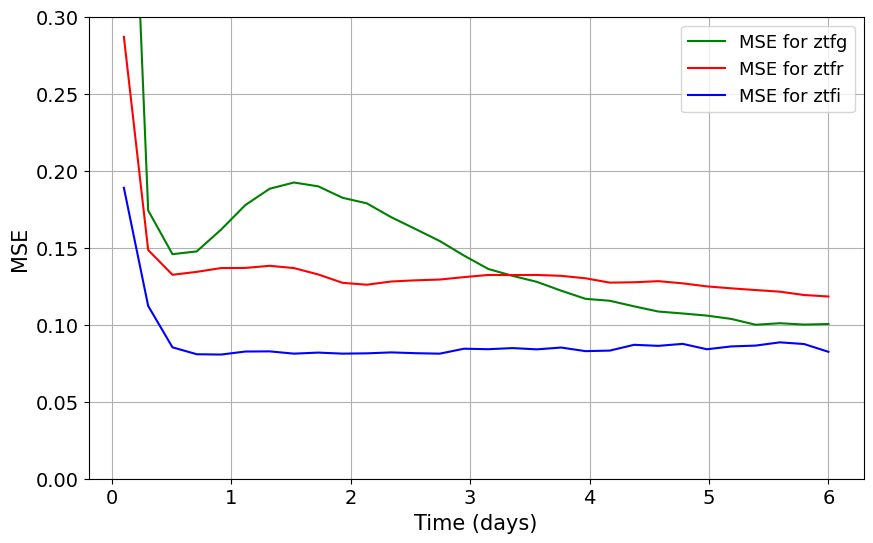

{'ztfg': 0.15393085105013257,
 'ztfr': 0.13509146531616534,
 'ztfi': 0.08826487686978295}

In [16]:
# Loop over each filter and compute MSE at each time step
mse_vs_time = {}
filter_names = ['ztfg', 'ztfr', 'ztfi']
colors = {'ztfg': 'green', 'ztfr': 'red', 'ztfi': 'blue'}
y_test_reshaped = y_test.reshape(y_test.shape[0], num_time_points, 3) 
print(y_test_reshaped.shape)
mean_preds_reshaped = mean_preds.reshape(mean_preds.shape[0], num_time_points, 3) 
print(mean_preds_reshaped.shape)
for i, filter_name in enumerate(filter_names):
    # Calculate MSE at each time step (averaged across all light curves)
    mse_per_time_step = np.mean((y_test_reshaped[:,:,i] - mean_preds_reshaped[:,:,i]) ** 2, axis=0)  
    
    mse_vs_time[filter_name] = mse_per_time_step

plt.figure(figsize=(10, 6))

for filter_name in filter_names:
    plt.plot(time_single, mse_vs_time[filter_name], label=f'MSE for {filter_name}', color=colors[filter_name])

# Add labels and title
plt.xlabel('Time (days)', fontsize = 15)
plt.ylabel('MSE', fontsize = 15)
#plt.title('MSE vs Time Step for Each Filter')
plt.legend(fontsize=13)
plt.grid(True)
#plt.gca().invert_yaxis() 
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.ylim(0, 0.3) 
plt.tick_params(axis='both', labelsize=14)
plt.show()
average_mse_per_filter = {filter_name: np.mean(mse_vs_time[filter_name]) for filter_name in filter_names}

average_mse_per_filter

In [ ]:
# ============================================================
# PRODUCTION LSTM MODEL (Full Dataset, using chirp_mass_bin_edges)
# ============================================================

import os
import datetime
import pickle
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.preprocessing import RobustScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard

# ============================================================
# 1. Load processed data
# ============================================================
lightCurve = pd.read_csv(
    "/Users/np699/Library/CloudStorage/OneDrive-DrexelUniversity/Untitled Folder/Forecaster/lightcurveDataCom7988.csv"
)
features = pd.read_csv(
    "/Users/np699/Library/CloudStorage/OneDrive-DrexelUniversity/Untitled Folder/Forecaster/featureDataCom7988_pAstro_with_distmean_std_ej.csv"
)
print("LightCurve shape:", lightCurve.shape)
print("Features shape before cleaning:", features.shape)

# Drop unnecessary columns
features = features.drop(
    ["simulation_id", "far", "snr", "longitude", "latitude", "distance", "chirp_mass", "mej"],
    axis=1,
    errors="ignore",
)

# Drop bad simulations
ids_to_drop = [1624, 43162, 97688]
lightCurve = lightCurve[~lightCurve["simulation_id"].isin(ids_to_drop)]

# Parse chirp_mass_bin_edges
import ast
if "chirp_mass_bin_edges" in features.columns:
    features["chirp_mass_bin_edges"] = features["chirp_mass_bin_edges"].apply(
        lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x)
    )

# Split scalar vs chirp bins
drop_cols = ["chirp_mass_bin_edges"]
columns_to_scale = [c for c in features.columns if c not in drop_cols]
scalar_features = features[columns_to_scale].copy()
chirp_edges = np.stack(features["chirp_mass_bin_edges"].values)
print(f"✅ Chirp-mass bin edges shape: {chirp_edges.shape}")
print("Scalar features:", scalar_features.columns.tolist())

# Handle NaNs
scalar_features = scalar_features.apply(pd.to_numeric, errors="coerce")
if scalar_features.isnull().any().any():
    print("⚠️ NaNs found — filling with column means.")
    scalar_features = scalar_features.fillna(scalar_features.mean())

# ============================================================
# 2. Prepare light curve targets
# ============================================================
filtered_df = lightCurve[lightCurve["filter"].isin(["ztfg", "ztfr", "ztfi"])].copy()
filtered_df = filtered_df[["filter", "mag"]]
filter_order = ["ztfg", "ztfr", "ztfi"]
filtered_df["filter"] = pd.Categorical(filtered_df["filter"], categories=filter_order, ordered=True)
filtered_df = filtered_df.sort_index()

num_light_curves = scalar_features.shape[0]
total_points = len(filtered_df)
num_time_points = total_points // (num_light_curves * len(filter_order))
print(f"Detected {num_light_curves} light curves × {num_time_points} time points/filter")

# Build Y (N × (T × 3))
y = np.empty((num_light_curves, num_time_points * len(filter_order)), dtype=float)
ztfg = filtered_df[filtered_df["filter"] == "ztfg"]["mag"].values.reshape(num_light_curves, num_time_points)
ztfr = filtered_df[filtered_df["filter"] == "ztfr"]["mag"].values.reshape(num_light_curves, num_time_points)
ztfi = filtered_df[filtered_df["filter"] == "ztfi"]["mag"].values.reshape(num_light_curves, num_time_points)
for i in range(num_time_points):
    y[:, i * 3 + 0] = ztfg[:, i]
    y[:, i * 3 + 1] = ztfr[:, i]
    y[:, i * 3 + 2] = ztfi[:, i]

# Trim to 30 time points
num_time_points = 30
y = y[:, : num_time_points * len(filter_order)]

# ============================================================
# 3. Use full dataset (no split)
# ============================================================
X_full_raw = scalar_features
chirp_full = chirp_edges
y_full_raw = y

# ============================================================
# 4. Scale using full dataset
# ============================================================
feature_scaler = RobustScaler().fit(X_full_raw)
target_scaler = RobustScaler().fit(y_full_raw)
X_full_scaled = feature_scaler.transform(X_full_raw)
y_full_scaled = target_scaler.transform(y_full_raw)

# Save scalers
dump(feature_scaler, "feature_scaler_O4_ej.joblib")
dump(target_scaler, "target_scaler_O4_ej.joblib")
with open("feature_scaler_O4_ej.pkl", "wb") as f:
    pickle.dump(feature_scaler, f)
with open("target_scaler_O4_ej.pkl", "wb") as f:
    pickle.dump(target_scaler, f)

# ============================================================
# 5. Combine scalar + chirp-mass features
# ============================================================
X_full = np.concatenate([X_full_scaled, chirp_full], axis=1)
X_full_reshaped = X_full.reshape((X_full.shape[0], 1, X_full.shape[1]))

print("✅ Final feature shape:", X_full_reshaped.shape)
print("✅ Chirp-mass bins included")

# ============================================================
# 6. Define model
# ============================================================
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=l1_l2(1e-5, 1e-4),
                       kernel_constraint=max_norm(2.0)),
                  input_shape=(1, X_full.shape[1])),
    Dropout(0.1),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(num_time_points * len(filter_order))
])

optimizer = Adam(learning_rate=0.003, clipnorm=2.0)
model.compile(optimizer=optimizer, loss='mse')

early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='loss', patience=5, factor=0.5, min_lr=1e-6)
logdir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = TensorBoard(log_dir=logdir, histogram_freq=1)

# ============================================================
# 7. Train model on full dataset
# ============================================================
history = model.fit(
    X_full_reshaped, y_full_scaled,
    epochs=300,
    batch_size=64,
    verbose=1,
    callbacks=[early_stopping, lr_reduction, tensorboard_cb],
)

# ============================================================
# 8. Save model and summary
# ============================================================
model.save("LSTM_model_production_O4_ej_full.h5")
print("\n✅ Model saved as 'LSTM_model_production_O4_ej_full.h5'")
model.summary()